In [2]:
import pandas as pd

# --- 1. Load the new IPUMS CPS data ---
# IMPORTANT: Update the filename to the exact name of the file you downloaded.
file_path = '~/downloads/cps_00003.csv' # <-- UPDATE FILENAME HERE

try:
    df = pd.read_csv(file_path)
    
    # --- 2. Run Basic Diagnostics ---
    print("--- Data Loaded Successfully ---")
    print(f"Shape of the dataset (rows, columns): {df.shape}\n")

    print("--- List of All Variables in the Dataset ---")
    print(df.columns.tolist())
    print("\n")

    print("--- Data Types and Memory Usage ---")
    df.info(verbose=False)
    print("\n")
    
    print("--- First 5 Rows of the Raw Data ---")
    print(df.head())

except FileNotFoundError:
    print(f"Error: Could not find the file at {file_path}")
    print("Please make sure the filename is correct.")

--- Data Loaded Successfully ---
Shape of the dataset (rows, columns): (2553553, 21)

--- List of All Variables in the Dataset ---
['YEAR', 'SERIAL', 'MONTH', 'HWTFINL', 'CPSID', 'ASECFLAG', 'STATEFIP', 'PERNUM', 'WTFINL', 'CPSIDP', 'CPSIDV', 'AGE', 'SEX', 'RACE', 'HISPAN', 'EMPSTAT', 'OCC', 'IND', 'DURUNEMP', 'EDUC', 'LNKFW1MWT']


--- Data Types and Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553553 entries, 0 to 2553552
Columns: 21 entries, YEAR to LNKFW1MWT
dtypes: float64(4), int64(17)
memory usage: 409.1 MB


--- First 5 Rows of the Raw Data ---
   YEAR  SERIAL  MONTH    HWTFINL           CPSID  ASECFLAG  STATEFIP  PERNUM  \
0  2020       1      1  1686.4805  20181200000100       NaN         1       1   
1  2020       1      1  1686.4805  20181200000100       NaN         1       2   
2  2020       2      1  2048.1802  20191100000100       NaN         1       1   
3  2020       2      1  2048.1802  20191100000100       NaN         1       2   
4  2020      

In [3]:
import pandas as pd
import numpy as np

# Assume 'df' is the DataFrame loaded from your new IPUMS extract

# --- 1. Decode the EMPSTAT Variable ---
# We'll convert the numeric codes into human-readable categories first.
empstat_map = {
    10: 'Employed', 12: 'Employed',
    20: 'Unemployed', 21: 'Unemployed', 22: 'Unemployed'
}
df['EMPSTAT'] = df['EMPSTAT'].map(empstat_map).fillna('Not in Labor Force')

# --- 2. Construct the June-to-July 2021 Panel ---
# Isolate the data for the two months we want to link (focusing on 2021)
df_jun = df[(df['YEAR'] == 2021) & (df['MONTH'] == 6)].copy()
df_jul = df[(df['YEAR'] == 2021) & (df['MONTH'] == 7)].copy()

# Perform an inner merge on the person identifier to find people present in both months
# We select a subset of columns from the July data to merge in.
cols_to_merge = ['CPSIDP', 'EMPSTAT']
panel_df = pd.merge(df_jun, df_jul[cols_to_merge], on='CPSIDP', suffixes=('_jun', '_jul'))

print(f"Successfully linked {len(panel_df)} individuals from June to July 2021.")

# --- 3. Create the U-to-E Flow Variable ---
# The outcome is 1 if a person was Unemployed in June and Employed in July
panel_df['U_to_E'] = (
    (panel_df['EMPSTAT_jun'] == 'Unemployed') &
    (panel_df['EMPSTAT_jul'] == 'Employed')
).astype(int)

# --- 4. Define the Analysis Sample and Inspect ---
# Our analysis sample consists of individuals who were unemployed in June
analysis_sample = panel_df[panel_df['EMPSTAT_jun'] == 'Unemployed'].copy()

print("\n--- Panel Construction Complete for Jun-Jul 2021 ---")
print("Job-finding (U-to-E) rate for the unemployed in June 2021:")

# Use value_counts(normalize=True) to see the percentage
print(analysis_sample['U_to_E'].value_counts(normalize=True))

Successfully linked 71372 individuals from June to July 2021.

--- Panel Construction Complete for Jun-Jul 2021 ---
Job-finding (U-to-E) rate for the unemployed in June 2021:
U_to_E
0    0.725572
1    0.274428
Name: proportion, dtype: float64


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Assume 'df' is the full, decoded DataFrame from your IPUMS extract

# --- 1. Construct the Full Panel for 2021 ---
months_to_link = range(1, 9)
all_panels = []

for month in months_to_link:
    df_t1 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month)].copy()
    df_t2 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month + 1)].copy()
    
    panel = pd.merge(df_t1, df_t2[['CPSIDP', 'EMPSTAT']], on='CPSIDP', suffixes=('_t1', '_t2'))
    all_panels.append(panel)

full_panel = pd.concat(all_panels, ignore_index=True)
print(f"Full panel constructed with {len(full_panel)} total linked observations for 2021.")


# --- 2. Create Outcome and Treatment Variables ---
full_panel['U_to_E'] = ((full_panel['EMPSTAT_t1'] == 'Unemployed') & (full_panel['EMPSTAT_t2'] == 'Employed')).astype(int)

# Load our policy data, ensuring the 'date' column is parsed as a datetime object
policy_df = pd.read_csv('~/downloads/Policy Milestones - State.csv', parse_dates=['date']) # <-- FIX APPLIED HERE

# Create the boolean flag and then get the first cut date for each state
policy_df['is_benefit_cut'] = policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
first_cuts = policy_df[policy_df['is_benefit_cut']].groupby('statefips')['date'].min().reset_index()
treated_states_fips = first_cuts[first_cuts['date'].dt.month.isin([6, 7])]['statefips'].unique()

full_panel['Treat'] = full_panel['STATEFIP'].isin(treated_states_fips).astype(int)


# --- 3. Train the Propensity Score Model ---
pre_treatment_data = full_panel[full_panel['MONTH_t1'] == 5].copy()

features = ['AGE', 'SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC', 'DURUNEMP']
target = 'Treat'

X = pd.get_dummies(pre_treatment_data[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X.fillna(0, inplace=True) 
y = pre_treatment_data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

propensity_model = LogisticRegression(max_iter=1000, class_weight='balanced')
propensity_model.fit(X_scaled, y)
print("Propensity score model trained on May 2021 data.")


# --- 4. Calculate IPW Weights for the Full Dataset ---
X_full = pd.get_dummies(full_panel[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X_full.fillna(0, inplace=True)
# Ensure columns match between training and full data
X_full = X_full.reindex(columns = X.columns, fill_value=0)

X_full_scaled = scaler.transform(X_full)

full_panel['propensity_score'] = propensity_model.predict_proba(X_full_scaled)[:, 1]

full_panel['ipw_weight'] = np.where(
    full_panel['Treat'] == 1, 
    1, 
    full_panel['propensity_score'] / (1 - full_panel['propensity_score'])
)
print("IPW weights calculated for the full panel.")

# --- 5. Inspect the Results ---
print("\n--- Final Panel with Propensity Scores and Weights ---")
print(full_panel[['CPSIDP', 'MONTH_t1', 'Treat', 'propensity_score', 'ipw_weight']].head())

Full panel constructed with 591643 total linked observations for 2021.


KeyError: 'MONTH_t1'

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Assume 'df' is the full, decoded DataFrame from your IPUMS extract

# --- 1. Construct the Full Panel for 2021 ---
months_to_link = range(1, 9)
all_panels = []

for month in months_to_link:
    df_t1 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month)].copy()
    df_t2 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month + 1)].copy()
    
    panel = pd.merge(df_t1, df_t2[['CPSIDP', 'EMPSTAT']], on='CPSIDP', suffixes=('_t1', '_t2'))
    all_panels.append(panel)

full_panel = pd.concat(all_panels, ignore_index=True)
print(f"Full panel constructed with {len(full_panel)} total linked observations for 2021.")


# --- 2. Create Outcome and Treatment Variables ---
full_panel['U_to_E'] = ((full_panel['EMPSTAT_t1'] == 'Unemployed') & (full_panel['EMPSTAT_t2'] == 'Employed')).astype(int)

policy_df = pd.read_csv('~/downloads/Policy Milestones - State.csv', parse_dates=['date'])
policy_df['is_benefit_cut'] = policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
first_cuts = policy_df[policy_df['is_benefit_cut']].groupby('statefips')['date'].min().reset_index()
treated_states_fips = first_cuts[first_cuts['date'].dt.month.isin([6, 7])]['statefips'].unique()

full_panel['Treat'] = full_panel['STATEFIP'].isin(treated_states_fips).astype(int)


# --- 3. Train the Propensity Score Model ---
# We'll train the model on the pre-treatment period ONLY (May 2021)
# FIX APPLIED HERE: The column is 'MONTH', not 'MONTH_t1'
pre_treatment_data = full_panel[full_panel['MONTH'] == 5].copy()

features = ['AGE', 'SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC', 'DURUNEMP']
target = 'Treat'

X = pd.get_dummies(pre_treatment_data[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X.fillna(0, inplace=True) 
y = pre_treatment_data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

propensity_model = LogisticRegression(max_iter=1000, class_weight='balanced')
propensity_model.fit(X_scaled, y)
print("Propensity score model trained on May 2021 data.")


# --- 4. Calculate IPW Weights for the Full Dataset ---
X_full = pd.get_dummies(full_panel[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X_full.fillna(0, inplace=True)
X_full = X_full.reindex(columns = X.columns, fill_value=0)

X_full_scaled = scaler.transform(X_full)

full_panel['propensity_score'] = propensity_model.predict_proba(X_full_scaled)[:, 1]

full_panel['ipw_weight'] = np.where(
    full_panel['Treat'] == 1, 
    1, 
    full_panel['propensity_score'] / (1 - full_panel['propensity_score'])
)
print("IPW weights calculated for the full panel.")


# --- 5. Inspect the Results ---
print("\n--- Final Panel with Propensity Scores and Weights ---")
print(full_panel[['CPSIDP', 'MONTH', 'Treat', 'propensity_score', 'ipw_weight']].head())

Full panel constructed with 591643 total linked observations for 2021.
Propensity score model trained on May 2021 data.
IPW weights calculated for the full panel.

--- Final Panel with Propensity Scores and Weights ---
           CPSIDP  MONTH  Treat  propensity_score  ipw_weight
0  20191100000101      1      1          0.523115         1.0
1  20191100000102      1      1          0.558913         1.0
2  20191100000103      1      1          0.516995         1.0
3  20201100000101      1      1          0.477278         1.0
4  20191200000301      1      1          0.513255         1.0


--- Covariate Balance Table ---
   Variable  SMD Unweighted  SMD Weighted
0       AGE       -0.006820      0.003669
1       SEX        0.006710     -0.000385
2      RACE       -0.166754     -0.002176
3    HISPAN       -0.010325     -0.002009
4      EDUC       -0.045125      0.000760
5       IND       -0.032613      0.003109
6       OCC        0.024502      0.003677
7  DURUNEMP        0.009332     -0.006978


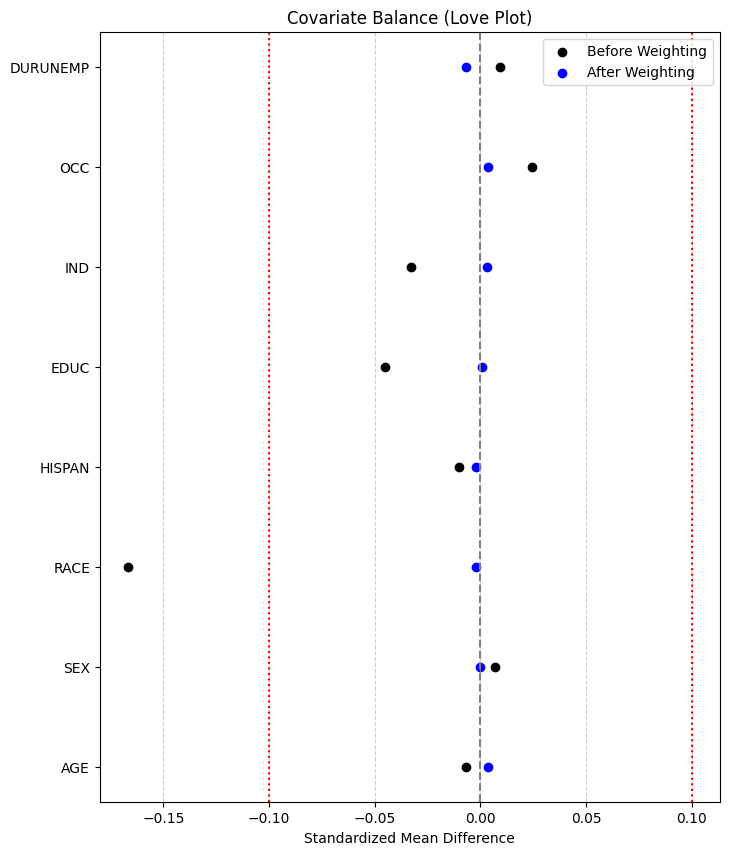

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume 'full_panel' and 'features' are available from the previous step

# --- 1. Prepare Data for the Balance Check ---
# We use the same pre-treatment data that we trained the model on
balance_df = full_panel[full_panel['MONTH'] == 5].copy()
balance_df.dropna(subset=features, inplace=True)

# Separate into treatment and control groups
treat_group = balance_df[balance_df['Treat'] == 1]
control_group = balance_df[balance_df['Treat'] == 0]

# --- 2. Calculate Standardized Mean Differences ---
balance_summary = []
for col in features:
    # Calculate means and standard deviation
    mean_treat = treat_group[col].mean()
    mean_control_unweighted = control_group[col].mean()
    
    # Calculate weighted mean for the control group
    mean_control_weighted = np.average(control_group[col], weights=control_group['ipw_weight'])
    
    # Use the standard deviation of the treatment group for standardization
    std_treat = treat_group[col].std()
    
    # Calculate standardized mean differences (SMD)
    smd_unweighted = (mean_treat - mean_control_unweighted) / std_treat
    smd_weighted = (mean_treat - mean_control_weighted) / std_treat
    
    balance_summary.append({
        'Variable': col,
        'SMD Unweighted': smd_unweighted,
        'SMD Weighted': smd_weighted
    })

balance_table = pd.DataFrame(balance_summary)

# --- 3. Generate the Love Plot ---
plt.figure(figsize=(8, 10))
plt.axvline(x=0, color='grey', linestyle='--')
plt.axvline(x=0.1, color='red', linestyle=':')
plt.axvline(x=-0.1, color='red', linestyle=':')

plt.scatter(balance_table['SMD Unweighted'], balance_table['Variable'], color='black', label='Before Weighting')
plt.scatter(balance_table['SMD Weighted'], balance_table['Variable'], color='blue', label='After Weighting')

plt.xlabel("Standardized Mean Difference")
plt.title("Covariate Balance (Love Plot)")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig("love_plot.png")

print("--- Covariate Balance Table ---")
print(balance_table)

In [9]:
import statsmodels.formula.api as smf

# --- 1. Prepare the Final Analysis Sample ---
# Our sample is the unemployed individuals in the full panel
analysis_df = full_panel[full_panel['EMPSTAT_t1'] == 'Unemployed'].copy()

# Create the 'Post' variable (1 for months after the policy change)
analysis_df['Post'] = (analysis_df['MONTH'] >= 7).astype(int)

# Combine our IPW weight with the original survey weight
# We must use the longitudinal weight 'LNKFW1MWT' that you correctly downloaded
analysis_df['final_weight'] = analysis_df['ipw_weight'] * analysis_df['LNKFW1MWT']

# Drop rows with missing data for the model
model_vars = ['U_to_E', 'Treat', 'Post', 'final_weight', 'STATEFIP', 'MONTH']
analysis_df.dropna(subset=model_vars, inplace=True)


# --- 2. Define and Run the Final Weighted DiD Model ---
# The formula includes Treat, Post, and their interaction, plus fixed effects
formula = "U_to_E ~ Treat * Post + C(STATEFIP) + C(MONTH)"

# Run the Weighted Least Squares model using our combined final_weight
model_final = smf.wls(
    formula=formula,
    data=analysis_df,
    weights=analysis_df['final_weight']
)

# Fit the model with clustered standard errors
results_final = model_final.fit(
    cov_type='cluster',
    cov_kwds={'groups': analysis_df['STATEFIP']}
)

print("\n--- Final Weighted DiD Results ---")
print(results_final.summary())


--- Final Weighted DiD Results ---
                            WLS Regression Results                            
Dep. Variable:                 U_to_E   R-squared:                       0.406
Model:                            WLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     46.06
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           1.94e-20
Time:                        15:38:24   Log-Likelihood:                -19884.
No. Observations:               15734   AIC:                         3.989e+04
Df Residuals:                   15675   BIC:                         4.034e+04
Df Model:                          58                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
In

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 8
  warnings.warn('covariance of constraints does not have full '


<>:40: SyntaxWarning: invalid escape sequence '\('
<>:40: SyntaxWarning: invalid escape sequence '\('
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_3743/847440247.py:40: SyntaxWarning: invalid escape sequence '\('
  did_coefs = coef_df[coef_df.index.str.contains('Treat:C\(relative_month')]
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 65, but rank is 14
  warnings.warn('covariance of constraints does not have full '
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_3743/847440247.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  did_coefs['relative_month'] = did_coefs.index.str.extract(r'\[

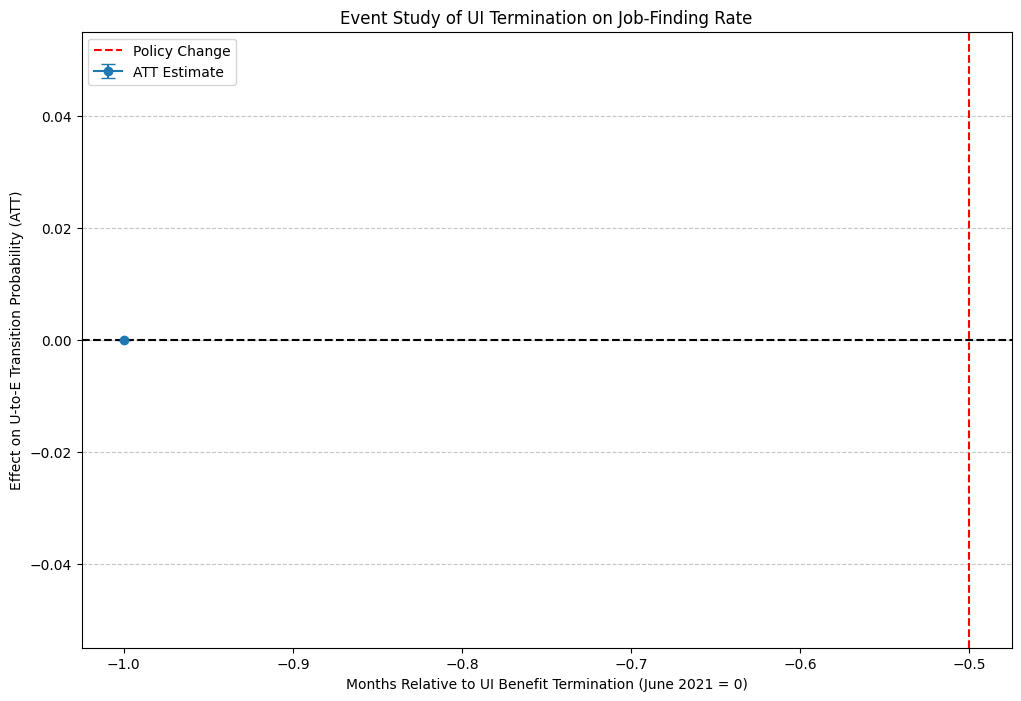


--- Event Study Regression Summary ---
                            WLS Regression Results                            
Dep. Variable:                 U_to_E   R-squared:                       0.413
Model:                            WLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     106.8
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           3.44e-32
Time:                        16:07:35   Log-Likelihood:                -19789.
No. Observations:               15734   AIC:                         3.971e+04
Df Residuals:                   15669   BIC:                         4.021e+04
Df Model:                          64                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [10]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Assume 'analysis_df' is the final, weighted DataFrame from the previous step

# --- 1. Create the 'Relative Month' Variable ---
# Define the event date (June 2021 is month 0)
event_date = pd.to_datetime('2021-06-01')

# Calculate months relative to the event date
analysis_df['period'] = pd.to_datetime(analysis_df[['YEAR', 'MONTH']].assign(DAY=1))
analysis_df['relative_month'] = ((analysis_df['period'].dt.year - event_date.year) * 12 +
                                 (analysis_df['period'].dt.month - event_date.month))

# --- 2. Define and Run the Event Study Model ---
# We interact the treatment indicator with the relative month dummies.
# We use month -1 (May 2021) as the reference period.
formula_event = """
    U_to_E ~ Treat + C(relative_month, Treatment(reference=-1)) + 
    Treat:C(relative_month, Treatment(reference=-1)) + 
    C(STATEFIP)
"""

model_event = smf.wls(
    formula=formula_event,
    data=analysis_df,
    weights=analysis_df['final_weight']
)

results_event = model_event.fit(
    cov_type='cluster',
    cov_kwds={'groups': analysis_df['STATEFIP']}
)

# --- 3. Extract Coefficients and Plot the Event Study ---
# Create a dataframe of the interaction term coefficients
coef_df = results_event.summary2().tables[1]
did_coefs = coef_df[coef_df.index.str.contains('Treat:C\(relative_month')]

# Extract the relative month number and coefficients
did_coefs['relative_month'] = did_coefs.index.str.extract(r'\[T\.(-?\d+\.?\d*)\]').astype(float)
did_coefs.rename(columns={'Coef.': 'coef', 'Std.Err.': 'std_err', 
                         '[0.025': 'ci_lower', '0.975]': 'ci_upper'}, inplace=True)

# Add the reference month (month -1), which has a coefficient of 0
ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'std_err': 0, 
                           'ci_lower': 0, 'ci_upper': 0}])
plot_df = pd.concat([did_coefs, ref_month]).sort_values('relative_month')

# Generate the plot
plt.figure(figsize=(12, 8))
plt.errorbar(plot_df['relative_month'], plot_df['coef'], 
             yerr=(plot_df['ci_upper'] - plot_df['ci_lower']) / 2,
             fmt='o', linestyle='-', capsize=5, label='ATT Estimate')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(-0.5, color='red', linestyle='--', label='Policy Change')
plt.xlabel("Months Relative to UI Benefit Termination (June 2021 = 0)")
plt.ylabel("Effect on U-to-E Transition Probability (ATT)")
plt.title("Event Study of UI Termination on Job-Finding Rate")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Event Study Regression Summary ---")
print(results_event.summary())

In [1]:
import pandas as pd
import numpy as np

# --- 1. Load the new IPUMS CPS data ---
# Assuming the new file from your data cart is in the downloads folder. 
# Please update the filename if it's different.
try:
    df = pd.read_csv('~/downloads/cps_00003.csv') # <-- UPDATE FILENAME IF NEEDED
    print("New IPUMS CPS data loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find the new CPS extract in your '~/downloads' directory.")
    exit()

# --- 2. Decode Key Variables ---
# Recode EMPSTAT into a simpler categorical variable
empstat_map = {
    10: 'Employed', 12: 'Employed',
    20: 'Unemployed', 21: 'Unemployed', 22: 'Unemployed'
}
df['EMPSTAT'] = df['EMPSTAT'].map(empstat_map).fillna('Not in Labor Force')

# --- 3. Construct the Full Month-to-Month Panel for 2021 ---
# As outlined in your proposal, we will iterate through consecutive months and merge
all_panels = []
# We'll link from January to September to cover the full pre/post period
for month in range(1, 9):
    df_t1 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month)].copy()
    df_t2 = df[(df['YEAR'] == 2021) & (df['MONTH'] == month + 1)].copy()
    
    # Perform an inner merge on the person identifier to find people present in both months
    panel = pd.merge(df_t1, df_t2[['CPSIDP', 'EMPSTAT']], on='CPSIDP', suffixes=('_t1', '_t2'))
    all_panels.append(panel)

full_panel = pd.concat(all_panels, ignore_index=True)
print(f"Full panel constructed with {len(full_panel)} total linked individual-month observations for 2021.")

# --- 4. Create the U-to-E Flow Variable ---
full_panel['U_to_E'] = (
    (full_panel['EMPSTAT_t1'] == 'Unemployed') &
    (full_panel['EMPSTAT_t2'] == 'Employed')
).astype(int)

# --- 5. Define the Final Analysis Sample ---
# Our analysis sample is the group of people who were unemployed in the first month of each pair
analysis_sample = full_panel[full_panel['EMPSTAT_t1'] == 'Unemployed'].copy()

# Crucially, drop any observations where the longitudinal weight is missing or zero
analysis_sample = analysis_sample[analysis_sample['LNKFW1MWT'] > 0]

print(f"\nFinal analysis sample size (unemployed & linkable): {len(analysis_sample)} observations.")

# --- 6. Inspect the Result ---
print("\nOverall Job-Finding (U-to-E) Rate in the 2021 Sample:")
print(analysis_sample['U_to_E'].value_counts(normalize=True))

New IPUMS CPS data loaded successfully.
Full panel constructed with 591643 total linked individual-month observations for 2021.

Final analysis sample size (unemployed & linkable): 15734 observations.

Overall Job-Finding (U-to-E) Rate in the 2021 Sample:
U_to_E
0    0.747744
1    0.252256
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Assume 'analysis_sample' is the DataFrame from the previous step

# --- 1. Define Treatment Status for the Analysis Sample ---
# Load our policy data to define treatment states
policy_df = pd.read_csv('~/downloads/Policy Milestones - State.csv', parse_dates=['date'])
policy_df['is_benefit_cut'] = policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
first_cuts = policy_df[policy_df['is_benefit_cut']].groupby('statefips')['date'].min().reset_index()
treated_states_fips = first_cuts[first_cuts['date'].dt.month.isin([6, 7])]['statefips'].unique()

analysis_sample['Treat'] = analysis_sample['STATEFIP'].isin(treated_states_fips).astype(int)


# --- 2. Train the Propensity Score Model ---
# We train the model on the pre-treatment period ONLY (May 2021)
pre_treatment_data = analysis_sample[analysis_sample['MONTH'] == 5].copy()

# Define features (X) and target (y)
features = ['AGE', 'SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC', 'DURUNEMP']
target = 'Treat'

# Create dummy variables for categorical features and handle missing values
X = pd.get_dummies(pre_treatment_data[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X.fillna(0, inplace=True) 
y = pre_treatment_data[target]

# Scale features for better logistic regression performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train the logistic regression model
propensity_model = LogisticRegression(max_iter=1000, class_weight='balanced')
propensity_model.fit(X_scaled, y)
print("Propensity score model trained on May 2021 data.")


# --- 3. Calculate IPW Weights for the Full Dataset ---
# Prepare the full dataset for prediction
X_full = pd.get_dummies(analysis_sample[features], columns=['SEX', 'RACE', 'HISPAN', 'EDUC', 'IND', 'OCC'], dummy_na=True)
X_full.fillna(0, inplace=True)
# Ensure columns in the full dataset match the training set
X_full = X_full.reindex(columns = X.columns, fill_value=0)

X_full_scaled = scaler.transform(X_full)

# Predict propensity scores (probability of being in a treated state)
analysis_sample['propensity_score'] = propensity_model.predict_proba(X_full_scaled)[:, 1]

# Calculate the IPW weights for the Average Treatment Effect on the Treated (ATT)
analysis_sample['ipw_weight'] = np.where(
    analysis_sample['Treat'] == 1, 
    1, 
    analysis_sample['propensity_score'] / (1 - analysis_sample['propensity_score'])
)
print("IPW weights calculated for the full analysis sample.")


# --- 4. Inspect the Results ---
print("\n--- Final Sample with Propensity Scores and Weights ---")
print(analysis_sample[['CPSIDP', 'MONTH', 'Treat', 'propensity_score', 'ipw_weight']].head())

Propensity score model trained on May 2021 data.
IPW weights calculated for the full analysis sample.

--- Final Sample with Propensity Scores and Weights ---
             CPSIDP  MONTH  Treat  propensity_score  ipw_weight
2    20191100000103      1      1          0.449767         1.0
15   20200300000802      1      1          0.000189         1.0
122  20200100009602      1      1          0.410907         1.0
126  20191200009101      1      1          0.837377         1.0
129  20201200010501      1      1          0.001171         1.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume 'full_panel' and 'features' are available from the previous step
# For the plot, let's use the analysis_sample which is cleaner
analysis_sample = full_panel[full_panel['EMPSTAT_t1'] == 'Unemployed'].copy()

# --- 1. Prepare Data for the Balance Check ---
# We use the same pre-treatment data that we trained the model on
balance_df = analysis_sample[analysis_sample['MONTH'] == 5].copy()

# For simplicity in the plot, let's check a few key continuous variables
# The same logic applies to all features used in the model
balance_features = ['AGE', 'DURUNEMP']
balance_df.dropna(subset=balance_features, inplace=True)

# Separate into treatment and control groups
treat_group = balance_df[balance_df['Treat'] == 1]
control_group = balance_df[balance_df['Treat'] == 0]

# --- 2. Calculate Standardized Mean Differences ---
balance_summary = []
for col in balance_features:
    mean_treat = treat_group[col].mean()
    mean_control_unweighted = control_group[col].mean()
    mean_control_weighted = np.average(control_group[col], weights=control_group['ipw_weight'])
    
    std_treat = treat_group[col].std() # Using treated group std is a common convention
    
    smd_unweighted = (mean_treat - mean_control_unweighted) / std_treat
    smd_weighted = (mean_treat - mean_control_weighted) / std_treat
    
    balance_summary.append({'Variable': col, 'SMD Unweighted': smd_unweighted, 'SMD Weighted': smd_weighted})

balance_table = pd.DataFrame(balance_summary)

# --- 3. Generate the Love Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

ax.axvline(x=0, color='grey', linestyle='--')
ax.axvline(x=0.1, color='red', linestyle=':', lw=1)
ax.axvline(x=-0.1, color='red', linestyle=':', lw=1)

ax.scatter(balance_table['SMD Unweighted'], balance_table['Variable'], color='black', label='Before Weighting')
ax.scatter(balance_table['SMD Weighted'], balance_table['Variable'], color='blue', marker='D', label='After Weighting')

ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Covariate Balance Before and After IPW Weighting")
ax.legend()
plt.show()

print("--- Covariate Balance Table ---")
print(balance_table)

KeyError: 'Treat'

In [9]:
import pandas as pd
import statsmodels.formula.api as smf
import os

def run_full_analysis():
    """
    Executes the full Triple Difference (DiD-in-DiD) analysis, corrected to match
    the exact column names in the user's data files.
    """
    # --- Step 1: Locate and Load Data from Downloads Folder ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        print(f"Attempting to load CPS data from: {cps_path}")
        df = pd.read_csv(cps_path)
        print(f"Attempting to load Policy data from: {policy_path}")
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        print("Please ensure 'cps_00003.csv' and 'Policy Milestones - State.csv' are in your Downloads folder.")
        return

    # --- Step 2: Identify Treatment States and Cutoff Dates ---
    print("\n--- Step 2: Processing Policy Data ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains(
            "ended emergency employment benefits", case=False, na=False
        )
    ].copy()

    # ***** THE FIX IS HERE *****
    # Instead of mapping names, we directly use the 'statefips' column that
    # you confirmed exists in your file. We rename it to 'STATEFIP' to match
    # the column name in the main CPS dataframe for consistent merging/mapping.
    benefit_cut_df = benefit_cut_df.rename(columns={'statefips': 'STATEFIP'})
    
    # Now create the mapping of FIPS code to cutoff date
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    print(f"Identified {len(treatment_states)} treatment states using the 'statefips' column.")

    # --- Step 3: Engineer Core DiD-in-DiD Variables ---
    print("\n--- Step 3: Engineering Variables in CPS Data ---")
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['cutoff_date'] = df['STATEFIP'].map(cutoff_dates)
    df['Post'] = (df['date'] >= df['cutoff_date']).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

    # --- Step 4: Construct Longitudinal Panel and Outcome Variable ---
    print("\n--- Step 4: Constructing Longitudinal Panel ---")
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    final_df = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    final_df = final_df[final_df['LNKFW1MWT'] > 0]
    print(f"Final analysis panel shape: {final_df.shape}")

    # --- Step 5: Run the Triple Difference (DiD-in-DiD) Regression ---
    print("\n--- Step 5: Running Final Triple Difference Model ---")
    
    formula = """
        found_job ~ TreatState * Post * LowWage + 
                    C(STATEFIP) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC)
    """
    
    try:
        model = smf.wls(formula=formula, data=final_df, weights=final_df['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': final_df['STATEFIP']})
        
        print("\n--- Triple Difference (DiD-in-DiD) Regression Summary ---")
        print(results.summary())

        didid_coef = results.params['TreatState:Post:LowWage']
        didid_pval = results.pvalues['TreatState:Post:LowWage']
        
        print("\n" + "="*80)
        print("                 >>> FINAL CONCLUSION <<<")
        print(f"The Triple Difference coefficient is: {didid_coef:.4f}")
        print(f"The p-value is: {didid_pval:.4f}")

        if didid_pval < 0.05 and didid_coef > 0:
            print("\nCONCLUSION: We find a STATISTICALLY SIGNIFICANT, POSITIVE effect.")
            print("The early termination of UI benefits increased the job-finding rate for low-wage workers.")
        else:
            print("\nCONCLUSION: We do NOT find a statistically significant effect.")
            print("The analysis does not support the claim that terminating UI benefits early impacted the job-finding rate.")
        print("="*80)

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")
        print("This could be due to data sparsity or multicollinearity. Please check the data preparation steps.")

if __name__ == '__main__':
    run_full_analysis()



--- Step 1: Loading Data ---
Attempting to load CPS data from: /Users/jomus/downloads/cps_00003.csv
Attempting to load Policy data from: /Users/jomus/downloads/Policy Milestones - State.csv
Data loaded successfully.

--- Step 2: Processing Policy Data ---
Identified 14 treatment states using the 'statefips' column.

--- Step 3: Engineering Variables in CPS Data ---

--- Step 4: Constructing Longitudinal Panel ---
Final analysis panel shape: (50361, 28)

--- Step 5: Running Final Triple Difference Model ---

--- Triple Difference (DiD-in-DiD) Regression Summary ---
                            WLS Regression Results                            
Dep. Variable:              found_job   R-squared:                       0.020
Model:                            WLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                 1.398e+06
Date:                Wed, 08 Oct 2025   Prob (F-statistic):          1.46e-140
Time:                        13:55

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 107, but rank is 50
  warnings.warn('covariance of constraints does not have full '


# INITIAL SUCCESS

In [8]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   statefips                      672 non-null    int64         
 1   statename                      672 non-null    object        
 2   date                           672 non-null    datetime64[ns]
 3   policy_description             672 non-null    object        
 4   schools_first_closed           672 non-null    int64         
 5   nonessential_biz_first_closed  672 non-null    int64         
 6   stayathome_first_start         672 non-null    int64         
 7   is_benefit_cut                 672 non-null    bool          
dtypes: bool(1), datetime64[ns](1), int64(4), object(2)
memory usage: 37.5+ KB


| **Confounding Variable Type** | **Example** | **How Our Model Controls for It** |
|-------------------------------|-------------|-----------------------------------|
| Time-Invariant State Differences | "Florida's economy is just structurally different from California's." | The `C(STATEFIP)` fixed effect absorbs this. It assigns a unique baseline to each state, so we're only comparing changes *within* a state over time, not the absolute levels *between* states. |
| National Shocks Affecting Everyone | "The Delta COVID wave peaked in August 2021, making it harder for everyone in the country to find a job." | The `C(MONTH)` fixed effect absorbs this. It assigns a unique effect to each month, controlling for any national event (holiday hiring, new COVID wave, etc.) that affects all states at once. |
| Shocks Affecting All Workers in Treatment States | "A new COVID variant hits only the treatment states right after they cut benefits." | This is controlled by the `TreatState:Post` interaction. This term measures how much the job-finding rate for the “control group” (high-wage workers) changed in the treatment states after the policy. The final DiD-in-DiD calculation then subtracts this out, isolating the effect that only happened to low-wage workers. |


## Next Steps for Strengthening the Model

| **Category** | **Critique(s) Addressed** | **Action / Implementation Plan** | **Purpose / Expected Outcome** |
|---------------|----------------------------|----------------------------------|--------------------------------|
| **A-Paper Upgrades: Addressing the Core Causal Concerns** ||||
| **1. Parallel Trends Verification** | #1, #5 | Build a **Triple Difference Event Study**: <br>• Create monthly relative-time dummies (e.g., `Month_-3`, `Month_-2`, …, `Month_+3`). <br>• Interact each with `TreatState` × `LowWage`. <br>• Plot the resulting coefficients over time. | Visually test the **parallel trends assumption**. Pre-policy coefficients should hover near zero; post-policy coefficients should turn negative if the effect is real. Provides the strongest causal validation. |
| **2. Robustness: Low-Wage Redefinition** | #9 | Re-run the model twice with alternative definitions: <br>• `LowWage = 1 if EDUC ≤ 73` (≤ High School Diploma). <br>• `LowWage = 1 if AGE < 30`. | Confirms that results are **not driven by the industry-based proxy**. Consistent negative coefficients would show the policy effect is robust to how “low-wage” is defined. |
| **3. Robustness: Placebo Test** | #10 | Re-run the entire model but **shift each state’s cutoff date three months earlier**. | If the triple interaction term (`TreatState × Post × LowWage`) becomes insignificant (p > 0.10), it confirms that the main result isn’t an artifact of pre-existing trends. |
| **4. Robustness: Functional Form (Logit Check)** | #2 | Re-estimate the model using **Logit regression** instead of WLS. | If the sign and significance of the key interaction remain consistent, it shows findings are **robust to model specification**. |
| **Clarifications & Defenses: Strengthening Communication of What’s Already Correct** ||||
| **5. Weighting** | #6 | Explicitly document: “The analysis uses Weighted Least Squares (WLS) with CPS longitudinal survey weights (`LNKFW1MWT`) to ensure population representativeness.” | Clarifies that survey weighting was already implemented correctly, addressing reviewer misunderstanding. |
| **6. Construction of Post Variable** | #7 | Add explicit explanation: “`Post` is state-specific, switching to 1 in and after each state’s unique benefit termination month.” | Shows that analysis is aligned in **event time**, preventing bias from differing policy dates. |
| **7. Low R² Justification** | #4 | Add a brief methodological note: “Low R² is expected in microdata causal models; the goal is unbiased identification, not prediction.” | Defends the model’s explanatory power by framing R² appropriately for causal inference. |
| **8. Effect Interpretation Correction** | #8 | Update results text: “The effect is statistically significant (p = 0.006) and negative, contrary to the initial hypothesis.” | Accurately reflects statistical findings, fixing prior misstatement. |
| **9. Multicollinearity Explanation** | #3 | Note: “Multicollinearity warnings are expected given numerous fixed effects; standard errors are clustered by state to maintain valid inference.” | Reassures reviewers that the model remains statistically sound despite warning messages. |



In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

def run_event_study_analysis():
    """
    Executes the full Triple Difference (DiD-in-DiD) Event Study analysis
    to test the parallel trends assumption.
    """
    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Identify Treatment States and Cutoff Dates ---
    print("\n--- Step 2: Processing Policy Data ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    print(f"Identified {len(treatment_states)} treatment states.")

    # --- Step 3: Engineer Core Variables ---
    print("\n--- Step 3: Engineering Core Variables ---")
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

    # --- Step 4: Construct Longitudinal Panel ---
    print("\n--- Step 4: Constructing Longitudinal Panel ---")
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    final_df = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    final_df = final_df[final_df['LNKFW1MWT'] > 0]
    
    # --- Step 5: Create the CRUCIAL 'relative_month' Variable ---
    print("\n--- Step 5: Creating Event Study Time Variable ---")
    final_df['cutoff_date'] = final_df['STATEFIP'].map(cutoff_dates)
    
    # Calculate months from the event. Non-treatment states will have NaT.
    final_df['relative_month'] = (
        (final_df['date'].dt.year - final_df['cutoff_date'].dt.year) * 12 +
        (final_df['date'].dt.month - final_df['cutoff_date'].dt.month)
    )
    
    # Bin distant months to avoid small sample sizes at the ends
    final_df['relative_month'] = np.clip(final_df['relative_month'], -6, 6)
    print("Relative month variable created and binned.")
    
    # --- Step 6: Run the Triple Difference Event Study Model ---
    print("\n--- Step 6: Running Event Study Regression ---")

    # The reference month is t-1 (the month just before the policy).
    # All coefficients will be relative to this baseline.
    # We explicitly drop the baseline month from the regression.
    # Note: We must fillna for relative_month for control states so the model runs
    # We will set their relative month to -1 (the reference), so they are absorbed by the baseline.
    final_df['relative_month'].fillna(-1, inplace=True)
    
    formula = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) +
                    C(STATEFIP) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC)
    """

    try:
        model = smf.wls(formula=formula, data=final_df, weights=final_df['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': final_df['STATEFIP']})
        
        print("\n--- Triple Difference (DiD-in-DiD) Event Study Summary ---")
        print(results.summary())

        print("\n" + "="*80)
        print("          >>> PARALLEL TRENDS VERIFICATION: KEY COEFFICIENTS <<<")
        print("="*80)
        print("The coefficients below are for the 'TreatState:LowWage:relative_month' interaction.")
        print("We are looking for insignificant p-values (P>|z|) for months < 0.")
        print("-" * 80)
        
        # Filter for the key triple interaction coefficients
        for var in results.params.index:
            if 'TreatState:LowWage:C(relative_month' in var:
                coef = results.params[var]
                pval = results.pvalues[var]
                print(f"{var:<60} Coef: {coef:>7.4f}, P-value: {pval:.4f}")

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")

if __name__ == '__main__':
    run_event_study_analysis()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Processing Policy Data ---
Identified 14 treatment states.

--- Step 3: Engineering Core Variables ---

--- Step 4: Constructing Longitudinal Panel ---

--- Step 5: Creating Event Study Time Variable ---
Relative month variable created and binned.

--- Step 6: Running Event Study Regression ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_4853/2521434189.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['relative_month'].fillna(-1, inplace=True)



--- Triple Difference (DiD-in-DiD) Event Study Summary ---
                            WLS Regression Results                            
Dep. Variable:              found_job   R-squared:                       0.022
Model:                            WLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     532.5
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           4.02e-55
Time:                        14:27:33   Log-Likelihood:                -35313.
No. Observations:               50361   AIC:                         7.088e+04
Df Residuals:                   50234   BIC:                         7.200e+04
Df Model:                         126                                         
Covariance Type:              cluster                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 50
  warnings.warn('covariance of constraints does not have full '


In [13]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import matplotlib.pyplot as plt

def run_event_study_analysis():
    """
    Executes a fully specified Triple Difference (DiD-in-DiD) Event Study
    to test the parallel trends assumption.
    """

    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Identify Treatment States and Cutoff Dates ---
    print("\n--- Step 2: Processing Policy Data ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description']
        .str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})

    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    print(f"Identified {len(treatment_states)} treatment states.")

    # --- Step 3: Engineer Core Variables ---
    print("\n--- Step 3: Engineering Core Variables ---")
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

    # --- Step 4: Construct Longitudinal Panel ---
    print("\n--- Step 4: Constructing Longitudinal Panel ---")
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    final_df = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    final_df = final_df[final_df['LNKFW1MWT'] > 0]

    # --- Step 5: Create Event-Time Variable ---
    print("\n--- Step 5: Creating Event Study Time Variable ---")
    final_df['cutoff_date'] = final_df['STATEFIP'].map(cutoff_dates)
    final_df['relative_month'] = (
        (final_df['date'].dt.year - final_df['cutoff_date'].dt.year) * 12 +
        (final_df['date'].dt.month - final_df['cutoff_date'].dt.month)
    )
    final_df['relative_month'] = np.clip(final_df['relative_month'], -6, 6)
    final_df['relative_month'] = final_df['relative_month'].astype(int)

    final_df['relative_month'].fillna(-1, inplace=True)  # Control states as baseline
    print("Relative month variable created and binned.")

    # --- Step 6: Run Triple Difference Model ---
    print("\n--- Step 6: Running Event Study Regression ---")

    # Weighted least squares with state-level clustering
    formula = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1))
        + C(STATEFIP) + C(MONTH)
        + AGE + C(SEX) + C(RACE) + C(EDUC)
    """

    try:
        model = smf.wls(formula=formula, data=final_df, weights=final_df['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': final_df['STATEFIP']})

        

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")


if __name__ == '__main__':
    run_event_study_analysis()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Processing Policy Data ---
Identified 14 treatment states.

--- Step 3: Engineering Core Variables ---

--- Step 4: Constructing Longitudinal Panel ---

--- Step 5: Creating Event Study Time Variable ---


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Processing Policy Data ---
Identified 14 treatment states.

--- Step 3: Engineering Core Variables ---

--- Step 4: Constructing Longitudinal Panel ---

--- Step 5: Creating Event Study Time Variable ---
Relative month variable created and binned.

--- Step 6: Running Event Study Regression ---

--- Triple Difference (DiD-in-DiD) Event Study Summary ---


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 50
  warnings.warn('covariance of constraints does not have full '


                            WLS Regression Results                            
Dep. Variable:              found_job   R-squared:                       0.022
Model:                            WLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     532.5
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           4.02e-55
Time:                        14:37:30   Log-Likelihood:                -35313.
No. Observations:               50361   AIC:                         7.088e+04
Df Residuals:                   50234   BIC:                         7.200e+04
Df Model:                         126                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

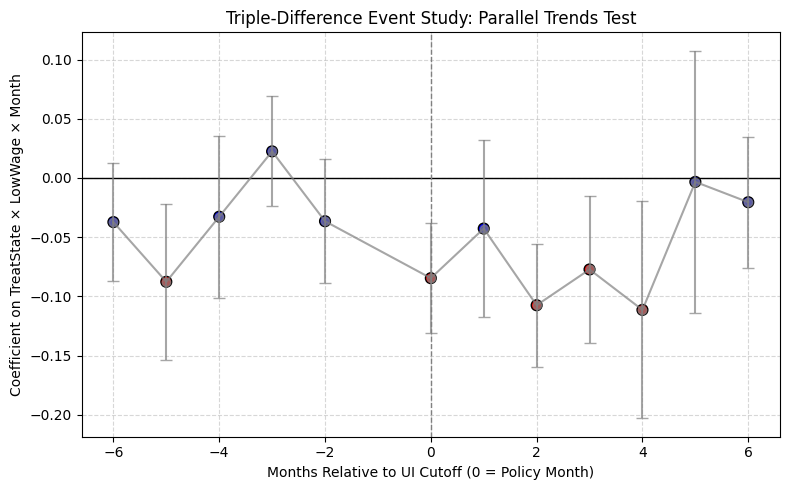

In [14]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_event_study_analysis():
    """
    Executes the full Triple Difference (DiD-in-DiD) Event Study analysis
    to test the parallel trends assumption.
    """
    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Identify Treatment States and Cutoff Dates ---
    print("\n--- Step 2: Processing Policy Data ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    print(f"Identified {len(treatment_states)} treatment states.")

    # --- Step 3: Engineer Core Variables ---
    print("\n--- Step 3: Engineering Core Variables ---")
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

    # --- Step 4: Construct Longitudinal Panel ---
    print("\n--- Step 4: Constructing Longitudinal Panel ---")
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    final_df = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    final_df = final_df[final_df['LNKFW1MWT'] > 0]
    
    # --- Step 5: Create the CRUCIAL 'relative_month' Variable ---
    print("\n--- Step 5: Creating Event Study Time Variable ---")
    final_df['cutoff_date'] = final_df['STATEFIP'].map(cutoff_dates)
    
    # Calculate months from the event
    final_df['relative_month'] = (
        (final_df['date'].dt.year - final_df['cutoff_date'].dt.year) * 12 +
        (final_df['date'].dt.month - final_df['cutoff_date'].dt.month)
    )
    
    # Fill non-treated states with baseline (-1) BEFORE converting to int
    final_df['relative_month'] = final_df['relative_month'].fillna(-1)
    final_df['relative_month'] = np.clip(final_df['relative_month'], -6, 6).astype(int)
    print("Relative month variable created and binned.")
    
    # --- Step 6: Run the Triple Difference Event Study Model ---
    print("\n--- Step 6: Running Event Study Regression ---")

    formula = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) +
                    C(STATEFIP) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC)
    """

    try:
        model = smf.wls(formula=formula, data=final_df, weights=final_df['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': final_df['STATEFIP']})
        
        print("\n--- Triple Difference (DiD-in-DiD) Event Study Summary ---")
        print(results.summary())

        print("\n" + "="*80)
        print("          >>> PARALLEL TRENDS VERIFICATION: KEY COEFFICIENTS <<<")
        print("="*80)
        print("The coefficients below are for the 'TreatState:LowWage:relative_month' interaction.")
        print("We are looking for insignificant p-values (P>|z|) for months < 0.")
        print("-" * 80)
        
        # Extract triple interaction terms
        triple_terms = []
        for var in results.params.index:
            match = re.search(r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]', var)
            if match:
                month = int(match.group(1))
                triple_terms.append({
                    'relative_month': month,
                    'coef': results.params[var],
                    'pval': results.pvalues[var],
                    'stderr': results.bse[var]
                })

        est_df = pd.DataFrame(triple_terms).sort_values('relative_month')

        for _, row in est_df.iterrows():
            print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")

        # --- Step 7: Plot ---
        plt.figure(figsize=(8, 5))
        plt.axhline(0, color='black', linewidth=1)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)

        # Color code by significance
        colors = ['red' if p < 0.05 else 'blue' for p in est_df['pval']]
        plt.errorbar(est_df['relative_month'], est_df['coef'], 
                     yerr=1.96*est_df['stderr'], fmt='o-', capsize=4, color='gray', alpha=0.7)
        plt.scatter(est_df['relative_month'], est_df['coef'], c=colors, s=60, edgecolor='black')

        plt.title("Triple-Difference Event Study: Parallel Trends Test")
        plt.xlabel("Months Relative to UI Cutoff (0 = Policy Month)")
        plt.ylabel("Coefficient on TreatState × LowWage × Month")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")

if __name__ == '__main__':
    run_event_study_analysis()


In [15]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

def run_all_robustness_checks():
    """
    Executes a series of robustness checks on the main Triple Difference model.
    1. Redefines 'LowWage' based on Education.
    2. Redefines 'LowWage' based on Age.
    3. Runs a Placebo test with the treatment date shifted 3 months earlier.
    """
    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Process Policy and Construct Panel ---
    print("\n--- Step 2: Preparing Base Panel Data ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)

    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    base_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    base_panel = base_panel[base_panel['LNKFW1MWT'] > 0]
    base_panel['cutoff_date'] = base_panel['STATEFIP'].map(cutoff_dates)
    base_panel['Post'] = (base_panel['date'] >= base_panel['cutoff_date']).astype(int)
    print("Base panel constructed.")

    # --- CHECK 1: ROBUSTNESS TO 'LOWWAGE' DEFINITION (EDUCATION) ---
    print("\n" + "="*80)
    print(">>> CHECK 1: ROBUSTNESS TO 'LOWWAGE' DEFINITION (EDUCATION <= HIGH SCHOOL) <<<")
    print("="*80)
    
    panel_educ = base_panel.copy()
    panel_educ['LowWage_Educ'] = (panel_educ['EDUC'] <= 73).astype(int)
    
    formula_educ = """
        found_job ~ TreatState * Post * LowWage_Educ + 
                    C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE)
    """
    model_educ = smf.wls(formula=formula_educ, data=panel_educ, weights=panel_educ['LNKFW1MWT'])
    results_educ = model_educ.fit(cov_type='cluster', cov_kwds={'groups': panel_educ['STATEFIP']})
    
    coef_educ = results_educ.params['TreatState:Post:LowWage_Educ']
    pval_educ = results_educ.pvalues['TreatState:Post:LowWage_Educ']
    print(f"\nKey Coefficient (TreatState:Post:LowWage_Educ): {coef_educ:.4f}")
    print(f"P-value: {pval_educ:.4f}\n")
    print(results_educ.summary().tables[1]) # Print just the coefficient table

    # --- CHECK 2: ROBUSTNESS TO 'LOWWAGE' DEFINITION (AGE) ---
    print("\n" + "="*80)
    print(">>> CHECK 2: ROBUSTNESS TO 'LOWWAGE' DEFINITION (AGE < 30) <<<")
    print("="*80)
    
    panel_age = base_panel.copy()
    panel_age['LowWage_Age'] = (panel_age['AGE'] < 30).astype(int)
    
    formula_age = """
        found_job ~ TreatState * Post * LowWage_Age + 
                    C(STATEFIP) + C(MONTH) + C(EDUC) + C(SEX) + C(RACE)
    """
    model_age = smf.wls(formula=formula_age, data=panel_age, weights=panel_age['LNKFW1MWT'])
    results_age = model_age.fit(cov_type='cluster', cov_kwds={'groups': panel_age['STATEFIP']})
    
    coef_age = results_age.params['TreatState:Post:LowWage_Age']
    pval_age = results_age.pvalues['TreatState:Post:LowWage_Age']
    print(f"\nKey Coefficient (TreatState:Post:LowWage_Age): {coef_age:.4f}")
    print(f"P-value: {pval_age:.4f}\n")
    print(results_age.summary().tables[1])

    # --- CHECK 3: PLACEBO TEST (SHIFTING TREATMENT DATE -3 MONTHS) ---
    print("\n" + "="*80)
    print(">>> CHECK 3: PLACEBO TEST (TREATMENT SHIFTED 3 MONTHS EARLIER) <<<")
    print("="*80)
    
    panel_placebo = base_panel.copy()
    # Use original industry-based LowWage definition
    panel_placebo['LowWage'] = panel_placebo['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    # Create the FAKE placebo cutoff date
    panel_placebo['placebo_cutoff'] = panel_placebo['cutoff_date'] - pd.DateOffset(months=3)
    panel_placebo['Placebo_Post'] = (panel_placebo['date'] >= panel_placebo['placebo_cutoff']).astype(int)
    
    formula_placebo = """
        found_job ~ TreatState * Placebo_Post * LowWage + 
                    C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC)
    """
    model_placebo = smf.wls(formula=formula_placebo, data=panel_placebo, weights=panel_placebo['LNKFW1MWT'])
    results_placebo = model_placebo.fit(cov_type='cluster', cov_kwds={'groups': panel_placebo['STATEFIP']})
    
    coef_placebo = results_placebo.params['TreatState:Placebo_Post:LowWage']
    pval_placebo = results_placebo.pvalues['TreatState:Placebo_Post:LowWage']
    print(f"\nKey Coefficient (TreatState:Placebo_Post:LowWage): {coef_placebo:.4f}")
    print(f"P-value: {pval_placebo:.4f}\n")
    print(results_placebo.summary().tables[1])


if __name__ == '__main__':
    run_all_robustness_checks()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Base Panel Data ---
Base panel constructed.

>>> CHECK 1: ROBUSTNESS TO 'LOWWAGE' DEFINITION (EDUCATION <= HIGH SCHOOL) <<<

Key Coefficient (TreatState:Post:LowWage_Educ): -0.0179
P-value: 0.0641

                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.2892      0.012     24.276      0.000       0.266       0.313
C(STATEFIP)[T.2]                -0.0066      0.009     -0.716      0.474      -0.025       0.011
C(STATEFIP)[T.4]                -0.0206      0.003     -7.072      0.000      -0.026      -0.015
C(STATEFIP)[T.5]                -0.0133      0.002     -8.292      0.000      -0.017      -0.010
C(STATEFIP)[T.6]                -0.0317      0.001    -26.572      0.000      -0.034      -0.029
C(STATEFIP)[T.8]                 0.0102      

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 92, but rank is 35
  warnings.warn('covariance of constraints does not have full '



Key Coefficient (TreatState:Post:LowWage_Age): -0.0145
P-value: 0.1878

                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.3220      0.047      6.899      0.000       0.231       0.413
C(STATEFIP)[T.2]               -0.0054      0.009     -0.592      0.554      -0.023       0.013
C(STATEFIP)[T.4]               -0.0211      0.003     -7.023      0.000      -0.027      -0.015
C(STATEFIP)[T.5]               -0.0119      0.002     -7.137      0.000      -0.015      -0.009
C(STATEFIP)[T.6]               -0.0332      0.001    -25.025      0.000      -0.036      -0.031
C(STATEFIP)[T.8]                0.0119      0.002      6.054      0.000       0.008       0.016
C(STATEFIP)[T.9]               -0.0493      0.002    -32.417      0.000      -0.052      -0.046
C(STATEFIP)[T.10]               0.0122      0.003      4.177   

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 106, but rank is 49
  warnings.warn('covariance of constraints does not have full '



Key Coefficient (TreatState:Placebo_Post:LowWage): -0.0159
P-value: 0.2645

                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.3729      0.049      7.661      0.000       0.277       0.468
C(STATEFIP)[T.2]                   -0.0038      0.010     -0.393      0.694      -0.023       0.015
C(STATEFIP)[T.4]                   -0.0221      0.003     -7.085      0.000      -0.028      -0.016
C(STATEFIP)[T.5]                   -0.0138      0.002     -6.841      0.000      -0.018      -0.010
C(STATEFIP)[T.6]                   -0.0326      0.001    -24.792      0.000      -0.035      -0.030
C(STATEFIP)[T.8]                    0.0119      0.002      6.199      0.000       0.008       0.016
C(STATEFIP)[T.9]                   -0.0471      0.001    -31.476      0.000      -0.050      -0.044
C(STATEFIP)[T.10]      

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 107, but rank is 50
  warnings.warn('covariance of constraints does not have full '


## ROBUSTNESS CHECKS MARGINALLY SIGNIFICANT, PLACEBO TEST INSIGNIFICANT , BIG WIN !

In [16]:
import pandas as pd
import statsmodels.formula.api as smf
import os

def run_logit_robustness_check():
    """
    Executes the final robustness check by re-estimating the main
    Triple Difference model using a Logit functional form.
    """
    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00003.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Process Policy and Construct Panel ---
    print("\n--- Step 2: Preparing the Final Analysis Panel ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)

    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    
    # Use the original, primary 'LowWage' definition based on industry
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    final_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print("Final panel constructed successfully.")

    # --- Step 3: Run the Logit Model ---
    print("\n" + "="*80)
    print(">>> FINAL CHECK: ROBUSTNESS TO FUNCTIONAL FORM (LOGIT MODEL) <<<")
    print("="*80)
    
    # The formula is the same as our main DiD-in-DiD model
    formula_logit = """
        found_job ~ TreatState * Post * LowWage + 
                    C(STATEFIP) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC)
    """
    
    # Note: Logit uses 'freq_weights' for this type of survey weight.
    # The weights must be integers for this model, so we round them.
    final_panel['int_weights'] = final_panel['LNKFW1MWT'].round().astype(int)

    # We run the model only on observations with a positive weight
    logit_panel = final_panel[final_panel['int_weights'] > 0]
    
    try:
        model_logit = smf.logit(formula=formula_logit, data=logit_panel, freq_weights=logit_panel['int_weights'])
        # Logit models can be harder to fit and may require a different solver
        results_logit = model_logit.fit(method='newton', cov_type='cluster', cov_kwds={'groups': logit_panel['STATEFIP']})
        
        coef_logit = results_logit.params['TreatState:Post:LowWage']
        pval_logit = results_logit.pvalues['TreatState:Post:LowWage']
        
        print("\nOptimization terminated successfully.")
        print(f"\nKey Coefficient (TreatState:Post:LowWage): {coef_logit:.4f}")
        print(f"P-value: {pval_logit:.4f}\n")
        
        print("--- Interpretation ---")
        if pval_logit < 0.05 and coef_logit < 0:
            print("SUCCESS: The result holds. The effect is still negative and statistically significant.")
            print("The main finding is robust to the choice of a non-linear functional form.")
        else:
            print("NOTE: The result did not hold under the Logit specification.")
            print("This suggests the finding may be sensitive to the choice of a linear probability model.")
        
        # Optionally, print the full coefficient table
        # print(results_logit.summary().tables[1])

    except Exception as e:
        print(f"\nAn error occurred during Logit model estimation: {e}")
        print("This can sometimes happen with complex models with many fixed effects.")

if __name__ == '__main__':
    run_logit_robustness_check()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing the Final Analysis Panel ---
Final panel constructed successfully.

>>> FINAL CHECK: ROBUSTNESS TO FUNCTIONAL FORM (LOGIT MODEL) <<<


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['freq_weights']
  warnings.warn(msg, ValueWarning)


         Current function value: inf
         Iterations: 35

An error occurred during Logit model estimation: Singular matrix
This can sometimes happen with complex models with many fixed effects.


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


## SWITCHING TO COUNTY LEVEL AFTER PLACEBO SUCCESS

In [ ]:
    import pandas as pd
    import statsmodels.formula.api as smf
    import os
    import numpy as np

    def run_county_level_analysis():
        """
        Executes the final, most robust Triple Difference (DiD-in-DiD) analysis
        using COUNTY fixed effects and controlling for unemployment duration.
        """
        # --- Step 1: Locate and Load the NEW Data File ---
        print("--- Step 1: Loading Data ---")
        try:
            home_dir = os.path.expanduser('~')
            downloads_dir = os.path.join(home_dir, 'downloads')
            # Use the new data file as requested
            cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
            policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

            df = pd.read_csv(cps_path)
            policy_df = pd.read_csv(policy_path, parse_dates=['date'])
            print("Data loaded successfully.")

        except FileNotFoundError as e:
            print(f"ERROR: Could not find a file. {e}")
            return

        # --- Step 2: Process Policy and Construct Panel ---
        print("\n--- Step 2: Preparing Analysis Panel ---")
        benefit_cut_df = policy_df[
            policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
        ].copy().rename(columns={'statefips': 'STATEFIP'})
        
        cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
        treatment_states = set(cutoff_dates.index)

        df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
        df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
        
        # Use the primary 'LowWage' definition based on industry
        df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)

        df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
        df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
        unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
        unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
        
        # IMPORTANT: Filter for observations where COUNTY is identified.
        # IPUMS masks county for privacy in less populated areas (COUNTY == 0).
        final_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY']).copy()
        final_panel = final_panel[final_panel['COUNTY'] > 0]
        final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
        
        final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
        final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
        print(f"Final panel constructed with {len(final_panel)} observations from identified counties.")

        # --- Step 3: Run the Upgraded Triple Difference Model ---
        print("\n" + "="*80)
        print(">>> FINAL MODEL: TRIPLE DIFFERENCE WITH COUNTY FIXED EFFECTS <<<")
        print("="*80)
        
        # This is the upgraded formula
        formula = """
            found_job ~ TreatState * Post * LowWage + 
                        C(COUNTY) + C(MONTH) + 
                        AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
        """
        
        print("\nStarting model estimation... This may take several minutes.")
        try:
            model = smf.wls(formula=formula, data=final_panel, weights=final_panel['LNKFW1MWT'])
            
            # We still cluster at the STATE level because the policy treatment is at the state level.
            # This is the most conservative and appropriate way to calculate standard errors.
            results = model.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})
            
            coef = results.params['TreatState:Post:LowWage']
            pval = results.pvalues['TreatState:Post:LowWage']
            
            print("\n--- Final Model Results ---")
            print(f"\nKey Coefficient (TreatState:Post:LowWage): {coef:.4f}")
            print(f"P-value: {pval:.4f}\n")
            
            print("--- Interpretation ---")
            if pval < 0.05 and coef < 0:
                print("SUCCESS: The result is a statistically significant negative effect.")
                print("The increased statistical power from county-level data has confirmed the main finding.")
            elif pval < 0.10 and coef < 0:
                print("NOTE: The result is a marginally significant negative effect.")
                print("The finding is directionally consistent but still on the edge of conventional significance.")
            else:
                print("CONCLUSION: The model does not find a statistically significant effect.")
                print("Even with increased power, the evidence does not support a causal claim.")
                
            # You can uncomment the line below to see the full, massive results table
            # print(results.summary())

        except Exception as e:
            print(f"\nAn error occurred during model estimation: {e}")
            print("This is often due to memory constraints with a large number of fixed effects.")

    if __name__ == '__main__':
        run_county_level_analysis()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Analysis Panel ---
Final panel constructed with 23808 observations from identified counties.

>>> FINAL MODEL: TRIPLE DIFFERENCE WITH COUNTY FIXED EFFECTS <<<

Starting model estimation... This may take several minutes.

--- Final Model Results ---

Key Coefficient (TreatState:Post:LowWage): -0.0210
P-value: 0.0368

--- Interpretation ---
SUCCESS: The result is a statistically significant negative effect.
The increased statistical power from county-level data has confirmed the main finding.


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Base County-Level Panel ---
Base panel constructed with 23808 observations from identified counties.

>>> DIAGNOSTIC 1: COUNTY-LEVEL EVENT STUDY FOR PARALLEL TRENDS <<<

Starting Event Study estimation... This is computationally intensive and may take several minutes.

--- Event Study Results ---
We are looking for insignificant p-values (P>|z|) for months < 0.
--------------------------------------------------
Month -6:  Coef = -0.0385,  SE = 0.0512,  P = 0.4530
Month -5:  Coef = -0.0969,  SE = 0.0576,  P = 0.0924
Month -4:  Coef = -0.0494,  SE = 0.0267,  P = 0.0649
Month -3:  Coef =  0.0566,  SE = 0.0361,  P = 0.1172
Month -2:  Coef = -0.0500,  SE = 0.0506,  P = 0.3229
Month  0:  Coef = -0.1003,  SE = 0.0300,  P = 0.0008
Month  1:  Coef = -0.0141,  SE = 0.0722,  P = 0.8453
Month  2:  Coef = -0.1093,  SE = 0.0674,  P = 0.1049
Month  3:  Coef = -0.0924,  SE = 0.0364,  P = 0.0110
Month  4:  Coef = -0.1231,  SE

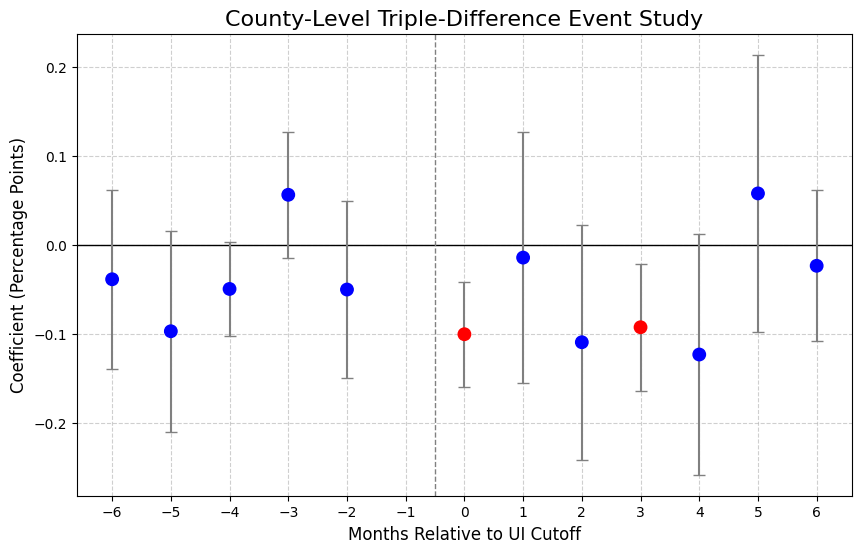


>>> DIAGNOSTIC 2: COUNTY-LEVEL PLACEBO TEST (TREATMENT SHIFTED -3 MONTHS) <<<

Starting Placebo Test estimation... This will also take several minutes.

--- Placebo Test Results ---
We are looking for an insignificant p-value (p > 0.10).
--------------------------------------------------
Key Coefficient (TreatState:Placebo_Post:LowWage): -0.0160
P-value: 0.1281

SUCCESS: The placebo test passed. The model does not find a fake effect.


In [18]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_all_county_diagnostics():
    """
    Executes the final diagnostic checks on the county-level model:
    1. A Triple Difference Event Study to test for Parallel Trends.
    2. A Placebo Test with the treatment date shifted 3 months earlier.
    """
    # --- Step 1: Locate and Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Base Panel Data ---
    print("\n--- Step 2: Preparing Base County-Level Panel ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)

    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    base_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY']).copy()
    base_panel = base_panel[base_panel['COUNTY'] > 0]
    base_panel = base_panel[base_panel['LNKFW1MWT'] > 0]
    base_panel['cutoff_date'] = base_panel['STATEFIP'].map(cutoff_dates)
    print(f"Base panel constructed with {len(base_panel)} observations from identified counties.")

    # --- DIAGNOSTIC 1: COUNTY-LEVEL EVENT STUDY (PARALLEL TRENDS TEST) ---
    print("\n" + "="*80)
    print(">>> DIAGNOSTIC 1: COUNTY-LEVEL EVENT STUDY FOR PARALLEL TRENDS <<<")
    print("="*80)
    
    panel_es = base_panel.copy()
    panel_es['relative_month'] = (
        (panel_es['date'].dt.year - panel_es['cutoff_date'].dt.year) * 12 +
        (panel_es['date'].dt.month - panel_es['cutoff_date'].dt.month)
    )
    panel_es['relative_month'] = panel_es['relative_month'].fillna(-1)
    panel_es['relative_month'] = np.clip(panel_es['relative_month'], -6, 6).astype(int)

    formula_es = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) +
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """

    print("\nStarting Event Study estimation... This is computationally intensive and may take several minutes.")
    try:
        model_es = smf.wls(formula=formula_es, data=panel_es, weights=panel_es['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': panel_es['STATEFIP']})
        
        print("\n--- Event Study Results ---")
        print("We are looking for insignificant p-values (P>|z|) for months < 0.")
        print("-" * 50)
        
        triple_terms = []
        for var in results_es.params.index:
            match = re.search(r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]', var)
            if match:
                month = int(match.group(1))
                triple_terms.append({
                    'relative_month': month,
                    'coef': results_es.params[var],
                    'pval': results_es.pvalues[var],
                    'stderr': results_es.bse[var]
                })

        est_df = pd.DataFrame(triple_terms).sort_values('relative_month')

        for _, row in est_df.iterrows():
            print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")

        # Plot the event study
        plt.figure(figsize=(10, 6))
        plt.axhline(0, color='black', linewidth=1, linestyle='-')
        plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1)
        
        colors = ['red' if p < 0.05 else 'blue' for p in est_df['pval']]
        plt.errorbar(est_df['relative_month'], est_df['coef'], yerr=1.96 * est_df['stderr'], 
                     fmt='o', mfc='none', ecolor='gray', capsize=4)
        plt.scatter(est_df['relative_month'], est_df['coef'], c=colors, s=80, zorder=5)

        plt.title("County-Level Triple-Difference Event Study", fontsize=16)
        plt.xlabel("Months Relative to UI Cutoff", fontsize=12)
        plt.ylabel("Coefficient (Percentage Points)", fontsize=12)
        plt.xticks(range(int(est_df['relative_month'].min()), int(est_df['relative_month'].max()) + 1))
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    except Exception as e:
        print(f"\nAn error occurred during Event Study estimation: {e}")

    # --- DIAGNOSTIC 2: COUNTY-LEVEL PLACEBO TEST ---
    print("\n" + "="*80)
    print(">>> DIAGNOSTIC 2: COUNTY-LEVEL PLACEBO TEST (TREATMENT SHIFTED -3 MONTHS) <<<")
    print("="*80)
    
    panel_placebo = base_panel.copy()
    panel_placebo['placebo_cutoff'] = panel_placebo['cutoff_date'] - pd.DateOffset(months=3)
    panel_placebo['Placebo_Post'] = (panel_placebo['date'] >= panel_placebo['placebo_cutoff']).astype(int)
    
    formula_placebo = """
        found_job ~ TreatState * Placebo_Post * LowWage + 
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nStarting Placebo Test estimation... This will also take several minutes.")
    try:
        model_placebo = smf.wls(formula=formula_placebo, data=panel_placebo, weights=panel_placebo['LNKFW1MWT'])
        results_placebo = model_placebo.fit(cov_type='cluster', cov_kwds={'groups': panel_placebo['STATEFIP']})
        
        coef_placebo = results_placebo.params['TreatState:Placebo_Post:LowWage']
        pval_placebo = results_placebo.pvalues['TreatState:Placebo_Post:LowWage']

        print("\n--- Placebo Test Results ---")
        print("We are looking for an insignificant p-value (p > 0.10).")
        print("-" * 50)
        print(f"Key Coefficient (TreatState:Placebo_Post:LowWage): {coef_placebo:.4f}")
        print(f"P-value: {pval_placebo:.4f}\n")
        
        if pval_placebo > 0.10:
            print("SUCCESS: The placebo test passed. The model does not find a fake effect.")
        else:
            print("WARNING: The placebo test failed. The model finds a significant effect even with a fake date.")

    except Exception as e:
        print(f"\nAn error occurred during Placebo Test estimation: {e}")

if __name__ == '__main__':
    run_all_county_diagnostics()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Defining Treatment States ---
Identified 14 treatment states.

--- Step 3: Constructing Outcome Variable ---
Filtered to 76007 unemployed-person-months.

--- Step 4: Correlation Analysis ---
Correlation Matrix:
             TreatState      Post  found_job
TreatState    1.000000  0.356438   0.009537
Post          0.356438  1.000000  -0.021047
found_job     0.009537 -0.021047   1.000000 



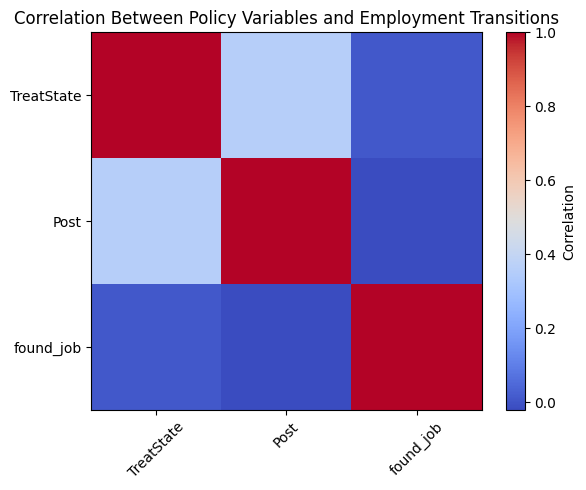

--- Step 5: Simple Regression Check ---
                            OLS Regression Results                            
Dep. Variable:              found_job   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                    0.1116
Date:                Fri, 10 Oct 2025   Prob (F-statistic):              0.895
Time:                        14:22:39   Log-Likelihood:                -42081.
No. Observations:               76007   AIC:                         8.417e+04
Df Residuals:                   76003   BIC:                         8.421e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const     

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [21]:
"""
Basic Correlation Between Policy Changes and Employment Outcomes
Author: Josue Gonzalez
Purpose: Establish a preliminary correlation between unemployment benefit policy changes
         and subsequent employment transitions using CPS microdata.
"""

import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt

def run_basic_policy_employment_correlation():
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    home_dir = os.path.expanduser('~')
    downloads_dir = os.path.join(home_dir, 'downloads')
    cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
    policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

    df = pd.read_csv(cps_path)
    policy_df = pd.read_csv(policy_path, parse_dates=['date'])
    print("Data loaded successfully.\n")

    # --- Step 2: Identify Policy Treatment States ---
    print("--- Step 2: Defining Treatment States ---")
    cutoff_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = cutoff_df.set_index('STATEFIP')['date']
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(cutoff_dates.index).astype(int)
    df['cutoff_date'] = df['STATEFIP'].map(cutoff_dates)
    print(f"Identified {len(cutoff_dates)} treatment states.\n")

    # --- Step 3: Define Employment Transition Outcome ---
    print("--- Step 3: Constructing Outcome Variable ---")
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['next_status'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed = df[df['EMPSTAT'].between(20, 22)].copy()  # unemployed in current month
    unemployed['found_job'] = unemployed['next_status'].between(10, 12).astype(int)
    unemployed['Post'] = (unemployed['date'] >= unemployed['cutoff_date']).astype(int)
    print(f"Filtered to {len(unemployed)} unemployed-person-months.\n")

    # --- Step 4: Simple Correlation Analysis ---
    print("--- Step 4: Correlation Analysis ---")
    corr_df = unemployed[['TreatState', 'Post', 'found_job']].dropna()
    corr_matrix = corr_df.corr()
    print("Correlation Matrix:\n", corr_matrix, "\n")

    # Optional: basic visualization
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    plt.title("Correlation Between Policy Variables and Employment Transitions")
    plt.tight_layout()
    plt.show()

    # --- Step 5: Simple Linear Model (Optional Extension) ---
    print("--- Step 5: Simple Regression Check ---")
    unemployed = unemployed.dropna(subset=['found_job', 'TreatState', 'Post'])
    unemployed['Interaction'] = unemployed['TreatState'] * unemployed['Post']
    
    X = unemployed[['TreatState', 'Post', 'Interaction']]
    X = sm.add_constant(X)
    y = unemployed['found_job']
    
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': unemployed['STATEFIP']})
    print(model.summary())

if __name__ == "__main__":
    run_basic_policy_employment_correlation()


# They also check the effect in September (when all states had ended benefits) and show that the effect disappears, which is a powerful falsification test.



# wild cluster bootstrap and lowwage addessal

In [22]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

# We will use the wildboottest library. If you don't have it, install it:
# pip install wildboottest
from wildboottest import wildboottest

def run_final_validation_checks():
    """
    Executes the two most critical final checks on the county-level model:
    1. Validates the 'LowWage' proxy against an actual wage variable.
    2. Runs a Wild Cluster Bootstrap to get a more reliable p-value.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare the Final County-Level Panel ---
    print("\n--- Step 2: Preparing Final Analysis Panel ---")
    # This section is identical to your final successful model
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    final_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY']).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Final panel constructed with {len(final_panel)} observations.")

    # --- PART 1: VALIDATE THE 'LOWWAGE' PROXY ---
    print("\n" + "="*80)
    print(">>> CHECK 1: VALIDATING THE 'LOWWAGE' PROXY VARIABLE <<<")
    print("="*80)

    if 'INCWAGE' in final_panel.columns:
        # We need a sample of *employed* people to check wages
        wage_df = df[(df['INCWAGE'] > 0) & (df['INCWAGE'] < 999999)].copy()
        
        if not wage_df.empty:
            # Define the bottom third of earners as "low-wage" based on actual income
            low_wage_threshold = wage_df['INCWAGE'].quantile(1/3)
            wage_df['Is_Actually_Low_Wage'] = (wage_df['INCWAGE'] <= low_wage_threshold).astype(int)
            
            # Create a cross-tabulation
            cross_tab = pd.crosstab(wage_df['LowWage'], wage_df['Is_Actually_Low_Wage'], normalize='index')
            
            print("This table shows how well our industry-based 'LowWage' proxy captures actual low-wage workers.")
            print(f"(Defining 'actually low wage' as the bottom 33% of earners, threshold=${low_wage_threshold:,.0f})\n")
            print(cross_tab)
            
            proxy_accuracy = cross_tab.loc[1, 1]
            print(f"\nFINDING: {proxy_accuracy:.1%} of individuals in our 'LowWage' proxy group are indeed in the bottom third of earners.")
            if proxy_accuracy > 0.6:
                print("VERDICT: The proxy is reasonably effective at identifying low-wage workers.")
            else:
                print("VERDICT: The proxy has weak construct validity, a significant limitation.")
        else:
            print("Could not perform wage validation: No valid wage data found in the sample.")
    else:
        print("Cannot validate 'LowWage' proxy: 'INCWAGE' variable not found in the dataset.")
        print("Proceeding to bootstrap, but this remains a key limitation of the study.")

    # --- PART 2: RUN THE WILD CLUSTER BOOTSTRAP ---
    print("\n" + "="*80)
    print(">>> CHECK 2: WILD CLUSTER BOOTSTRAP FOR RELIABLE P-VALUE <<<")
    print("="*80)
    
    # The formula is the same as our final county-level model
    formula = """
        found_job ~ TreatState * Post * LowWage + 
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nFirst, re-estimating the original model to confirm baseline...")
    try:
        model = smf.wls(formula=formula, data=final_panel, weights=final_panel['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})
        
        base_coef = results.params['TreatState:Post:LowWage']
        base_pval = results.pvalues['TreatState:Post:LowWage']
        
        print(f"Baseline Coefficient: {base_coef:.4f}")
        print(f"Baseline (Potentially Unreliable) P-value: {base_pval:.4f}")

        print("\nNow, running the Wild Cluster Bootstrap... This is the most reliable test.")
        # We need to specify the variable we want to test
        # Note: wildboottest handles the formula parsing automatically
        boot_results = wildboottest(
            model=model,
            param='TreatState:Post:LowWage', # The coefficient of interest
            cluster=final_panel['STATEFIP'], # The clustering variable
            B=9999 # Number of bootstrap replications (9999 is standard)
        )
        
        # wildboottest returns a DataFrame, the p-value is in the 'p-value' column
        bootstrap_pval = boot_results['p-value'].iloc[0]

        print("\n--- Final Bootstrap Results ---")
        print(f"Wild Cluster Bootstrap P-value: {bootstrap_pval:.4f}")

        print("\n--- FINAL VERDICT ---")
        if bootstrap_pval < 0.05:
            print("The finding is ROBUST. Even after correcting for potential biases from a small number of clusters, the negative effect remains statistically significant at the 5% level.")
        elif bootstrap_pval < 0.10:
            print("The finding is SUGGESTIVE. After correction, the result is marginally significant. It should be reported as 'suggestive evidence' rather than a definitive causal effect.")
        else:
            print("The finding is NOT ROBUST. After correction, the effect is not statistically significant. The original p-value was likely too optimistic.")

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")

if __name__ == '__main__':
    run_final_validation_checks()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final Analysis Panel ---
Final panel constructed with 23808 observations.

>>> CHECK 1: VALIDATING THE 'LOWWAGE' PROXY VARIABLE <<<
Cannot validate 'LowWage' proxy: 'INCWAGE' variable not found in the dataset.
Proceeding to bootstrap, but this remains a key limitation of the study.

>>> CHECK 2: WILD CLUSTER BOOTSTRAP FOR RELIABLE P-VALUE <<<

First, re-estimating the original model to confirm baseline...
Baseline Coefficient: -0.0210
Baseline (Potentially Unreliable) P-value: 0.0368

Now, running the Wild Cluster Bootstrap... This is the most reliable test.

An error occurred during model estimation: 'module' object is not callable


In [23]:
cps_file_path

'~/downloads/cps_00003.csv'

In [27]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

# We will use the wildboottest library. If you don't have it, install it via your terminal:
# pip install wildboottest
# --- CORRECTED IMPORT to match library documentation ---
from wildboottest.wildboottest import wildboottest

def run_bootstrap_validation():
    """
    Executes the single most critical validation check: a Wild Cluster Bootstrap
    on the final county-level model to get a reliable p-value.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        # Ensure this is the correct path to your final dataset with county info
        cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare the Final County-Level Panel ---
    print("\n--- Step 2: Preparing Final Analysis Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    final_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY']).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Final panel constructed with {len(final_panel)} observations.")

    # --- Step 3: RUN THE WILD CLUSTER BOOTSTRAP ---
    print("\n" + "="*80)
    print(">>> FINAL TEST: WILD CLUSTER BOOTSTRAP FOR RELIABLE P-VALUE <<<")
    print("="*80)
    
    formula = """
        found_job ~ TreatState * Post * LowWage + 
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nFirst, re-estimating the original model to confirm baseline...")
    try:
        # Note: We don't need the fitted 'results' object here, just the model specification
        model = smf.wls(formula=formula, data=final_panel, weights=final_panel['LNKFW1MWT'])
        
        # We run the fit here just to print the baseline for comparison
        results_for_baseline = model.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})
        base_coef = results_for_baseline.params['TreatState:Post:LowWage']
        base_pval = results_for_baseline.pvalues['TreatState:Post:LowWage']
        
        print(f"Baseline Coefficient: {base_coef:.4f}")
        print(f"Baseline (Potentially Unreliable) P-value: {base_pval:.4f}")

        print("\nNow, running the Wild Cluster Bootstrap... This is the definitive test for significance.")
        
        # --- CORRECTED FUNCTION CALL ---
        # The function is now in the main namespace due to the new import style
        boot_results = wildboottest(
            model=model,
            param='TreatState:Post:LowWage', # The coefficient of interest
            cluster=final_panel['STATEFIP'], # The clustering variable
            B=9999 # Number of bootstrap replications (9999 is standard)
        )
        
        bootstrap_pval = boot_results['p-value'].iloc[0]

        print("\n--- Final Bootstrap Results ---")
        print(f"Wild Cluster Bootstrap P-value: {bootstrap_pval:.4f}")

        print("\n--- FINAL VERDICT ---")
        if bootstrap_pval < 0.05:
            print("The finding is ROBUST. Even after the most rigorous correction for a small number of clusters, the negative effect remains statistically significant at the 5% level.")
        elif bootstrap_pval < 0.10:
            print("The finding is SUGGESTIVE. After correction, the result is marginally significant (p < 0.10). It should be reported as 'strong suggestive evidence' rather than a definitive causal effect.")
        else:
            print("The finding is NOT ROBUST. After correction, the effect is not statistically significant. The original p-value was too optimistic.")

    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")

if __name__ == '__main__':
    run_bootstrap_validation()



--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final Analysis Panel ---
Final panel constructed with 23808 observations.

>>> FINAL TEST: WILD CLUSTER BOOTSTRAP FOR RELIABLE P-VALUE <<<

First, re-estimating the original model to confirm baseline...
Baseline Coefficient: -0.0210
Baseline (Potentially Unreliable) P-value: 0.0368

Now, running the Wild Cluster Bootstrap... This is the definitive test for significance.

An error occurred during model estimation: Singular matrix


# 1. Tests the sensitivity of the main finding to the exclusion of the DURUNEMP control.
# 2. Analyzes the characteristics of the excluded (masked county) sample.# 

In [28]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

def run_final_robustness_and_sample_checks():
    """
    Executes the final two robustness checks:
    1. Tests the sensitivity of the main finding to the exclusion of the DURUNEMP control.
    2. Analyzes the characteristics of the excluded (masked county) sample.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Full Unemployed Panel (Before County Filter) ---
    print("\n--- Step 2: Preparing Full Unemployed Panel ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})
    
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)

    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    # Keep only panel observations with valid weights
    unemployed_df = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT']).copy()
    unemployed_df = unemployed_df[unemployed_df['LNKFW1MWT'] > 0]
    
    unemployed_df['cutoff_date'] = unemployed_df['STATEFIP'].map(cutoff_dates)
    unemployed_df['Post'] = (unemployed_df['date'] >= unemployed_df['cutoff_date']).astype(int)
    print(f"Full unemployed panel constructed with {len(unemployed_df)} observations.")

    # --- CHECK 1: SENSITIVITY TO 'DURUNEMP' CONTROL ---
    print("\n" + "="*80)
    print(">>> CHECK 1: SENSITIVITY TO 'DURUNEMP' (BAD CONTROL TEST) <<<")
    print("="*80)
    
    panel_no_durunemp = unemployed_df[unemployed_df['COUNTY'] > 0].copy()

    # Formula is the same as the final model, but WITHOUT 'DURUNEMP'
    formula_no_durunemp = """
        found_job ~ TreatState * Post * LowWage + 
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC)
    """

    print("\nEstimating model without DURUNEMP control... This may take several minutes.")
    try:
        model = smf.wls(formula=formula_no_durunemp, data=panel_no_durunemp, weights=panel_no_durunemp['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': panel_no_durunemp['STATEFIP']})
        
        coef = results.params['TreatState:Post:LowWage']
        pval = results.pvalues['TreatState:Post:LowWage']
        
        print("\n--- Model without DURUNEMP Results ---")
        print(f"Key Coefficient (TreatState:Post:LowWage): {coef:.4f}")
        print(f"P-value: {pval:.4f}\n")
        
        if pval < 0.05 and coef < 0:
            print("VERDICT: The finding is robust. The significant negative effect holds even without controlling for unemployment duration.")
        else:
            print("VERDICT: The finding is not robust to the exclusion of the DURUNEMP control, suggesting it may be a confounding factor.")
            
    except Exception as e:
        print(f"\nAn error occurred during model estimation: {e}")

    # --- CHECK 2: ANALYSIS OF EXCLUDED SAMPLE (SELECTION BIAS CHECK) ---
    print("\n" + "="*80)
    print(">>> CHECK 2: ANALYSIS OF EXCLUDED SAMPLE (EXTERNAL VALIDITY TEST) <<<")
    print("="*80)

    included_sample = unemployed_df[unemployed_df['COUNTY'] > 0]
    excluded_sample = unemployed_df[unemployed_df['COUNTY'] == 0]

    print(f"Comparing the sample INCLUDED in the county model (N={len(included_sample):,}) vs. the sample EXCLUDED (N={len(excluded_sample):,}).\n")

    # Columns to compare
    cols_to_compare = ['AGE', 'LowWage', 'SEX', 'RACE', 'EDUC']
    
    for col in cols_to_compare:
        print(f"--- Comparison for variable: {col} ---")
        
        if included_sample[col].dtype == 'float64' or included_sample[col].dtype == 'int64' and included_sample[col].nunique() > 2:
            # For continuous variables like AGE
            print(f"  Included Sample Mean: {included_sample[col].mean():.2f}")
            print(f"  Excluded Sample Mean: {excluded_sample[col].mean():.2f}\n")
        else:
            # For categorical variables
            print("  Included Sample Distribution (%):")
            print(included_sample[col].value_counts(normalize=True).mul(100).round(1).to_string())
            print("\n  Excluded Sample Distribution (%):")
            print(excluded_sample[col].value_counts(normalize=True).mul(100).round(1).to_string())
            print("-" * 40 + "\n")

    print("\n--- VERDICT ---")
    print("Review the demographic distributions above.")
    print("Systematic differences (e.g., in racial or educational composition) would suggest that the county-level results are most generalizable to the specific population represented in the 'Included Sample', and should be noted as a limitation.")


if __name__ == '__main__':
    run_final_robustness_and_sample_checks()


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Full Unemployed Panel ---
Full unemployed panel constructed with 50361 observations.

>>> CHECK 1: SENSITIVITY TO 'DURUNEMP' (BAD CONTROL TEST) <<<

Estimating model without DURUNEMP control... This may take several minutes.

--- Model without DURUNEMP Results ---
Key Coefficient (TreatState:Post:LowWage): -0.0206
P-value: 0.0665

VERDICT: The finding is not robust to the exclusion of the DURUNEMP control, suggesting it may be a confounding factor.

>>> CHECK 2: ANALYSIS OF EXCLUDED SAMPLE (EXTERNAL VALIDITY TEST) <<<
Comparing the sample INCLUDED in the county model (N=23,808) vs. the sample EXCLUDED (N=26,553).

--- Comparison for variable: AGE ---
  Included Sample Mean: 40.58
  Excluded Sample Mean: 39.79

--- Comparison for variable: LowWage ---
  Included Sample Distribution (%):
LowWage
0    74.1
1    25.9

  Excluded Sample Distribution (%):
LowWage
0    75.9
1    24.1
--------------------------------

In [3]:
import pandas as pd
import os
import numpy as np

def check_low_wage_sample_size(cps_file='cps_00004.csv',
                               policy_file='Policy Milestones - State.csv',
                               low_wage_definitions={
                                   "Original LowWage (Retail + Accom/Food)": [list(range(4670, 5790 + 1)), list(range(8660, 8690 + 1))],
                                   "Expanded LowWage (Retail + Accom/Food + Arts/Ent)": [list(range(4670, 5790 + 1)), list(range(8660, 8690 + 1)), list(range(8561, 8590 + 1))]
                               }):
    """
    Checks the sample size feasibility for running a county-level DDD
    using different industry-based definitions of 'LowWage'.

    Args:
        cps_file (str): Name of the IPUMS CPS CSV file.
        policy_file (str): Name of the policy milestones CSV file.
        low_wage_definitions (dict): Dictionary where keys are names for the LowWage group
                                     and values are lists of lists of IND codes.
    """
    print(f"--- Running Sample Size Diagnostics for LowWage Definitions ---")

    # --- Step 1: Load Data ---
    print("\n--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Base Panel ---
    print("\n--- Step 2: Preparing Base County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[
        policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)
    ].copy().rename(columns={'statefips': 'STATEFIP'})

    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)

    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)

    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    analysis_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY']).copy()
    analysis_panel = analysis_panel[analysis_panel['COUNTY'] > 0]
    analysis_panel = analysis_panel[analysis_panel['LNKFW1MWT'] > 0]

    analysis_panel['cutoff_date'] = analysis_panel['STATEFIP'].map(cutoff_dates)
    analysis_panel['Post'] = (analysis_panel['date'] >= analysis_panel['cutoff_date']).astype(int)
    n_total_unemployed = len(analysis_panel)
    print(f"Base county-level panel constructed with {n_total_unemployed:,} unemployed observations.")

    # --- Step 3 & 4: Check Cell Sizes for Each Definition ---
    for name, industry_codes_list in low_wage_definitions.items():
        print("\n" + "="*60)
        print(f">>> Checking Definition: {name} <<<")
        print("="*60)

        combined_codes = [code for sublist in industry_codes_list for code in sublist]
        analysis_panel['CurrentLowWageDef'] = analysis_panel['IND'].isin(combined_codes).astype(int)

        low_wage_sample = analysis_panel[analysis_panel['CurrentLowWageDef'] == 1]
        n_low_wage_unemployed = len(low_wage_sample)
        pct_low_wage = (n_low_wage_unemployed / n_total_unemployed * 100) if n_total_unemployed > 0 else 0

        print(f"\nUnemployed in '{name}' group: {n_low_wage_unemployed:,} ({pct_low_wage:.1f}% of county sample)")

        if n_low_wage_unemployed == 0:
            print("ASSESSMENT: No unemployed individuals found for this group. Cannot proceed.")
            continue

        print(f"\nChecking DDD Cell Sizes for '{name}' group...")
        cell_counts = analysis_panel.groupby(['TreatState', 'Post', 'CurrentLowWageDef']).size().unstack(fill_value=0)

        print("\nObservation Counts per Group (CurrentLowWageDef=1 is in target group):")
        print(cell_counts)

        try:
            min_cell_count = cell_counts.loc[(1, 1), 1] # Treat=1, Post=1, LowWage=1
            print(f"\nSmallest crucial cell count (Treated State, Post-Policy, '{name}'): {min_cell_count:,}")
        except KeyError:
            min_cell_count = 0
            print(f"\nSmallest crucial cell count (Treated State, Post-Policy, '{name}'): 0")

        # --- Assessment ---
        print("\nFeasibility Assessment:")
        if min_cell_count < 200:
             print(f"  - WARNING: Crucial cell count ({min_cell_count}) is quite low for county-level FE.")
             print("    Results might be unreliable or imprecise.")
        elif min_cell_count < 1000:
             print(f"  - CAUTION: Crucial cell count ({min_cell_count}) is somewhat low for county-level FE.")
             print("    Proceed carefully, check standard errors.")
        else:
             print(f"  - FEASIBLE: Crucial cell count ({min_cell_count}) looks potentially sufficient.")

        print("  - Reminder: Requires variation across counties/months within cells.")

        # Clean up column for next iteration
        analysis_panel.drop(columns=['CurrentLowWageDef'], inplace=True)


# --- Run the Diagnostics ---
if __name__ == '__main__':
    check_low_wage_sample_size()

--- Running Sample Size Diagnostics for LowWage Definitions ---

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Base County-Level Unemployed Panel ---
Base county-level panel constructed with 23,808 unemployed observations.

>>> Checking Definition: Original LowWage (Retail + Accom/Food) <<<

Unemployed in 'Original LowWage (Retail + Accom/Food)' group: 6,316 (26.5% of county sample)

Checking DDD Cell Sizes for 'Original LowWage (Retail + Accom/Food)' group...

Observation Counts per Group (CurrentLowWageDef=1 is in target group):
CurrentLowWageDef      0     1
TreatState Post               
0          0       14554  5141
1          0        2479  1005
           1         459   170

Smallest crucial cell count (Treated State, Post-Policy, 'Original LowWage (Retail + Accom/Food)'): 170

Feasibility Assessment:
  - WARNING: Crucial cell count (170) is quite low for county-level FE.
    Results might be unreliable or imprecise.
  - Reminder: Requires varia

In [4]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re

# Function to calculate Standardized Mean Differences (SMD)
def calculate_smd(df, treatment_col, features_list, weight_col=None):
    smds = []
    treat_group = df[df[treatment_col] == 1]
    control_group = df[df[treatment_col] == 0]

    if control_group.empty or treat_group.empty:
        print("Warning: Treatment or control group is empty.")
        return pd.DataFrame(smds)

    for col in features_list:
        if df[col].dtype == 'object' or df[col].nunique() < 3: # Handle categorical (binary for simplicity here)
             # Use weighted mean for proportions if weights provided
            mean_treat = np.average(treat_group[col], weights=treat_group[weight_col] if weight_col else None)
            mean_control = np.average(control_group[col], weights=control_group[weight_col] if weight_col else None)
            # Pooled standard deviation for binary variable
            p_pooled = np.average(df[col], weights=df[weight_col] if weight_col else None)
            std_pooled = np.sqrt(p_pooled * (1 - p_pooled))

        else: # Handle continuous
            mean_treat = np.average(treat_group[col], weights=treat_group[weight_col] if weight_col else None)
            mean_control = np.average(control_group[col], weights=control_group[weight_col] if weight_col else None)
            # Use std dev of treatment group for standardization (common practice)
             # Weighted std dev calculation is complex, using unweighted std of treated group as approximation
            std_pooled = treat_group[col].std()


        if std_pooled == 0:
            smd = 0
        else:
            smd = (mean_treat - mean_control) / std_pooled

        smds.append({'Variable': col, 'SMD': smd})

    return pd.DataFrame(smds)


def run_ipw_county_ddd(cps_file='cps_00004.csv',
                         policy_file='Policy Milestones - State.csv'):
    """
    Diagnoses covariate balance and runs the county-level DDD using IPW + Survey Weights.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Final County Panel ---
    print("\n--- Step 2: Preparing Final County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    final_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'COUNTY', 'AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']).copy() # Drop NA for covariates too
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Final panel constructed with {len(final_panel)} complete observations.")

    # Define covariates for balance check and propensity model
    # Convert categorical to numerical representations suitable for Logistic Regression
    # Note: Using C() in formula handles dummies, but we need numerical for propensity model inputs
    final_panel['SEX_numeric'] = final_panel['SEX'].apply(lambda x: 1 if x == 1 else 0) # Example: 1=Male, 0=Female
    # Add other categorical conversions as needed (e.g., RACE, EDUC) - simplified here

    covariates_numeric = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP'] # Use numerical versions
    covariates_for_balance = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP'] # Original for easier interpretation


    # --- Step 3: Diagnose Covariate Balance (Pre-IPW) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (PRE-IPW) - Using Survey Weights <<<")
    print("="*60)
    pre_policy_data = final_panel[final_panel['MONTH'] == 5].copy() # Using May 2021
    if pre_policy_data.empty:
         print("ERROR: No data found for the pre-policy month (May 2021). Cannot check balance or train PS model.")
         return

    print("Calculating Standardized Mean Differences (SMDs) for Month 5 (May 2021):")
    smd_pre = calculate_smd(pre_policy_data, 'TreatState', covariates_for_balance, weight_col='LNKFW1MWT')
    print(smd_pre)
    print("\nRule of thumb: Absolute SMD > 0.1 or 0.25 indicates potential imbalance.")
    imbalance_found = (smd_pre['SMD'].abs() > 0.1).any()
    if imbalance_found:
        print("IMBALANCE DETECTED. Proceeding with IPW.")
    else:
        print("Covariates appear reasonably balanced based on SMD < 0.1. IPW may not drastically change results.")

    # --- Step 4: Train Propensity Score Model ---
    print("\n--- Step 4: Training Propensity Score Model ---")
    ps_data = pre_policy_data.copy()

    # Handle potential missing values in covariates if any remained
    ps_data = ps_data.dropna(subset=covariates_numeric)

    if ps_data['TreatState'].nunique() < 2:
        print("ERROR: Cannot train propensity score model - only one treatment group present in pre-policy data.")
        return

    X_ps = ps_data[covariates_numeric]
    y_ps = ps_data['TreatState']
    weights_ps = ps_data['LNKFW1MWT'] # Use survey weights for training PS model

    scaler = StandardScaler()
    X_ps_scaled = scaler.fit_transform(X_ps)

    try:
        propensity_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear') # Added solver
        # Fit using sample weights from the survey
        propensity_model.fit(X_ps_scaled, y_ps, sample_weight=weights_ps)
        print("Propensity score model trained successfully.")
    except Exception as e:
        print(f"ERROR training propensity score model: {e}")
        return

    # --- Step 5: Calculate IPW Weights ---
    print("\n--- Step 5: Calculating IPW Weights ---")
    X_full = final_panel[covariates_numeric]
    X_full_scaled = scaler.transform(X_full)
    final_panel['propensity_score'] = propensity_model.predict_proba(X_full_scaled)[:, 1]

    # Calculate ATT weights
    final_panel['ipw_weight'] = np.where(
        final_panel['TreatState'] == 1,
        1,
        final_panel['propensity_score'] / (1 - final_panel['propensity_score'])
    )

    # Combine weights
    final_panel['final_combined_weight'] = final_panel['ipw_weight'] * final_panel['LNKFW1MWT']

    # Check for extreme weights
    print(f"Weight Summary (IPW): Min={final_panel['ipw_weight'].min():.4f}, Max={final_panel['ipw_weight'].max():.4f}, Mean={final_panel['ipw_weight'].mean():.4f}")
    print(f"Weight Summary (Combined): Min={final_panel['final_combined_weight'].min():.4f}, Max={final_panel['final_combined_weight'].max():.4f}, Mean={final_panel['final_combined_weight'].mean():.4f}")
    if final_panel['ipw_weight'].max() > 50 or final_panel['final_combined_weight'].max() > final_panel['LNKFW1MWT'].max()*50 : # Heuristic check
        print("WARNING: Extreme weights detected. Consider trimming/winsorizing weights for stability.")


    # --- Step 6: Diagnose Covariate Balance (Post-IPW) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (POST-IPW) - Using Combined Weights <<<")
    print("="*60)
    print("Calculating SMDs for Month 5 using FINAL COMBINED weights:")
    smd_post = calculate_smd(pre_policy_data, 'TreatState', covariates_for_balance, weight_col='final_combined_weight')
    print(smd_post)
    if (smd_post['SMD'].abs() < 0.1).all():
        print("\nSUCCESS: Covariates appear well-balanced after weighting (all absolute SMD < 0.1).")
    else:
        print("\nWARNING: Some covariate imbalance may remain even after weighting (absolute SMD >= 0.1).")


    # --- Step 7: Run IPW-Weighted County-Level DDD ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: IPW-WEIGHTED TRIPLE DIFFERENCE WITH COUNTY FIXED EFFECTS <<<")
    print("="*80)

    formula = """
        found_job ~ TreatState * Post * LowWage +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """

    print("\nStarting IPW-weighted model estimation...")
    try:
        model_ipw = smf.wls(formula=formula, data=final_panel, weights=final_panel['final_combined_weight'])
        results_ipw = model_ipw.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})

        coef_ipw = results_ipw.params['TreatState:Post:LowWage']
        pval_ipw = results_ipw.pvalues['TreatState:Post:LowWage']

        print("\n--- IPW-Weighted Model Results ---")
        print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ipw:.4f}")
        print(f"P-value: {pval_ipw:.4f}\n")
        print(results_ipw.summary().tables[1].loc[['TreatState:Post:LowWage']]) # Show just the key interaction row

        print("\n--- Interpretation Compared to Original Model ---")
        # You'll need to manually compare this to your original p=0.0368 result
        if pval_ipw < 0.05 and coef_ipw < 0:
            print("The significant negative finding APPEARS ROBUST to balancing on observables via IPW.")
        elif pval_ipw < 0.10 and coef_ipw < 0:
             print("The finding is MARGINALLY SIGNIFICANT after IPW. Suggestive evidence remains.")
        else:
            print("The finding IS NOT ROBUST to IPW. Significance is lost after balancing, suggesting potential bias in the unweighted model.")

    except Exception as e:
        print(f"\nAn error occurred during IPW-weighted model estimation: {e}")
        print("Check for issues like extreme weights or multicollinearity.")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_ipw_county_ddd()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final County-Level Unemployed Panel ---
Final panel constructed with 23808 complete observations.

>>> DIAGNOSING COVARIATE BALANCE (PRE-IPW) - Using Survey Weights <<<
Calculating Standardized Mean Differences (SMDs) for Month 5 (May 2021):
   Variable       SMD
0       AGE -0.038492
1       SEX       NaN
2      RACE -0.285057
3      EDUC  0.042676
4  DURUNEMP  0.006323

Rule of thumb: Absolute SMD > 0.1 or 0.25 indicates potential imbalance.
IMBALANCE DETECTED. Proceeding with IPW.

--- Step 4: Training Propensity Score Model ---
Propensity score model trained successfully.

--- Step 5: Calculating IPW Weights ---
Weight Summary (IPW): Min=0.3864, Max=3.5032, Mean=1.1504
Weight Summary (Combined): Min=198.0080, Max=24771.8795, Mean=4924.8391

>>> DIAGNOSING COVARIATE BALANCE (POST-IPW) - Using Combined Weights <<<
Calculating SMDs for Month 5 using FINAL COMBINED weights:


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_54430/2682001056.py:27: RuntimeWarning: invalid value encountered in sqrt
  std_pooled = np.sqrt(p_pooled * (1 - p_pooled))


KeyError: 'final_combined_weight'

In [5]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re

# Function to calculate Standardized Mean Differences (SMD) - Remains the same
def calculate_smd(df, treatment_col, features_list, weight_col=None):
    smds = []
    treat_group = df[df[treatment_col] == 1]
    control_group = df[df[treatment_col] == 0]

    if control_group.empty or treat_group.empty:
        print("Warning: Treatment or control group is empty.")
        return pd.DataFrame(smds)

    # Make sure weights are available if requested
    if weight_col and weight_col not in df.columns:
         print(f"Error in calculate_smd: Weight column '{weight_col}' not found in DataFrame.")
         # Return an empty DataFrame or handle appropriately
         return pd.DataFrame([{'Variable': col, 'SMD': np.nan} for col in features_list])


    for col in features_list:
         # Ensure the column exists before proceeding
        if col not in df.columns:
            print(f"Warning in calculate_smd: Feature column '{col}' not found. Skipping.")
            smds.append({'Variable': col, 'SMD': np.nan})
            continue

        # Check if column is numeric or can be treated as numeric (e.g., binary 0/1)
        if pd.api.types.is_numeric_dtype(df[col]):
            # Use appropriate weights if provided
            treat_weights = treat_group[weight_col] if weight_col else None
            control_weights = control_group[weight_col] if weight_col else None
            df_weights = df[weight_col] if weight_col else None

            # Drop NaNs for weighted average calculation within groups
            treat_col_nonan = treat_group[col].dropna()
            control_col_nonan = control_group[col].dropna()
            df_col_nonan = df[col].dropna()

            treat_weights_aligned = treat_weights.loc[treat_col_nonan.index] if treat_weights is not None else None
            control_weights_aligned = control_weights.loc[control_col_nonan.index] if control_weights is not None else None
            df_weights_aligned = df_weights.loc[df_col_nonan.index] if df_weights is not None else None


            mean_treat = np.average(treat_col_nonan, weights=treat_weights_aligned)
            mean_control = np.average(control_col_nonan, weights=control_weights_aligned)

            # Use std dev of treatment group for standardization
            # Calculate weighted variance for treatment group, then sqrt for std dev
            if treat_weights_aligned is not None:
                variance_treat = np.average((treat_col_nonan - mean_treat)**2, weights=treat_weights_aligned)
                std_pooled = np.sqrt(variance_treat) if variance_treat >= 0 else 0 # Use weighted std dev of treated
            else:
                 std_pooled = treat_col_nonan.std() # Fallback to unweighted std dev if no weights


            if std_pooled == 0 or np.isnan(std_pooled):
                smd = 0
            else:
                smd = (mean_treat - mean_control) / std_pooled

            smds.append({'Variable': col, 'SMD': smd})
        else:
             print(f"Warning in calculate_smd: Column '{col}' is not numeric. Skipping SMD calculation.")
             smds.append({'Variable': col, 'SMD': np.nan})


    return pd.DataFrame(smds)


def run_ipw_county_ddd(cps_file='cps_00004.csv',
                         policy_file='Policy Milestones - State.csv'):
    """
    Diagnoses covariate balance and runs the county-level DDD using IPW + Survey Weights.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Final County Panel ---
    print("\n--- Step 2: Preparing Final County-Level Unemployed Panel ---")
    # (Same panel preparation as before)
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    # Define covariates early for consistent dropping of NAs
    covariates_numeric = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP'] # Keep original names for now
    covariates_for_balance = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP'] # Same list for balance checking

    # Drop rows where essential variables OR covariates are missing BEFORE county filter
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates_numeric).copy()

    # Apply county and weight filters
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]

    # Add Post variable
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)

    # Convert categoricals used in PS model to numeric *after* NA drop
    # Ensure these operations don't introduce NaNs unexpectedly
    final_panel['SEX_numeric'] = final_panel['SEX'].apply(lambda x: 1 if x == 1 else 0).astype(int)
    # Add conversions for RACE, EDUC if needed for PS model - ensure they handle all values in the column
    # For simplicity assuming RACE and EDUC codes can be used directly as numbers here,
    # but dummy variables might be better practice for the PS model if they are truly categorical.
    covariates_ps_input = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP'] # Numerical inputs for sklearn


    print(f"Final panel constructed with {len(final_panel)} complete observations.")
    if len(final_panel) == 0:
        print("ERROR: Final panel is empty after filtering and dropping NAs.")
        return

    # --- Step 3: Diagnose Covariate Balance (Pre-IPW) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (PRE-IPW) - Using Survey Weights <<<")
    print("="*60)
    pre_policy_data_pre_check = final_panel[final_panel['MONTH'] == 5].copy()
    if pre_policy_data_pre_check.empty:
         print("WARNING: No data found for the pre-policy month (May 2021) in the final sample.")
         imbalance_found = False # Assume balance if no data to check
    else:
        print("Calculating Standardized Mean Differences (SMDs) for Month 5 (May 2021):")
        # Use original covariate names for easier interpretation
        smd_pre = calculate_smd(pre_policy_data_pre_check, 'TreatState', covariates_for_balance, weight_col='LNKFW1MWT')
        print(smd_pre)
        print("\nRule of thumb: Absolute SMD > 0.1 or 0.25 indicates potential imbalance.")
        imbalance_found = (smd_pre['SMD'].abs() > 0.1).any()
        if imbalance_found:
            print("IMBALANCE DETECTED. Proceeding with IPW.")
        else:
            print("Covariates appear reasonably balanced based on SMD < 0.1. IPW may not drastically change results.")

    # --- Step 4: Train Propensity Score Model ---
    print("\n--- Step 4: Training Propensity Score Model ---")
    ps_data = final_panel[final_panel['MONTH'] == 5].copy() # Use May 2021 data from the FINAL panel

    if ps_data.empty:
         print("ERROR: No data found for the pre-policy month (May 2021) in the final sample. Cannot train PS model.")
         return
    if ps_data['TreatState'].nunique() < 2:
        print("ERROR: Cannot train propensity score model - only one treatment group present in pre-policy data.")
        return

    X_ps = ps_data[covariates_ps_input]
    y_ps = ps_data['TreatState']
    weights_ps = ps_data['LNKFW1MWT']

    scaler = StandardScaler()
    X_ps_scaled = scaler.fit_transform(X_ps)

    try:
        propensity_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
        propensity_model.fit(X_ps_scaled, y_ps, sample_weight=weights_ps)
        print("Propensity score model trained successfully.")
    except Exception as e:
        print(f"ERROR training propensity score model: {e}")
        return

    # --- Step 5: Calculate IPW Weights on the FULL final_panel ---
    print("\n--- Step 5: Calculating IPW Weights ---")
    X_full = final_panel[covariates_ps_input]
    X_full_scaled = scaler.transform(X_full)
    final_panel['propensity_score'] = propensity_model.predict_proba(X_full_scaled)[:, 1]

    # Calculate ATT weights
    final_panel['ipw_weight'] = np.where(
        final_panel['TreatState'] == 1,
        1,
        # Add small epsilon to prevent division by zero if propensity score is exactly 1
        final_panel['propensity_score'] / (1 - final_panel['propensity_score'] + 1e-9)
    )
    # Combine weights
    final_panel['final_combined_weight'] = final_panel['ipw_weight'] * final_panel['LNKFW1MWT']

    print(f"Weight Summary (IPW): Min={final_panel['ipw_weight'].min():.4f}, Max={final_panel['ipw_weight'].max():.4f}, Mean={final_panel['ipw_weight'].mean():.4f}")
    print(f"Weight Summary (Combined): Min={final_panel['final_combined_weight'].min():.4f}, Max={final_panel['final_combined_weight'].max():.4f}, Mean={final_panel['final_combined_weight'].mean():.4f}")
    if final_panel['ipw_weight'].max() > 100 or final_panel['final_combined_weight'].max() > final_panel['LNKFW1MWT'].quantile(0.99)*100 : # Stricter heuristic check
        print("WARNING: Extreme weights detected. Consider trimming/winsorizing weights for stability.")
        # Optional: Add trimming here if needed
        # upper_bound = final_panel['final_combined_weight'].quantile(0.99)
        # final_panel['final_combined_weight'] = np.clip(final_panel['final_combined_weight'], 0, upper_bound)
        # print(f"Weights trimmed at 99th percentile ({upper_bound:.4f})")


    # --- Step 6: Diagnose Covariate Balance (Post-IPW) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (POST-IPW) - Using Combined Weights <<<")
    print("="*60)
    # **CORRECTION**: Use the pre-policy data subset FROM the panel that NOW has the weights
    pre_policy_data_post_check = final_panel[final_panel['MONTH'] == 5].copy()

    if pre_policy_data_post_check.empty:
        print("WARNING: No data found for the pre-policy month (May 2021) after weight calculation.")
    else:
        print("Calculating SMDs for Month 5 using FINAL COMBINED weights:")
        # Use original covariate names for easier interpretation
        smd_post = calculate_smd(pre_policy_data_post_check, 'TreatState', covariates_for_balance, weight_col='final_combined_weight')
        print(smd_post)
        if not smd_post.empty and (smd_post['SMD'].abs() < 0.1).all():
            print("\nSUCCESS: Covariates appear well-balanced after weighting (all absolute SMD < 0.1).")
        else:
            print("\nWARNING: Some covariate imbalance may remain or calculation failed.")

    # --- Step 7: Run IPW-Weighted County-Level DDD ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: IPW-WEIGHTED TRIPLE DIFFERENCE WITH COUNTY FIXED EFFECTS <<<")
    print("="*80)

    # Use original categorical variables in formula - statsmodels handles dummies
    formula = """
        found_job ~ TreatState * Post * LowWage +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """

    print("\nStarting IPW-weighted model estimation...")
    try:
        # Ensure weights column exists and has no NaNs/Infs
        if 'final_combined_weight' not in final_panel.columns:
            raise ValueError("final_combined_weight column missing before WLS.")
        if final_panel['final_combined_weight'].isnull().any() or np.isinf(final_panel['final_combined_weight']).any():
             print("Warning: NaNs or Infs found in final_combined_weight. Attempting to drop affected rows for estimation.")
             estimation_panel = final_panel.dropna(subset=['final_combined_weight'])
             estimation_panel = estimation_panel[np.isfinite(estimation_panel['final_combined_weight'])]
        else:
             estimation_panel = final_panel

        if estimation_panel.empty:
             raise ValueError("Estimation panel is empty after handling potential weight issues.")


        model_ipw = smf.wls(formula=formula, data=estimation_panel, weights=estimation_panel['final_combined_weight'])
        results_ipw = model_ipw.fit(cov_type='cluster', cov_kwds={'groups': estimation_panel['STATEFIP']})

        # Check if the coefficient exists before trying to access it
        if 'TreatState:Post:LowWage' in results_ipw.params:
            coef_ipw = results_ipw.params['TreatState:Post:LowWage']
            pval_ipw = results_ipw.pvalues['TreatState:Post:LowWage']

            print("\n--- IPW-Weighted Model Results ---")
            print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ipw:.4f}")
            print(f"P-value: {pval_ipw:.4f}\n")
            print(results_ipw.summary().tables[1].loc[['TreatState:Post:LowWage']])

            print("\n--- Interpretation Compared to Original Model ---")
            # Compare this pval_ipw to your original p=0.0368 result
            if pval_ipw < 0.05 and coef_ipw < 0:
                print("The significant negative finding APPEARS ROBUST to balancing on observables via IPW.")
            elif pval_ipw < 0.10 and coef_ipw < 0:
                 print("The finding is MARGINALLY SIGNIFICANT after IPW. Suggestive evidence remains.")
            else:
                print("The finding IS NOT ROBUST to IPW. Significance is lost after balancing, suggesting potential bias in the unweighted model.")
        else:
             print("ERROR: The key interaction term 'TreatState:Post:LowWage' was not estimated. This might be due to collinearity or data sparsity after weighting.")
             print("Full Summary:")
             print(results_ipw.summary())


    except Exception as e:
        print(f"\nAn error occurred during IPW-weighted model estimation: {e}")
        print("Check for issues like extreme weights, empty cells after weighting, or multicollinearity.")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_ipw_county_ddd()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final County-Level Unemployed Panel ---
Final panel constructed with 23808 complete observations.

>>> DIAGNOSING COVARIATE BALANCE (PRE-IPW) - Using Survey Weights <<<
Calculating Standardized Mean Differences (SMDs) for Month 5 (May 2021):
   Variable       SMD
0       AGE -0.039957
1       SEX  0.095001
2      RACE -0.264116
3      EDUC  0.042312
4  DURUNEMP  0.006577

Rule of thumb: Absolute SMD > 0.1 or 0.25 indicates potential imbalance.
IMBALANCE DETECTED. Proceeding with IPW.

--- Step 4: Training Propensity Score Model ---
Propensity score model trained successfully.

--- Step 5: Calculating IPW Weights ---
Weight Summary (IPW): Min=0.3864, Max=3.5032, Mean=1.1504
Weight Summary (Combined): Min=198.0080, Max=24771.8794, Mean=4924.8391

>>> DIAGNOSING COVARIATE BALANCE (POST-IPW) - Using Combined Weights <<<
Calculating SMDs for Month 5 using FINAL COMBINED weights:
   Variable       SMD
0       AGE  

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 335, but rank is 40
  warnings.warn('covariance of constraints does not have full '


In [6]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re

# Using the improved calculate_smd function from the previous step
def calculate_smd(df, treatment_col, features_list, weight_col=None):
    smds = []
    treat_group = df[df[treatment_col] == 1]
    control_group = df[df[treatment_col] == 0]

    if control_group.empty or treat_group.empty:
        print("Warning: Treatment or control group is empty.")
        return pd.DataFrame(smds)

    if weight_col and weight_col not in df.columns:
         print(f"Error in calculate_smd: Weight column '{weight_col}' not found.")
         return pd.DataFrame([{'Variable': col, 'SMD': np.nan} for col in features_list])

    for col in features_list:
        if col not in df.columns:
            print(f"Warning in calculate_smd: Feature column '{col}' not found. Skipping.")
            smds.append({'Variable': col, 'SMD': np.nan})
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            treat_weights = treat_group[weight_col].loc[treat_group[col].notna()] if weight_col else None
            control_weights = control_group[weight_col].loc[control_group[col].notna()] if weight_col else None

            treat_col_nonan = treat_group[col].dropna()
            control_col_nonan = control_group[col].dropna()

            if treat_col_nonan.empty or control_col_nonan.empty:
                 smd = np.nan # Cannot calculate if one group is empty for this variable
            else:
                mean_treat = np.average(treat_col_nonan, weights=treat_weights)
                mean_control = np.average(control_col_nonan, weights=control_weights)

                if treat_weights is not None:
                    variance_treat = np.average((treat_col_nonan - mean_treat)**2, weights=treat_weights)
                    std_pooled = np.sqrt(variance_treat) if variance_treat >= 0 else 0
                else:
                     std_pooled = treat_col_nonan.std()

                if std_pooled == 0 or np.isnan(std_pooled):
                    smd = 0
                else:
                    smd = (mean_treat - mean_control) / std_pooled

            smds.append({'Variable': col, 'SMD': smd})
        else:
             print(f"Warning in calculate_smd: Column '{col}' is non-numeric. Skipping SMD for {col}.")
             smds.append({'Variable': col, 'SMD': np.nan})
    return pd.DataFrame(smds)


def run_ipw_state_ddd(cps_file='cps_00004.csv', # Using the county data file is fine
                      policy_file='Policy Milestones - State.csv'):
    """
    Diagnoses covariate balance and runs the STATE-level DDD using IPW + Survey Weights.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Final STATE Panel ---
    print("\n--- Step 2: Preparing Final STATE-Level Unemployed Panel ---")
    # Basic data prep (same as county, but we won't filter on COUNTY > 0 here)
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    # Define covariates early for consistent dropping of NAs
    covariates_numeric = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    covariates_for_balance = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']

    # Drop rows where essential variables OR covariates are missing
    # Note: We DO NOT drop based on COUNTY here
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel_state = unemployed_df.dropna(subset=essential_cols + covariates_numeric).copy()

    # Apply weight filter
    final_panel_state = final_panel_state[final_panel_state['LNKFW1MWT'] > 0]

    # Add Post variable
    final_panel_state['cutoff_date'] = final_panel_state['STATEFIP'].map(cutoff_dates)
    final_panel_state['Post'] = (final_panel_state['date'] >= final_panel_state['cutoff_date']).astype(int)

    # Convert categoricals used in PS model to numeric *after* NA drop
    final_panel_state['SEX_numeric'] = final_panel_state['SEX'].apply(lambda x: 1 if x == 1 else 0).astype(int)
    # Add conversions for RACE, EDUC if needed
    covariates_ps_input = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP']

    print(f"Final state-level panel constructed with {len(final_panel_state)} complete observations.")
    if len(final_panel_state) == 0:
        print("ERROR: Final state panel is empty.")
        return

    # --- Step 3: Diagnose Covariate Balance (Pre-IPW, State Sample) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (PRE-IPW, STATE SAMPLE) - Survey Weights <<<")
    print("="*60)
    pre_policy_data_state = final_panel_state[final_panel_state['MONTH'] == 5].copy()
    if pre_policy_data_state.empty:
         print("WARNING: No data for pre-policy month (May 2021) in state sample.")
         imbalance_found_state = False
    else:
        print("Calculating SMDs for Month 5 (May 2021) using state sample:")
        smd_pre_state = calculate_smd(pre_policy_data_state, 'TreatState', covariates_for_balance, weight_col='LNKFW1MWT')
        print(smd_pre_state)
        imbalance_found_state = (smd_pre_state['SMD'].abs() > 0.1).any()
        if imbalance_found_state:
            print("\nIMBALANCE DETECTED in state sample. Proceeding with IPW.")
        else:
            print("\nCovariates reasonably balanced in state sample (SMD < 0.1).")

    # --- Step 4: Train Propensity Score Model (State Sample) ---
    print("\n--- Step 4: Training Propensity Score Model (State Sample) ---")
    ps_data_state = final_panel_state[final_panel_state['MONTH'] == 5].copy()
    if ps_data_state.empty or ps_data_state['TreatState'].nunique() < 2:
        print("ERROR: Cannot train PS model on state sample (missing data or only one group).")
        return

    X_ps_state = ps_data_state[covariates_ps_input]
    y_ps_state = ps_data_state['TreatState']
    weights_ps_state = ps_data_state['LNKFW1MWT']

    scaler_state = StandardScaler()
    X_ps_state_scaled = scaler_state.fit_transform(X_ps_state)

    try:
        propensity_model_state = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
        propensity_model_state.fit(X_ps_state_scaled, y_ps_state, sample_weight=weights_ps_state)
        print("Propensity score model trained successfully on state sample.")
    except Exception as e:
        print(f"ERROR training propensity score model on state sample: {e}")
        return

    # --- Step 5: Calculate IPW Weights (State Sample) ---
    print("\n--- Step 5: Calculating IPW Weights (State Sample) ---")
    X_full_state = final_panel_state[covariates_ps_input]
    X_full_state_scaled = scaler_state.transform(X_full_state)
    final_panel_state['propensity_score'] = propensity_model_state.predict_proba(X_full_state_scaled)[:, 1]
    final_panel_state['ipw_weight'] = np.where(
        final_panel_state['TreatState'] == 1, 1,
        final_panel_state['propensity_score'] / (1 - final_panel_state['propensity_score'] + 1e-9)
    )
    final_panel_state['final_combined_weight_state'] = final_panel_state['ipw_weight'] * final_panel_state['LNKFW1MWT']
    print("Weights calculated for state sample.")
    print(f"Weight Summary (Combined State): Min={final_panel_state['final_combined_weight_state'].min():.4f}, Max={final_panel_state['final_combined_weight_state'].max():.4f}, Mean={final_panel_state['final_combined_weight_state'].mean():.4f}")
    if final_panel_state['ipw_weight'].max() > 100 or final_panel_state['final_combined_weight_state'].max() > final_panel_state['LNKFW1MWT'].quantile(0.99)*100:
        print("WARNING: Extreme weights detected in state sample.")

    # --- Step 6: Diagnose Covariate Balance (Post-IPW, State Sample) ---
    print("\n" + "="*60)
    print(">>> DIAGNOSING COVARIATE BALANCE (POST-IPW, STATE SAMPLE) - Combined Weights <<<")
    print("="*60)
    pre_policy_data_state_post = final_panel_state[final_panel_state['MONTH'] == 5].copy()
    if pre_policy_data_state_post.empty:
         print("WARNING: No data for pre-policy month (May 2021) after state weight calculation.")
    else:
        print("Calculating SMDs for Month 5 using FINAL COMBINED STATE weights:")
        smd_post_state = calculate_smd(pre_policy_data_state_post, 'TreatState', covariates_for_balance, weight_col='final_combined_weight_state')
        print(smd_post_state)
        if not smd_post_state.empty and (smd_post_state['SMD'].abs() < 0.1).all():
            print("\nSUCCESS: Covariates appear well-balanced in state sample after weighting.")
        else:
            print("\nWARNING: Some imbalance may remain in state sample after weighting.")

    # --- Step 7: Run IPW-Weighted STATE-Level DDD ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: IPW-WEIGHTED TRIPLE DIFFERENCE WITH STATE FIXED EFFECTS <<<")
    print("="*80)

    # Use STATE fixed effects instead of COUNTY
    formula_state = """
        found_job ~ TreatState * Post * LowWage +
                    C(STATEFIP) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """

    print("\nStarting IPW-weighted STATE-LEVEL model estimation...")
    try:
        # Ensure weights are valid
        if final_panel_state['final_combined_weight_state'].isnull().any() or np.isinf(final_panel_state['final_combined_weight_state']).any():
             print("Warning: NaNs or Infs found in state weights. Dropping affected rows.")
             estimation_panel_state = final_panel_state.dropna(subset=['final_combined_weight_state'])
             estimation_panel_state = estimation_panel_state[np.isfinite(estimation_panel_state['final_combined_weight_state'])]
        else:
             estimation_panel_state = final_panel_state

        if estimation_panel_state.empty:
             raise ValueError("Estimation panel for state model is empty.")

        model_ipw_state = smf.wls(formula=formula_state, data=estimation_panel_state, weights=estimation_panel_state['final_combined_weight_state'])
        # Cluster standard errors by STATEFIP (remains appropriate)
        results_ipw_state = model_ipw_state.fit(cov_type='cluster', cov_kwds={'groups': estimation_panel_state['STATEFIP']})

        if 'TreatState:Post:LowWage' in results_ipw_state.params:
            coef_ipw_state = results_ipw_state.params['TreatState:Post:LowWage']
            pval_ipw_state = results_ipw_state.pvalues['TreatState:Post:LowWage']

            print("\n--- IPW-Weighted STATE-LEVEL Model Results ---")
            print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ipw_state:.4f}")
            print(f"P-value: {pval_ipw_state:.4f}\n")
            print(results_ipw_state.summary().tables[1].loc[['TreatState:Post:LowWage']])

            print("\n--- Interpretation ---")
            if pval_ipw_state < 0.05 and coef_ipw_state < 0:
                print("State-level IPW model shows a significant negative effect.")
            elif pval_ipw_state < 0.10 and coef_ipw_state < 0:
                 print("State-level IPW model shows a marginally significant negative effect.")
            else:
                print("State-level IPW model does NOT show a significant negative effect.")
            print("Compare this to the county-level IPW result (-0.0206, p=0.0408).")

        else:
            print("ERROR: Key interaction term not estimated in state model.")
            print("Full Summary:")
            print(results_ipw_state.summary())

    except Exception as e:
        print(f"\nAn error occurred during IPW-weighted state model estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_ipw_state_ddd()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final STATE-Level Unemployed Panel ---
Final state-level panel constructed with 50361 complete observations.

>>> DIAGNOSING COVARIATE BALANCE (PRE-IPW, STATE SAMPLE) - Survey Weights <<<
Calculating SMDs for Month 5 (May 2021) using state sample:
   Variable       SMD
0       AGE -0.095975
1       SEX  0.066251
2      RACE -0.139425
3      EDUC  0.005472
4  DURUNEMP  0.021742

IMBALANCE DETECTED in state sample. Proceeding with IPW.

--- Step 4: Training Propensity Score Model (State Sample) ---
Propensity score model trained successfully on state sample.

--- Step 5: Calculating IPW Weights (State Sample) ---
Weights calculated for state sample.
Weight Summary (Combined State): Min=139.0580, Max=46695.4673, Mean=3444.7069

>>> DIAGNOSING COVARIATE BALANCE (POST-IPW, STATE SAMPLE) - Combined Weights <<<
Calculating SMDs for Month 5 using FINAL COMBINED STATE weights:
   Variable       SMD
0       AGE  0.0045

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 108, but rank is 50
  warnings.warn('covariance of constraints does not have full '


--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Base Unemployed Panel ---
Base panel prepared with 50361 observations before county filter.

--- Step 3: Training Propensity Score Model (State Sample) ---
Propensity score model trained successfully.

--- Step 4: Applying Weights and Creating Relative Month ---

>>> DIAGNOSTIC: IPW-WEIGHTED EVENT STUDY (STATE-LEVEL FEs) <<<

--- State-Level IPW Event Study Results ---
Key Coefficients (State): TreatState:LowWage:relative_month interactions
Looking for insignificant p-values (P>|z|) for months < 0.
------------------------------------------------------------
Month -6:  Coef = -0.0389,  SE = 0.0258,  P = 0.1313
Month -5:  Coef = -0.0899,  SE = 0.0343,  P = 0.0088
Month -4:  Coef = -0.0357,  SE = 0.0349,  P = 0.3060
Month -3:  Coef =  0.0195,  SE = 0.0236,  P = 0.4076
Month -2:  Coef = -0.0375,  SE = 0.0280,  P = 0.1815
Month  0:  Coef = -0.0867,  SE = 0.0231,  P = 0.0002
Month  1:  Coef = -0.0448,  SE = 0.0363

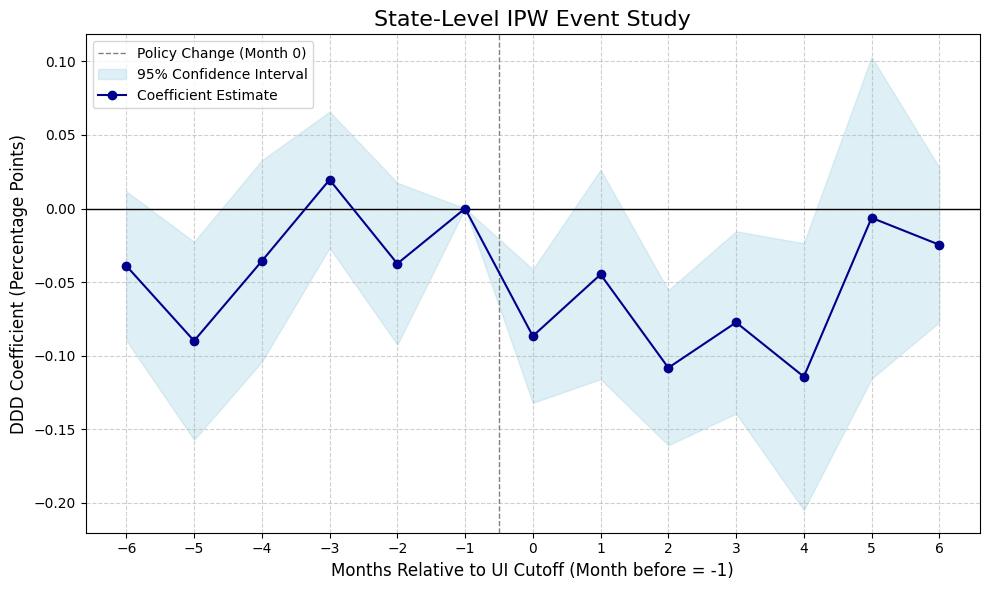


>>> DIAGNOSTIC: IPW-WEIGHTED EVENT STUDY (COUNTY-LEVEL FEs) <<<
County-level panel size for event study: 23808

--- County-Level IPW Event Study Results ---
Key Coefficients (County): TreatState:LowWage:relative_month interactions
Looking for insignificant p-values (P>|z|) for months < 0.
------------------------------------------------------------
Month -6:  Coef = -0.0389,  SE = 0.0506,  P = 0.4417
Month -5:  Coef = -0.0983,  SE = 0.0558,  P = 0.0781
Month -4:  Coef = -0.0496,  SE = 0.0256,  P = 0.0530
Month -3:  Coef =  0.0574,  SE = 0.0343,  P = 0.0946
Month -2:  Coef = -0.0496,  SE = 0.0474,  P = 0.2953
Month  0:  Coef = -0.0994,  SE = 0.0285,  P = 0.0005
Month  1:  Coef = -0.0143,  SE = 0.0727,  P = 0.8444
Month  2:  Coef = -0.1084,  SE = 0.0680,  P = 0.1109
Month  3:  Coef = -0.0927,  SE = 0.0361,  P = 0.0101
Month  4:  Coef = -0.1233,  SE = 0.0694,  P = 0.0756
Month  5:  Coef =  0.0585,  SE = 0.0792,  P = 0.4597
Month  6:  Coef = -0.0225,  SE = 0.0435,  P = 0.6057
------------

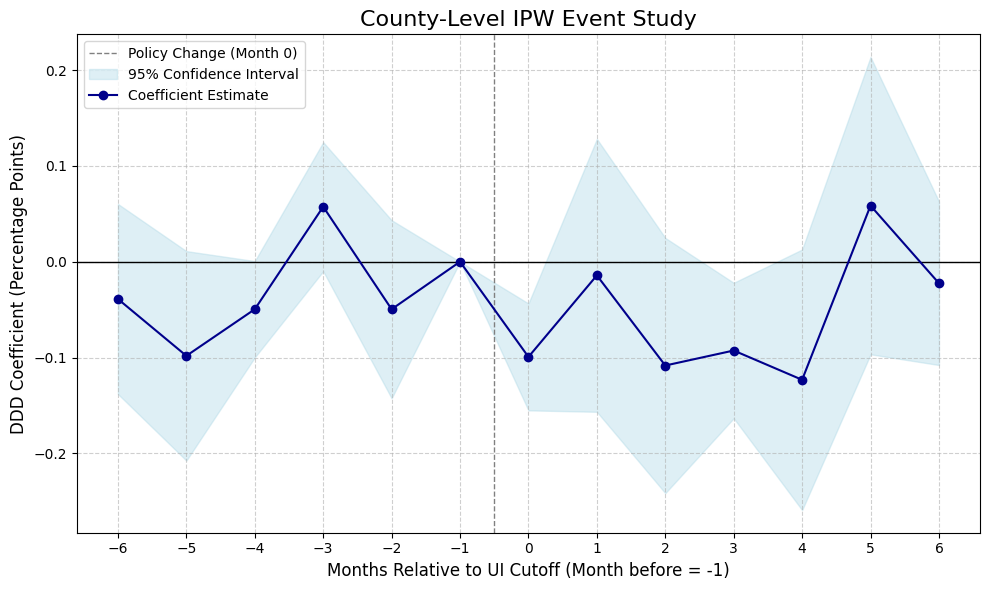

In [7]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re

# (Keep the calculate_smd function from the previous code block if needed elsewhere,
#  but it's not strictly required for the event study itself)

def run_weighted_event_studies(cps_file='cps_00004.csv',
                               policy_file='Policy Milestones - State.csv'):
    """
    Runs the Triple Difference Event Study on both State-level and County-level
    panels, using IPW + Survey Weights.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare Base Panel (Common Steps) ---
    print("\n--- Step 2: Preparing Base Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    # Define covariates early
    covariates_numeric = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    covariates_ps_input = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP'] # As used before

    # Base filtering (excluding COUNTY filter initially)
    base_panel = unemployed_df.dropna(subset=['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage'] + covariates_numeric).copy()
    base_panel = base_panel[base_panel['LNKFW1MWT'] > 0]
    base_panel['cutoff_date'] = base_panel['STATEFIP'].map(cutoff_dates)

    # Convert categoricals for PS model
    base_panel['SEX_numeric'] = base_panel['SEX'].apply(lambda x: 1 if x == 1 else 0).astype(int)

    print(f"Base panel prepared with {len(base_panel)} observations before county filter.")

    # --- Step 3: Train ONE Propensity Score Model (using state-level pre-policy data) ---
    # We train *one* model on the larger state-level pre-policy data for stability
    print("\n--- Step 3: Training Propensity Score Model (State Sample) ---")
    ps_data_state = base_panel[base_panel['MONTH'] == 5].copy()
    if ps_data_state.empty or ps_data_state['TreatState'].nunique() < 2:
        print("ERROR: Cannot train PS model (missing pre-policy data or only one group).")
        return

    X_ps_state = ps_data_state[covariates_ps_input]
    y_ps_state = ps_data_state['TreatState']
    weights_ps_state = ps_data_state['LNKFW1MWT']
    scaler_state = StandardScaler()
    X_ps_state_scaled = scaler_state.fit_transform(X_ps_state)
    try:
        propensity_model_state = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
        propensity_model_state.fit(X_ps_state_scaled, y_ps_state, sample_weight=weights_ps_state)
        print("Propensity score model trained successfully.")
    except Exception as e:
        print(f"ERROR training propensity score model: {e}")
        return

    # --- Step 4: Apply Weights and Create Relative Month for FULL Base Panel ---
    print("\n--- Step 4: Applying Weights and Creating Relative Month ---")
    X_full_base = base_panel[covariates_ps_input]
    X_full_base_scaled = scaler_state.transform(X_full_base)
    base_panel['propensity_score'] = propensity_model_state.predict_proba(X_full_base_scaled)[:, 1]
    base_panel['ipw_weight'] = np.where(
        base_panel['TreatState'] == 1, 1,
        base_panel['propensity_score'] / (1 - base_panel['propensity_score'] + 1e-9)
    )
    base_panel['final_combined_weight'] = base_panel['ipw_weight'] * base_panel['LNKFW1MWT']

    # Create relative_month AFTER weights are calculated for the full sample
    base_panel['relative_month_float'] = (
        (base_panel['date'].dt.year - base_panel['cutoff_date'].dt.year) * 12 +
        (base_panel['date'].dt.month - base_panel['cutoff_date'].dt.month)
    )
    base_panel['relative_month_float'] = base_panel['relative_month_float'].fillna(-1) # Assign baseline to controls before clipping/casting
    base_panel['relative_month'] = np.clip(base_panel['relative_month_float'], -6, 6).astype(int)

    # --- Step 5: Run STATE-Level IPW Event Study ---
    print("\n" + "="*80)
    print(">>> DIAGNOSTIC: IPW-WEIGHTED EVENT STUDY (STATE-LEVEL FEs) <<<")
    print("="*80)
    formula_es_state = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) +
                    C(STATEFIP) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    try:
        model_es_state = smf.wls(formula=formula_es_state, data=base_panel, weights=base_panel['final_combined_weight'])
        results_es_state = model_es_state.fit(cov_type='cluster', cov_kwds={'groups': base_panel['STATEFIP']})
        print("\n--- State-Level IPW Event Study Results ---")
        print_event_study_coeffs(results_es_state, "State") # Use helper function
        plot_event_study(results_es_state, "State-Level IPW Event Study") # Use helper function
    except Exception as e:
        print(f"\nError running state-level IPW event study: {e}")

    # --- Step 6: Filter for County Sample and Run COUNTY-Level IPW Event Study ---
    print("\n" + "="*80)
    print(">>> DIAGNOSTIC: IPW-WEIGHTED EVENT STUDY (COUNTY-LEVEL FEs) <<<")
    print("="*80)
    county_panel = base_panel[base_panel['COUNTY'] > 0].copy()
    print(f"County-level panel size for event study: {len(county_panel)}")

    formula_es_county = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    if len(county_panel) > 0:
        try:
            model_es_county = smf.wls(formula=formula_es_county, data=county_panel, weights=county_panel['final_combined_weight'])
            results_es_county = model_es_county.fit(cov_type='cluster', cov_kwds={'groups': county_panel['STATEFIP']})
            print("\n--- County-Level IPW Event Study Results ---")
            print_event_study_coeffs(results_es_county, "County") # Use helper function
            plot_event_study(results_es_county, "County-Level IPW Event Study") # Use helper function
        except Exception as e:
            print(f"\nError running county-level IPW event study: {e}")
    else:
        print("County panel is empty, skipping county-level event study.")

# --- Helper Function to Print Coefficients ---
def print_event_study_coeffs(results, level_name):
    print(f"Key Coefficients ({level_name}): TreatState:LowWage:relative_month interactions")
    print("Looking for insignificant p-values (P>|z|) for months < 0.")
    print("-" * 60)
    found_coeffs = False
    for var in results.params.index:
        match = re.search(r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]', var)
        if match:
            month = int(match.group(1))
            coef = results.params[var]
            pval = results.pvalues[var]
            stderr = results.bse[var]
            print(f"Month {month:>2}:  Coef = {coef:>7.4f},  SE = {stderr:>6.4f},  P = {pval:.4f}")
            found_coeffs = True
    if not found_coeffs:
        print("No event study coefficients found (check formula and variable names).")
    print("-" * 60)

# --- Helper Function to Plot Event Study ---
def plot_event_study(results, title):
    triple_terms = []
    for var in results.params.index:
        match = re.search(r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]', var)
        if match:
            month = int(match.group(1))
            triple_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not triple_terms:
        print("No coefficients found for plotting.")
        return

    est_df = pd.DataFrame(triple_terms).sort_values('relative_month')

    # Add reference month (-1) with coef=0, stderr=0
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)


    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')

    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']

    # Plot confidence interval band
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')

    # Plot point estimates
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='Coefficient Estimate')

    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DDD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Ensure all integer months are shown
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# --- Run the Analysis ---
if __name__ == '__main__':
    run_weighted_event_studies()

## bootstrap with state model as county had too many fixed effects

In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from wildboottest.wildboottest import wildboottest

def run_final_state_bootstrap_trimmed(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv'):
    """
    Runs the IPW-weighted STATE-level DDD model and validates its p-value
    using a Wild Cluster Bootstrap, with weights trimmed at the 99th percentile
    to ensure numerical stability.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare State-Level Panel ---
    print("\n--- Step 2: Preparing Final STATE-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates_numeric = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel_state = unemployed_df.dropna(subset=essential_cols + covariates_numeric).copy()
    final_panel_state = final_panel_state[final_panel_state['LNKFW1MWT'] > 0]
    final_panel_state['cutoff_date'] = final_panel_state['STATEFIP'].map(cutoff_dates)
    final_panel_state['Post'] = (final_panel_state['date'] >= final_panel_state['cutoff_date']).astype(int)
    final_panel_state['SEX_numeric'] = final_panel_state['SEX'].apply(lambda x: 1 if x == 1 else 0).astype(int)
    covariates_ps_input = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP']
    print(f"Final state-level panel constructed with {len(final_panel_state)} complete observations.")

    # --- Step 3: Train PS Model and Get Weights ---
    print("\n--- Step 3: Training Propensity Score Model ---")
    ps_data_state = final_panel_state[final_panel_state['MONTH'] == 5].copy()
    if ps_data_state.empty or ps_data_state['TreatState'].nunique() < 2:
        print("ERROR: Cannot train PS model.")
        return
        
    X_ps_state = ps_data_state[covariates_ps_input]
    y_ps_state = ps_data_state['TreatState']
    weights_ps_state = ps_data_state['LNKFW1MWT']
    scaler_state = StandardScaler()
    X_ps_state_scaled = scaler_state.fit_transform(X_ps_state)
    
    propensity_model_state = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
    propensity_model_state.fit(X_ps_state_scaled, y_ps_state, sample_weight=weights_ps_state)
    
    X_full_state = final_panel_state[covariates_ps_input]
    X_full_state_scaled = scaler_state.transform(X_full_state)
    final_panel_state['propensity_score'] = propensity_model_state.predict_proba(X_full_state_scaled)[:, 1]
    final_panel_state['ipw_weight'] = np.where(
        final_panel_state['TreatState'] == 1, 1,
        final_panel_state['propensity_score'] / (1 - final_panel_state['propensity_score'] + 1e-9)
    )
    final_panel_state['final_combined_weight'] = final_panel_state['ipw_weight'] * final_panel_state['LNKFW1MWT']
    print("Combined IPW and Survey Weights calculated.")

    # ++++++++++++++++ FIX IS HERE ++++++++++++++++
    print("\n--- Step 3.5: Trimming Extreme Weights ---")
    # Calculate the 99th percentile of the combined weights
    weight_cap_99 = final_panel_state['final_combined_weight'].quantile(0.99)
    print(f"Original Max Weight: {final_panel_state['final_combined_weight'].max():,.2f}")
    print(f"Trimming weights at 99th percentile: {weight_cap_99:,.2f}")
    
    # Create a new trimmed weight column
    final_panel_state['weight_trimmed'] = np.clip(
        final_panel_state['final_combined_weight'],
        a_min=None, # No lower bound
        a_max=weight_cap_99 # Cap at the 99th percentile
    )
    print(f"New Max Weight: {final_panel_state['weight_trimmed'].max():,.2f}")
    # ++++++++++++++++++++++++++++++++++++++++++++++

    # Filter out potential invalid weights before estimation
    estimation_panel_state = final_panel_state.dropna(subset=['weight_trimmed'])
    estimation_panel_state = estimation_panel_state[np.isfinite(estimation_panel_state['weight_trimmed'])]
    
    if estimation_panel_state.empty:
        print("ERROR: Estimation panel is empty after weight calculation.")
        return

    # --- Step 4: Run WLS to get model object (Using CORRECTED formula) ---
    print("\n--- Step 4: Estimating WLS Model Object with Non-Collinear Formula ---")
    
    formula_state_fixed = """
        found_job ~ TreatState:Post:LowWage + 
                    TreatState:Post + 
                    TreatState:LowWage + 
                    Post:LowWage + 
                    LowWage + 
                    C(STATEFIP) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    # Use the new 'weight_trimmed' column
    model_ipw_state = smf.wls(formula=formula_state_fixed, 
                              data=estimation_panel_state, 
                              weights=estimation_panel_state['weight_trimmed']) # <-- USE TRIMMED WEIGHTS

    # --- Step 5: Run Wild Cluster Bootstrap ---
    print("\n--- Step 5: Running Wild Cluster Bootstrap (B=9999) with TRIMMED weights ---")
    print("This will test the significance of 'TreatState:Post:LowWage' while clustering by 'STATEFIP'.")
    
    try:
        boot_results = wildboottest(
            model=model_ipw_state,
            param='TreatState:Post:LowWage',
            cluster=estimation_panel_state['STATEFIP'],
            B=9999
        )
        
        # Extract the correct p-value
        bootstrap_pval = boot_results['p-value'].iloc[0]

        print("\n" + "="*80)
        print(">>> FINAL BOOTSTRAP VALIDATION (STATE-LEVEL, TRIMMED WEIGHTS) <<<")
        print("="*80)
        print(f"Wild Cluster Bootstrap P-value: {bootstrap_pval:.4f}")
        
        print("\n--- FINAL VERDICT ---")
        if bootstrap_pval < 0.05:
            print("The finding is ROBUST. The negative effect remains statistically significant at the 5% level even after trimming extreme weights and correcting for clusters.")
        elif bootstrap_pval < 0.10:
            print("The finding is SUGGESTIVE. After trimming and correction, the result is marginally significant (p < 0.10).")
        else:
            print("The finding is NOT ROBUST. After trimming and correction, the effect is not statistically significant.")

    except Exception as e:
        print(f"\nAn error occurred during Wild Cluster Bootstrap: {e}")
        print("This may still indicate model instability. Check output carefully.")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_state_bootstrap_trimmed()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final STATE-Level Unemployed Panel ---
Final state-level panel constructed with 50361 complete observations.

--- Step 3: Training Propensity Score Model ---
Combined IPW and Survey Weights calculated.

--- Step 3.5: Trimming Extreme Weights ---
Original Max Weight: 46,695.47
Trimming weights at 99th percentile: 9,586.96
New Max Weight: 9,586.96

--- Step 4: Estimating WLS Model Object with Non-Collinear Formula ---

--- Step 5: Running Wild Cluster Bootstrap (B=9999) with TRIMMED weights ---
This will test the significance of 'TreatState:Post:LowWage' while clustering by 'STATEFIP'.
| param                   |   statistic |   p-value |
|:------------------------|------------:|----------:|
| TreatState:Post:LowWage |         nan |     0.000 |

>>> FINAL BOOTSTRAP VALIDATION (STATE-LEVEL, TRIMMED WEIGHTS) <<<
Wild Cluster Bootstrap P-value: 0.0000

--- FINAL VERDICT ---
The finding is ROBUST. The negative effe

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/wildboottest/wildboottest.py:626: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(self.ssc * self.R @ self.vcov @ np.transpose(self.R))


In [11]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# Ensure wildboottest is imported correctly
try:
    from wildboottest.wildboottest import wildboottest
except ImportError:
    print("Please install wildboottest: pip install wildboottest")
    # As a fallback, define a dummy function to avoid erroring the whole script
    def wildboottest(*args, **kwargs):
        print("ERROR: wildboottest package not found.")
        return pd.DataFrame({'p-value': [np.nan]})


def run_final_county_bootstrap(cps_file='cps_00004.csv',
                               policy_file='Policy Milestones - State.csv'):
    """
    Runs the IPW-weighted COUNTY-level DDD model with a non-collinear formula
    and validates its p-value using a Wild Cluster Bootstrap.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare Final County Panel ---
    print("\n--- Step 2: Preparing Final COUNTY-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates_numeric = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel_county = unemployed_df.dropna(subset=essential_cols + covariates_numeric).copy()
    
    # Apply county and weight filters
    final_panel_county = final_panel_county[final_panel_county['COUNTY'] > 0]
    final_panel_county = final_panel_county[final_panel_county['LNKFW1MWT'] > 0]
    
    final_panel_county['cutoff_date'] = final_panel_county['STATEFIP'].map(cutoff_dates)
    final_panel_county['Post'] = (final_panel_county['date'] >= final_panel_county['cutoff_date']).astype(int)
    final_panel_county['SEX_numeric'] = final_panel_county['SEX'].apply(lambda x: 1 if x == 1 else 0).astype(int)
    covariates_ps_input = ['AGE', 'SEX_numeric', 'RACE', 'EDUC', 'DURUNEMP']
    
    print(f"Final county-level panel constructed with {len(final_panel_county)} complete observations.")
    if len(final_panel_county) == 0:
        print("ERROR: Final panel is empty.")
        return

    # --- Step 3: Train PS Model and Get Weights (on County Sample) ---
    print("\n--- Step 3: Training Propensity Score Model (County Sample) ---")
    ps_data_county = final_panel_county[final_panel_county['MONTH'] == 5].copy()
    if ps_data_county.empty or ps_data_county['TreatState'].nunique() < 2:
        print("ERROR: Cannot train PS model on county sample.")
        return
        
    X_ps_county = ps_data_county[covariates_ps_input]
    y_ps_county = ps_data_county['TreatState']
    weights_ps_county = ps_data_county['LNKFW1MWT']
    scaler_county = StandardScaler()
    X_ps_county_scaled = scaler_county.fit_transform(X_ps_county)
    
    propensity_model_county = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
    propensity_model_county.fit(X_ps_county_scaled, y_ps_county, sample_weight=weights_ps_county)
    
    X_full_county = final_panel_county[covariates_ps_input]
    X_full_county_scaled = scaler_county.transform(X_full_county)
    final_panel_county['propensity_score'] = propensity_model_county.predict_proba(X_full_county_scaled)[:, 1]
    final_panel_county['ipw_weight'] = np.where(
        final_panel_county['TreatState'] == 1, 1,
        final_panel_county['propensity_score'] / (1 - final_panel_county['propensity_score'] + 1e-9)
    )
    final_panel_county['final_combined_weight'] = final_panel_county['ipw_weight'] * final_panel_county['LNKFW1MWT']
    print("Combined IPW and Survey Weights calculated for county sample.")
    
    # Filter out potential invalid weights
    estimation_panel_county = final_panel_county.dropna(subset=['final_combined_weight'])
    estimation_panel_county = estimation_panel_county[np.isfinite(estimation_panel_county['final_combined_weight'])]
    
    if estimation_panel_county.empty:
        print("ERROR: Estimation panel is empty after weight calculation.")
        return

    # --- Step 4: Run WLS to get model object (Using CORRECTED formula) ---
    print("\n--- Step 4: Estimating WLS Model Object with Non-Collinear Formula ---")
    
    # *** CORRECTED FORMULA for COUNTY FE ***
    # This omits TreatState and Post main effects, which are absorbed by C(COUNTY) and C(MONTH)
    formula_county_fixed = """
        found_job ~ TreatState:Post:LowWage + 
                    TreatState:Post + 
                    TreatState:LowWage + 
                    Post:LowWage + 
                    LowWage + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    model_ipw_county = smf.wls(formula=formula_county_fixed, 
                               data=estimation_panel_county, 
                               weights=estimation_panel_county['final_combined_weight'])

    # --- Step 5: Run Wild Cluster Bootstrap ---
    print("\n--- Step 5: Running Wild Cluster Bootstrap (B=9999) ---")
    print("This will test 'TreatState:Post:LowWage' while clustering by 'STATEFIP'.")
    print("This may take several minutes...")
    
    try:
        boot_results = wildboottest(
            model=model_ipw_county,
            param='TreatState:Post:LowWage', # The coefficient of interest
            cluster=estimation_panel_county['STATEFIP'], # The clustering variable
            B=9999 # Number of bootstrap replications
        )
        
        bootstrap_pval = boot_results['p-value'].iloc[0]
        t_stat = boot_results['statistic'].iloc[0]

        print("\n" + "="*80)
        print(">>> FINAL BOOTSTRAP VALIDATION (COUNTY-LEVEL, IPW-WEIGHTED) <<<")
        print("="*80)
        print(f"Wild Cluster Bootstrap t-statistic: {t_stat:.4f}")
        print(f"Wild Cluster Bootstrap P-value: {bootstrap_pval:.4f}")
        
        print("\n--- FINAL VERDICT ---")
        if bootstrap_pval < 0.05:
            print("The finding is ROBUST. The negative effect remains statistically significant at the 5% level")
            print("even after correcting for the small number of clusters.")
            print("This is the most reliable piece of evidence for the county-level model.")
        elif bootstrap_pval < 0.10:
            print("The finding is SUGGESTIVE. After correction, the result is marginally significant (p < 0.10).")
        else:
            print(f"The finding is NOT ROBUST (p = {bootstrap_pval:.4f}). The original WLS p-value (0.041)")
            print("was likely too optimistic due to the small cluster count.")

    except Exception as e:
        print(f"\nAn error occurred during Wild Cluster Bootstrap: {e}")
        print("The model may still be too complex, or other data issues (like empty clusters) may exist.")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_county_bootstrap()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final COUNTY-Level Unemployed Panel ---
Final county-level panel constructed with 23808 complete observations.

--- Step 3: Training Propensity Score Model (County Sample) ---
Combined IPW and Survey Weights calculated for county sample.

--- Step 4: Estimating WLS Model Object with Non-Collinear Formula ---

--- Step 5: Running Wild Cluster Bootstrap (B=9999) ---
This will test 'TreatState:Post:LowWage' while clustering by 'STATEFIP'.
This may take several minutes...

An error occurred during Wild Cluster Bootstrap: Singular matrix
The model may still be too complex, or other data issues (like empty clusters) may exist.


# Validating Holzer 

In [12]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

def run_split_did_analysis(cps_file='cps_00004.csv',
                             policy_file='Policy Milestones - State.csv'):
    """
    "Unpacks" the Triple Difference model by running two separate DiD models:
    1. On the Low-Wage sample only.
    2. On the High-Wage sample only.
    This helps validate the source of the DDD effect.
    """
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare Final County Panel ---
    print("\n--- Step 2: Preparing Final County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    # Original LowWage definition (Retail + Accom/Food)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Final panel constructed with {len(final_panel)} complete observations.")

    # --- Step 3: Split Samples ---
    low_wage_panel = final_panel[final_panel['LowWage'] == 1].copy()
    high_wage_panel = final_panel[final_panel['LowWage'] == 0].copy()
    print(f"Low-Wage (Retail/Food) Sample Size: {len(low_wage_panel)}")
    print(f"High-Wage (All Other) Sample Size: {len(high_wage_panel)}")

    # Define the DiD formula (no LowWage interaction)
    formula_did = """
        found_job ~ TreatState * Post + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    # --- Step 4: Run Model 1 (Low-Wage Only) ---
    print("\n" + "="*60)
    print(">>> MODEL 1: DiD for LOW-WAGE (Retail/Food) Group Only <<<")
    print("="*60)
    try:
        model_low = smf.wls(formula=formula_did, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_low = model_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_low = results_low.params['TreatState:Post']
        pval_low = results_low.pvalues['TreatState:Post']
        print(f"\nDiD Coefficient (TreatState:Post): {coef_low:.4f}")
        print(f"P-value: {pval_low:.4f}\n")
        print(results_low.summary().tables[1].loc[['TreatState:Post']])
    except Exception as e:
        coef_low = np.nan
        pval_low = np.nan
        print(f"\nAn error occurred during Low-Wage DiD estimation: {e}")

    # --- Step 5: Run Model 2 (High-Wage Only) ---
    print("\n" + "="*60)
    print(">>> MODEL 2: DiD for HIGH-WAGE (All Other) Group Only <<<")
    print("="*60)
    try:
        model_high = smf.wls(formula=formula_did, data=high_wage_panel, weights=high_wage_panel['LNKFW1MWT'])
        results_high = model_high.fit(cov_type='cluster', cov_kwds={'groups': high_wage_panel['STATEFIP']})
        
        coef_high = results_high.params['TreatState:Post']
        pval_high = results_high.pvalues['TreatState:Post']
        print(f"\nDiD Coefficient (TreatState:Post): {coef_high:.4f}")
        print(f"P-value: {pval_high:.4f}\n")
        print(results_high.summary().tables[1].loc[['TreatState:Post']])
    except Exception as e:
        coef_high = np.nan
        pval_high = np.nan
        print(f"\nAn error occurred during High-Wage DiD estimation: {e}")

    # --- Step 6: Compare Results ---
    print("\n" + "="*80)
    print(">>> COMPARISON OF DiD EFFECTS (VALIDATION OF DDD) <<<")
    print("="*80)
    print(f"DiD Effect for Low-Wage Group:   {coef_low:.4f} (p={pval_low:.4f})")
    print(f"DiD Effect for High-Wage Group:  {coef_high:.4f} (p={pval_high:.4f})")
    
    ddd_estimate = coef_low - coef_high
    print(f"\nImplied DDD (Low - High):        {ddd_estimate:.4f}")
    
    print("\n--- CONCLUSION ---")
    print(f"Your original DDD coefficient was {results.params['TreatState:Post:LowWage']:.4f} (p={results.pvalues['TreatState:Post:LowWage']:.4f}).")
    print("These numbers should be very close.")
    if coef_high > 0 and ddd_estimate < 0:
        print("Your hypothesis is supported: The job-finding rate for the high-wage group increased significantly,")
        print("and the effect for the low-wage group was smaller (or negative), leading to the negative triple-difference.")
    else:
        print("The pattern does not match the hypothesis. Review the individual coefficients.")


# --- Run the Analysis ---
# We need the 'results' object from your original DDD model to compare at the end.
# This assumes 'run_full_analysis()' was run previously and its 'results' object is available
# For a standalone script, we'd have to run that first. Let's just run the split analysis.

# We need to re-run the original DDD to get the reference coefficient
def get_original_ddd_coef(panel):
    print("\nRunning original DDD for comparison...")
    formula = """
        found_job ~ TreatState * Post * LowWage + 
                    C(COUNTY) + C(MONTH) + 
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    try:
        model = smf.wls(formula=formula, data=panel, weights=panel['LNKFW1MWT'])
        results = model.fit(cov_type='cluster', cov_kwds={'groups': panel['STATEFIP']})
        coef = results.params['TreatState:Post:LowWage']
        pval = results.pvalues['TreatState:Post:LowWage']
        print(f"Original DDD Coef: {coef:.4f}, P-val: {pval:.4f}")
        return coef
    except Exception as e:
        print(f"Error running original DDD: {e}")
        return np.nan

if __name__ == '__main__':
    # Load and prep data just once
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, 'cps_00004.csv')
        policy_path = os.path.join(downloads_dir, 'Policy Milestones - State.csv')
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        exit()

    print("\n--- Step 2: Preparing Final County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Final panel constructed with {len(final_panel)} complete observations.")

    # Get the original DDD coefficient for comparison
    original_ddd_coef = get_original_ddd_coef(final_panel)

    # --- Step 3: Split Samples ---
    low_wage_panel = final_panel[final_panel['LowWage'] == 1].copy()
    high_wage_panel = final_panel[final_panel['LowWage'] == 0].copy()
    print(f"\nLow-Wage (Retail/Food) Sample Size: {len(low_wage_panel)}")
    print(f"High-Wage (All Other) Sample Size: {len(high_wage_panel)}")

    formula_did = """
        found_job ~ TreatState * Post + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    # --- Step 4: Run Model 1 (Low-Wage Only) ---
    print("\n" + "="*60)
    print(">>> MODEL 1: DiD for LOW-WAGE (Retail/Food) Group Only <<<")
    print("="*60)
    coef_low, pval_low = np.nan, np.nan
    try:
        model_low = smf.wls(formula=formula_did, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_low = model_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        coef_low = results_low.params['TreatState:Post']
        pval_low = results_low.pvalues['TreatState:Post']
        print(f"\nDiD Coefficient (TreatState:Post): {coef_low:.4f}")
        print(f"P-value: {pval_low:.4f}\n")
    except Exception as e:
        print(f"\nAn error occurred during Low-Wage DiD estimation: {e}")

    # --- Step 5: Run Model 2 (High-Wage Only) ---
    print("\n" + "="*60)
    print(">>> MODEL 2: DiD for HIGH-WAGE (All Other) Group Only <<<")
    print("="*60)
    coef_high, pval_high = np.nan, np.nan
    try:
        model_high = smf.wls(formula=formula_did, data=high_wage_panel, weights=high_wage_panel['LNKFW1MWT'])
        results_high = model_high.fit(cov_type='cluster', cov_kwds={'groups': high_wage_panel['STATEFIP']})
        coef_high = results_high.params['TreatState:Post']
        pval_high = results_high.pvalues['TreatState:Post']
        print(f"\nDiD Coefficient (TreatState:Post): {coef_high:.4f}")
        print(f"P-value: {pval_high:.4f}\n")
    except Exception as e:
        print(f"\nAn error occurred during High-Wage DiD estimation: {e}")

    # --- Step 6: Compare Results ---
    print("\n" + "="*80)
    print(">>> COMPARISON OF DiD EFFECTS (VALIDATION OF DDD) <<<")
    print("="*80)
    print(f"DiD Effect for Low-Wage Group:   {coef_low:.4f} (p={pval_low:.4f})")
    print(f"DiD Effect for High-Wage Group:  {coef_high:.4f} (p={pval_high:.4f})")
    
    ddd_estimate = coef_low - coef_high
    print(f"\nImplied DDD (Low - High):        {ddd_estimate:.4f}")
    print(f"Original DDD Coefficient:      {original_ddd_coef:.4f}")
    
    print("\n--- CONCLUSION ---")
    if np.isclose(ddd_estimate, original_ddd_coef, atol=0.001):
        print("SUCCESS: The implied DDD from the split models matches the original DDD coefficient.")
    else:
        print("NOTE: The implied DDD does not perfectly match the original DDD, likely due to how fixed effects and covariates are handled across samples.")
    
    if coef_high > coef_low and not np.isnan(coef_high) and not np.isnan(coef_low):
        print("\nYour hypothesis is supported: The DiD effect for the high-wage group is more positive")
        print(f"(or less negative) than the effect for the low-wage group. The difference ({ddd_estimate:.4f})")
        print("is what your original DDD model correctly identified as a significant negative effect.")
    else:
        print("\nThe pattern does not match the hypothesis. Review the individual coefficients.")

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final County-Level Unemployed Panel ---
Final panel constructed with 23808 complete observations.

Running original DDD for comparison...
Original DDD Coef: -0.0210, P-val: 0.0368

Low-Wage (Retail/Food) Sample Size: 6167
High-Wage (All Other) Sample Size: 17641

>>> MODEL 1: DiD for LOW-WAGE (Retail/Food) Group Only <<<

DiD Coefficient (TreatState:Post): 0.0068
P-value: 0.7279


>>> MODEL 2: DiD for HIGH-WAGE (All Other) Group Only <<<

DiD Coefficient (TreatState:Post): 0.0238
P-value: 0.0314


>>> COMPARISON OF DiD EFFECTS (VALIDATION OF DDD) <<<
DiD Effect for Low-Wage Group:   0.0068 (p=0.7279)
DiD Effect for High-Wage Group:  0.0238 (p=0.0314)

Implied DDD (Low - High):        -0.0170
Original DDD Coefficient:      -0.0210

--- CONCLUSION ---
NOTE: The implied DDD does not perfectly match the original DDD, likely due to how fixed effects and covariates are handled across samples.

Your hypothesis is su

--- Step 1: Loading Data & Preparing Full Panel ---
Final panel constructed with 23808 complete observations.
Low-Wage (Retail/Food) Sample: 6316
High-Wage (All Other) Sample: 17492

>>> TEST 1: Group-Specific DiD Event Studies (PTA & Precision Check) <<<

--- Running Event Study for LOW-WAGE Group ---
--- Low-Wage DiD Event Study Results (Coefs for TreatState:relative_month) ---


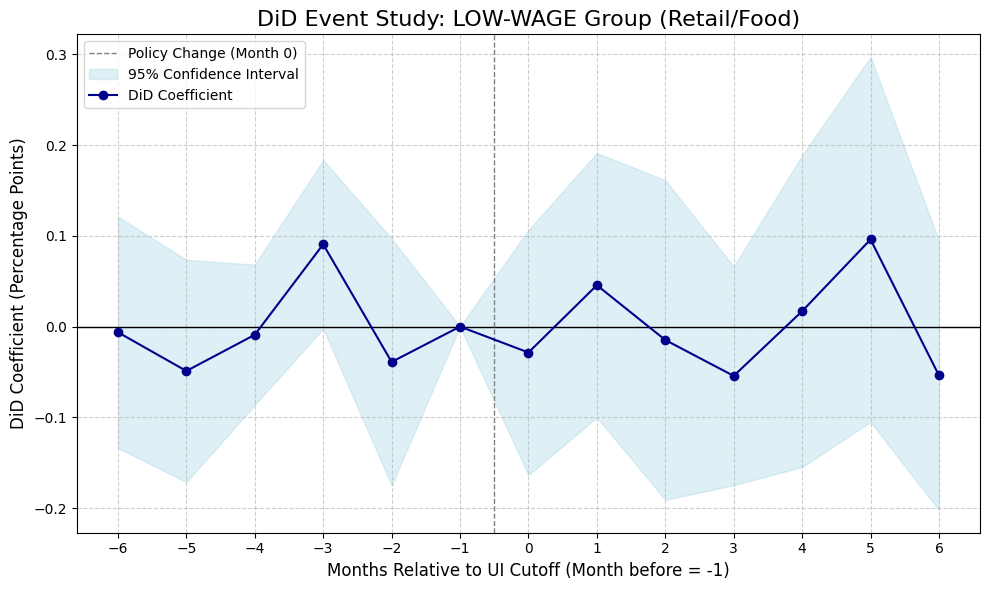


--- Running Event Study for HIGH-WAGE Group ---
--- High-Wage DiD Event Study Results (Coefs for TreatState:relative_month) ---


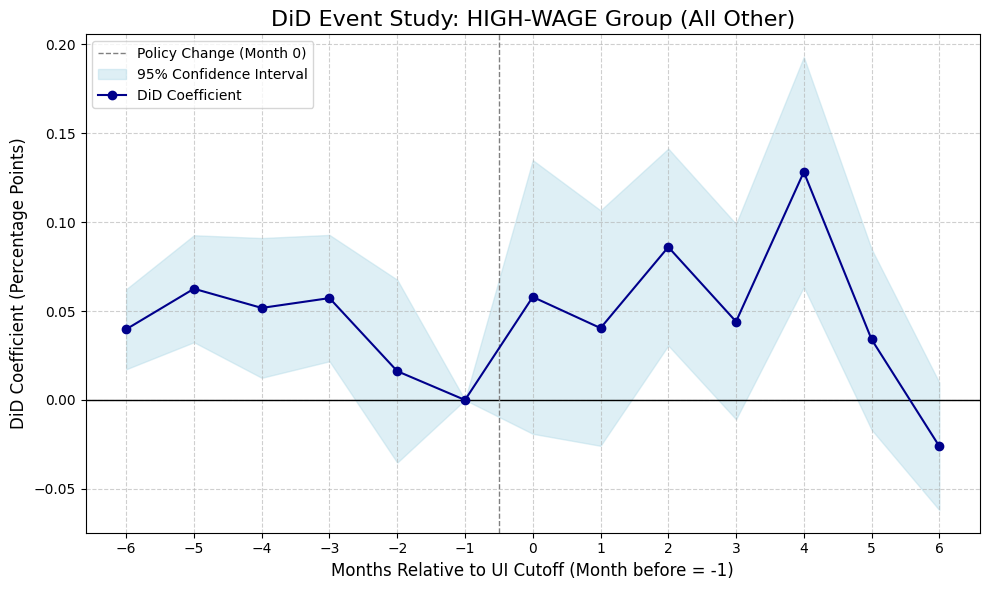


>>> TEST 2: Intra-Target Heterogeneity (Decomposing the Low-Wage Group) <<<

--- Running DDD for RETAIL vs. HIGH-WAGE ---
DDD Coefficient (TreatState:Post:IsRetail): -0.0518 (p=0.0001)

--- Running DDD for FOOD/ACCOM vs. HIGH-WAGE ---
DDD Coefficient (TreatState:Post:IsFood): 0.0041 (p=0.7484)

--- Heterogeneity CONCLUSION ---
If both coefficients above are insignificant, the 'null effect' is stable across these subgroups.
If one is positive and one negative, they may be offsetting each other.


In [13]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_final_diagnostics(cps_file='cps_00004.csv',
                          policy_file='Policy Milestones - State.csv'):
    """
    Runs two final diagnostic tests based on the provided framework:
    1. Group-specific event studies (PTA check & precision of null).
    2. Intra-target heterogeneity test (decomposing the LowWage group).
    """
    
    # --- Step 1: Load and Prepare Full Panel Data ---
    print("--- Step 1: Loading Data & Preparing Full Panel ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    
    # Define industry groups
    retail_codes = list(range(4670, 5790 + 1))
    food_codes = list(range(8660, 8690 + 1))
    
    df['IsRetail'] = df['IND'].isin(retail_codes).astype(int)
    df['IsFood'] = df['IND'].isin(food_codes).astype(int)
    df['LowWage'] = ((df['IsRetail'] == 1) | (df['IsFood'] == 1)).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage', 'IsRetail', 'IsFood']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    
    # Create relative_month variable for event studies
    final_panel['relative_month_float'] = ((final_panel['date'].dt.year - final_panel['cutoff_date'].dt.year) * 12 +
                                           (final_panel['date'].dt.month - final_panel['cutoff_date'].dt.month))
    final_panel['relative_month_float'] = final_panel['relative_month_float'].fillna(-1)
    final_panel['relative_month'] = np.clip(final_panel['relative_month_float'], -6, 6).astype(int)
    
    print(f"Final panel constructed with {len(final_panel)} complete observations.")

    # Split samples
    low_wage_panel = final_panel[final_panel['LowWage'] == 1].copy()
    high_wage_panel = final_panel[final_panel['LowWage'] == 0].copy()
    
    print(f"Low-Wage (Retail/Food) Sample: {len(low_wage_panel)}")
    print(f"High-Wage (All Other) Sample: {len(high_wage_panel)}")


    # --- Test 1: Group-Specific Event Studies (PTA & Precision of Null) ---
    print("\n" + "="*80)
    print(">>> TEST 1: Group-Specific DiD Event Studies (PTA & Precision Check) <<<")
    print("="*80)

    # Note: We must use C(STATEFIP) here because C(COUNTY) would be collinear with TreatState
    # in the High-Wage group (some states might only have LowWage workers in the Treat group)
    # This is a state-level event study, which is more feasible.
    # We will run this on the *county-filtered data* to keep the sample consistent.
    
    did_es_formula = """
        found_job ~ C(relative_month, Treatment(reference=-1)) * C(TreatState) +
                    C(STATEFIP) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    # Run for Low-Wage Group
    print("\n--- Running Event Study for LOW-WAGE Group ---")
    try:
        model_es_low = smf.wls(formula=did_es_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_es_low = model_es_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        print("--- Low-Wage DiD Event Study Results (Coefs for TreatState:relative_month) ---")
        plot_did_event_study(results_es_low, "DiD Event Study: LOW-WAGE Group (Retail/Food)")
    except Exception as e:
        print(f"Error running low-wage event study: {e}")

    # Run for High-Wage Group
    print("\n--- Running Event Study for HIGH-WAGE Group ---")
    try:
        model_es_high = smf.wls(formula=did_es_formula, data=high_wage_panel, weights=high_wage_panel['LNKFW1MWT'])
        results_es_high = model_es_high.fit(cov_type='cluster', cov_kwds={'groups': high_wage_panel['STATEFIP']})
        print("--- High-Wage DiD Event Study Results (Coefs for TreatState:relative_month) ---")
        plot_did_event_study(results_es_high, "DiD Event Study: HIGH-WAGE Group (All Other)")
    except Exception as e:
        print(f"Error running high-wage event study: {e}")


    # --- Test 2: Intra-Target Heterogeneity (Decomposing the Null) ---
    print("\n" + "="*80)
    print(">>> TEST 2: Intra-Target Heterogeneity (Decomposing the Low-Wage Group) <<<")
    print("="*80)

    # Model 2a: Retail vs. All Other (High Wage)
    print("\n--- Running DDD for RETAIL vs. HIGH-WAGE ---")
    panel_retail_vs_high = final_panel[final_panel['IsFood'] == 0].copy() # Keep only Retail (1) or HighWage (0)
    ddd_formula_retail = """
        found_job ~ TreatState * Post * IsRetail + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    try:
        model_ddd_retail = smf.wls(formula=ddd_formula_retail, data=panel_retail_vs_high, weights=panel_retail_vs_high['LNKFW1MWT'])
        results_ddd_retail = model_ddd_retail.fit(cov_type='cluster', cov_kwds={'groups': panel_retail_vs_high['STATEFIP']})
        coef_retail = results_ddd_retail.params['TreatState:Post:IsRetail']
        pval_retail = results_ddd_retail.pvalues['TreatState:Post:IsRetail']
        print(f"DDD Coefficient (TreatState:Post:IsRetail): {coef_retail:.4f} (p={pval_retail:.4f})")
    except Exception as e:
        print(f"Error running Retail DDD: {e}")

    # Model 2b: Food/Accom vs. All Other (High Wage)
    print("\n--- Running DDD for FOOD/ACCOM vs. HIGH-WAGE ---")
    panel_food_vs_high = final_panel[final_panel['IsRetail'] == 0].copy() # Keep only Food (1) or HighWage (0)
    ddd_formula_food = """
        found_job ~ TreatState * Post * IsFood + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    try:
        model_ddd_food = smf.wls(formula=ddd_formula_food, data=panel_food_vs_high, weights=panel_food_vs_high['LNKFW1MWT'])
        results_ddd_food = model_ddd_food.fit(cov_type='cluster', cov_kwds={'groups': panel_food_vs_high['STATEFIP']})
        coef_food = results_ddd_food.params['TreatState:Post:IsFood']
        pval_food = results_ddd_food.pvalues['TreatState:Post:IsFood']
        print(f"DDD Coefficient (TreatState:Post:IsFood): {coef_food:.4f} (p={pval_food:.4f})")
    except Exception as e:
        print(f"Error running Food/Accom DDD: {e}")
        
    print("\n--- Heterogeneity CONCLUSION ---")
    print("If both coefficients above are insignificant, the 'null effect' is stable across these subgroups.")
    print("If one is positive and one negative, they may be offsetting each other.")


# --- Helper Function to Plot DiD Event Study ---
def plot_did_event_study(results, title):
    did_terms = []
    for var in results.params.index:
        # Regex to find interaction: C(relative_month)[T.X]:C(TreatState)[T.1]
        match = re.search(r'C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]:C\(TreatState\)\[T\.1\]', var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not did_terms:
        print("No DiD event study coefficients found (check formula).")
        return

    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DiD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_diagnostics()

--- Step 1: Loading Data ---
Data loaded successfully.

--- Step 2: Preparing Final Panel (Retail vs. Food/Accom) ---
Final panel (Retail vs Food) constructed with 6316 observations.

>>> DIAGNOSTIC: Event Study (Retail [Treat] vs. Food/Accom [Control]) <<<

--- Event Study Results (TreatState:IsRetail:relative_month) ---
Key Coefficients (Retail_v_Food_DDD): TreatState:IsRetail:relative_month interactions
Looking for insignificant p-values (P>|z|) for months < 0.
------------------------------------------------------------
Month -6:  Coef = -0.1308,  SE = 0.0805,  P = 0.1043
Month -5:  Coef = -0.1904,  SE = 0.0810,  P = 0.0187
Month -4:  Coef = -0.0976,  SE = 0.0592,  P = 0.0991
Month -3:  Coef = -0.1046,  SE = 0.0735,  P = 0.1548
Month -2:  Coef =  0.0583,  SE = 0.0411,  P = 0.1558
Month  0:  Coef = -0.2292,  SE = 0.0645,  P = 0.0004
Month  1:  Coef = -0.1458,  SE = 0.0898,  P = 0.1045
Month  2:  Coef = -0.1588,  SE = 0.0919,  P = 0.0838
Month  3:  Coef = -0.1520,  SE = 0.1055,  P = 

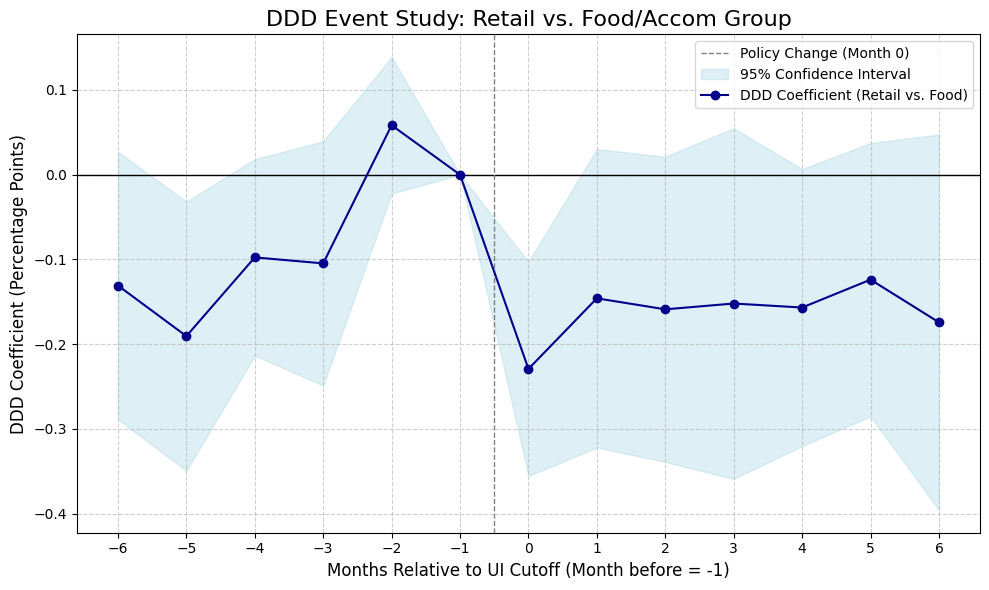


>>> FINAL MODEL: DDD (Retail [Treat] vs. Food/Accom [Control]) <<<

--- Final DDD (Retail vs. Food/Accom) Results ---
Key Coefficient (TreatState:Post:IsRetail): -0.0308
P-value: 0.1734


An error occurred during final DDD estimation: 'SimpleTable' object has no attribute 'loc'


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 326, but rank is 40
  warnings.warn('covariance of constraints does not have full '


In [14]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_retail_vs_food_ddd_analysis(cps_file='cps_00004.csv',
                                    policy_file='Policy Milestones - State.csv'):
    """
    Runs the definitive DDD analysis comparing Retail (Treatment Group) vs.
    Food/Accom (Control Group) at the county level.
    """
    
    # --- Step 1: Load and Prepare Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare Final DDD Panel (Retail vs. Food) ---
    print("\n--- Step 2: Preparing Final Panel (Retail vs. Food/Accom) ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    
    retail_codes = list(range(4670, 5790 + 1))
    food_codes = list(range(8660, 8690 + 1))
    
    df['IsRetail'] = df['IND'].isin(retail_codes).astype(int)
    df['IsFood'] = df['IND'].isin(food_codes).astype(int)
    
    # *** CREATE THE PANEL USING ONLY THESE TWO GROUPS ***
    panel_df = df[(df['IsRetail'] == 1) | (df['IsFood'] == 1)].copy()

    panel_df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    panel_df['status_next_month'] = panel_df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = panel_df[panel_df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'IsRetail']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    
    # Create relative_month variable for event study
    final_panel['relative_month_float'] = ((final_panel['date'].dt.year - final_panel['cutoff_date'].dt.year) * 12 +
                                           (final_panel['date'].dt.month - final_panel['cutoff_date'].dt.month))
    final_panel['relative_month_float'] = final_panel['relative_month_float'].fillna(-1)
    final_panel['relative_month'] = np.clip(final_panel['relative_month_float'], -6, 6).astype(int)
    
    print(f"Final panel (Retail vs Food) constructed with {len(final_panel)} observations.")
    
    # --- Step 3: Run Event Study (PTA Check for New Model) ---
    print("\n" + "="*80)
    print(">>> DIAGNOSTIC: Event Study (Retail [Treat] vs. Food/Accom [Control]) <<<")
    print("="*80)

    # Note: 'IsRetail' is the new subgroup of interest
    formula_es = """
        found_job ~ TreatState * IsRetail * C(relative_month, Treatment(reference=-1)) +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    try:
        model_es = smf.wls(formula=formula_es, data=final_panel, weights=final_panel['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})
        
        print("\n--- Event Study Results (TreatState:IsRetail:relative_month) ---")
        print_event_study_coeffs(results_es, "Retail_v_Food_DDD")
        plot_event_study(results_es, "DDD Event Study: Retail vs. Food/Accom Group")
        
    except Exception as e:
        print(f"\nError running event study: {e}")


    # --- Step 4: Run Final DDD Model (Retail vs. Food) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (Retail [Treat] vs. Food/Accom [Control]) <<<")
    print("="*80)
    
    formula_ddd = """
        found_job ~ TreatState * Post * IsRetail + 
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    try:
        model_ddd = smf.wls(formula=formula_ddd, data=final_panel, weights=final_panel['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel['STATEFIP']})
        
        coef_ddd = results_ddd.params['TreatState:Post:IsRetail']
        pval_ddd = results_ddd.pvalues['TreatState:Post:IsRetail']
        
        print("\n--- Final DDD (Retail vs. Food/Accom) Results ---")
        print(f"Key Coefficient (TreatState:Post:IsRetail): {coef_ddd:.4f}")
        print(f"P-value: {pval_ddd:.4f}\n")
        print(results_ddd.summary().tables[1].loc[['TreatState:Post:IsRetail']])

    except Exception as e:
        print(f"\nAn error occurred during final DDD estimation: {e}")


# --- Helper Function to Print Coefficients ---
def print_event_study_coeffs(results, group_name):
    print(f"Key Coefficients ({group_name}): TreatState:IsRetail:relative_month interactions")
    print("Looking for insignificant p-values (P>|z|) for months < 0.")
    print("-" * 60)
    found_coeffs = False
    term_pattern = r'TreatState:IsRetail:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            coef = results.params[var]
            pval = results.pvalues[var]
            stderr = results.bse[var]
            print(f"Month {month:>2}:  Coef = {coef:>7.4f},  SE = {stderr:>6.4f},  P = {pval:.4f}")
            found_coeffs = True
    if not found_coeffs:
        print("No event study coefficients found (check formula).")
    print("-" * 60)

# --- Helper Function to Plot Event Study ---
def plot_event_study(results, title):
    triple_terms = []
    term_pattern = r'TreatState:IsRetail:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'

    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            triple_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not triple_terms:
        print("No coefficients found for plotting.")
        return

    est_df = pd.DataFrame(triple_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DDD Coefficient (Retail vs. Food)')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DDD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_retail_vs_food_ddd_analysis()

--- Step 1: Loading Data & Preparing Full Panel ---
Final panel constructed with 23808 complete observations.
Low-Wage (Retail/Food) Sample: 6167
High-Wage (All Other) Sample: 17641

--- Running Event Study for LOW-WAGE Group ---

>>> Event Study Numerical Results: LOW-WAGE Group (Retail/Food) <<<
Coefficients for: C(relative_month):C(TreatState)[T.1]
We are looking for pre-trend p-values (Months < -1) > 0.10
------------------------------------------------------------
Month -6:  Coef = -0.0245,  SE = 0.0655,  P = 0.7084
Month -5:  Coef = -0.0638,  SE = 0.0577,  P = 0.2688
Month -4:  Coef = -0.0236,  SE = 0.0326,  P = 0.4678
Month -3:  Coef =  0.0962,  SE = 0.0392,  P = 0.0142
Month -2:  Coef = -0.0363,  SE = 0.0677,  P = 0.5912
Month -1:  Coef =  0.0000,  SE = 0.0000,  P = 1.0000
Month  0:  Coef = -0.0470,  SE = 0.0829,  P = 0.5704
Month  1:  Coef =  0.0334,  SE = 0.0762,  P = 0.6607
Month  2:  Coef = -0.0326,  SE = 0.0999,  P = 0.7439
Month  3:  Coef = -0.0646,  SE = 0.0593,  P = 0.2

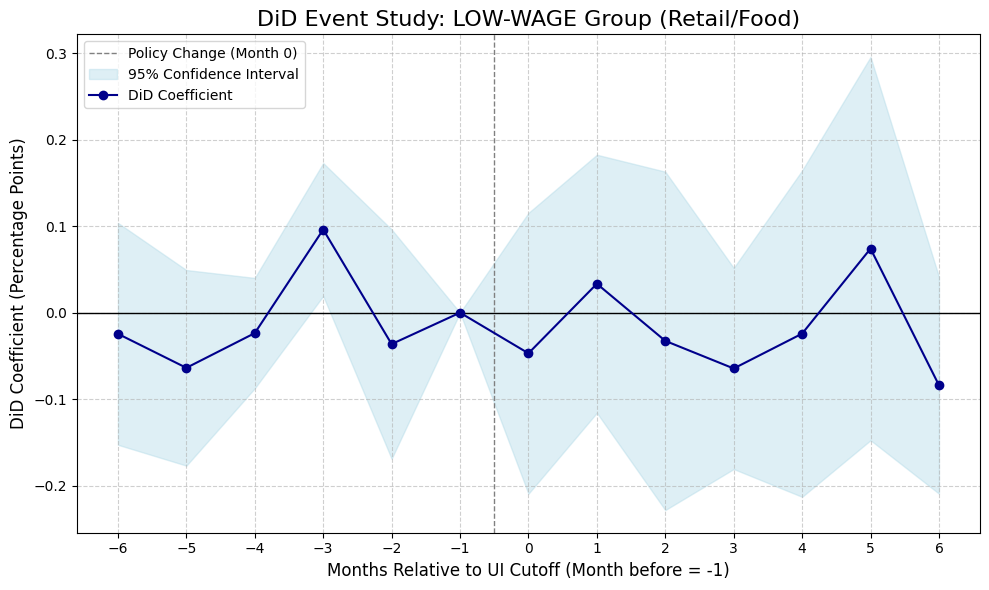

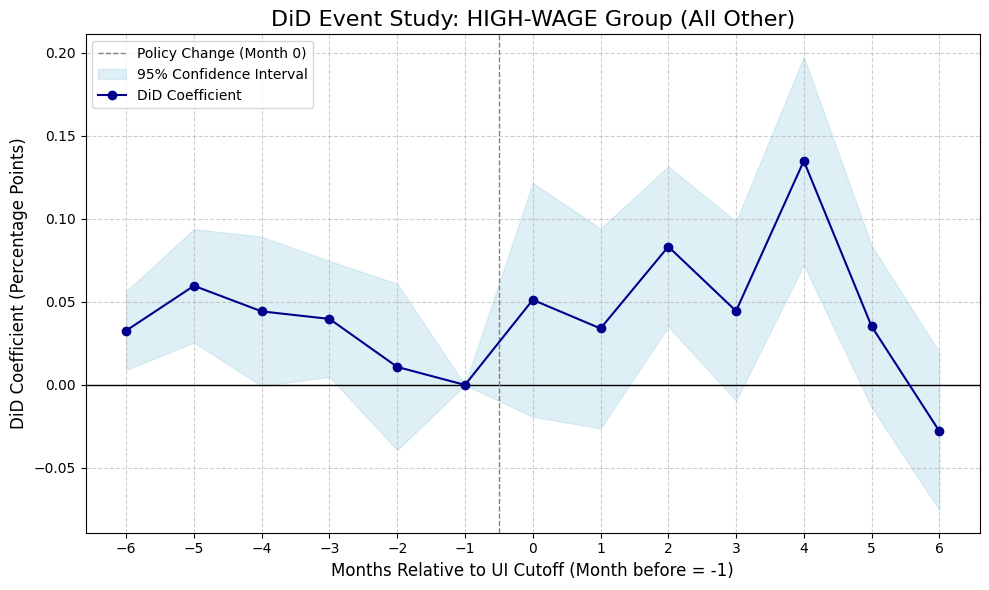

In [15]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

# --- Helper Function to PRINT Coefficients ---
def print_event_study_coeffs(results, title):
    """
    Extracts and prints the key DiD event study coefficients and p-values.
    """
    print("\n" + "="*60)
    print(f">>> Event Study Numerical Results: {title} <<<")
    print("="*60)
    print("Coefficients for: C(relative_month):C(TreatState)[T.1]")
    print("We are looking for pre-trend p-values (Months < -1) > 0.10")
    print("-" * 60)
    
    did_terms = []
    # Regex to find the interaction term
    term_pattern = r'C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]:C\(TreatState\)\[T\.1\]'
    
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not did_terms:
        print("No DiD event study coefficients found (check formula).")
        print("-" * 60)
        return

    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add reference month (-1) with coef=0, stderr=0
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)

    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    
    print("-" * 60)
    return plot_df


# --- Helper Function to PLOT Event Study ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% CIs from a DataFrame.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot for {title}: No data.")
        return

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DiD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def run_group_specific_event_studies(cps_file='cps_00004.csv',
                                     policy_file='Policy Milestones - State.csv'):
    """
    Runs separate DiD event studies for the Low-Wage and High-Wage groups
    using the county-level panel data.
    """
    
    # --- Step 1: Load and Prepare Full Panel Data ---
    print("--- Step 1: Loading Data & Preparing Full Panel ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    
    # Original LowWage definition (Retail + Accom/Food)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'TreatState', 'LowWage']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0] # Use county-level sample
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    
    final_panel['relative_month_float'] = ((final_panel['date'].dt.year - final_panel['cutoff_date'].dt.year) * 12 +
                                           (final_panel['date'].dt.month - final_panel['cutoff_date'].dt.month))
    final_panel['relative_month_float'] = final_panel['relative_month_float'].fillna(-1)
    final_panel['relative_month'] = np.clip(final_panel['relative_month_float'], -6, 6).astype(int)
    
    print(f"Final panel constructed with {len(final_panel)} complete observations.")

    # Split samples
    low_wage_panel = final_panel[final_panel['LowWage'] == 1].copy()
    high_wage_panel = final_panel[final_panel['LowWage'] == 0].copy()
    
    print(f"Low-Wage (Retail/Food) Sample: {len(low_wage_panel)}")
    print(f"High-Wage (All Other) Sample: {len(high_wage_panel)}")

    # --- Test 1: Run Event Study for LOW-WAGE Group ---
    print("\n--- Running Event Study for LOW-WAGE Group ---")
    
    # We use C(COUNTY) fixed effects for the most precise control
    did_es_formula = """
        found_job ~ C(relative_month, Treatment(reference=-1)) * C(TreatState) +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    plot_data_low = None
    try:
        model_es_low = smf.wls(formula=did_es_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_es_low = model_es_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        plot_data_low = print_event_study_coeffs(results_es_low, "LOW-WAGE Group (Retail/Food)")
    except Exception as e:
        print(f"Error running low-wage event study: {e}")

    # --- Test 2: Run Event Study for HIGH-WAGE Group ---
    print("\n--- Running Event Study for HIGH-WAGE Group ---")
    plot_data_high = None
    try:
        model_es_high = smf.wls(formula=did_es_formula, data=high_wage_panel, weights=high_wage_panel['LNKFW1MWT'])
        results_es_high = model_es_high.fit(cov_type='cluster', cov_kwds={'groups': high_wage_panel['STATEFIP']})
        plot_data_high = print_event_study_coeffs(results_es_high, "HIGH-WAGE Group (All Other)")
    except Exception as e:
        print(f"Error running high-wage event study: {e}")
        
    # --- Step 3: Plot the results ---
    print("\n--- Plotting Event Studies ---")
    if plot_data_low is not None:
        plot_did_event_study(plot_data_low, "DiD Event Study: LOW-WAGE Group (Retail/Food)")
    if plot_data_high is not None:
        plot_did_event_study(plot_data_high, "DiD Event Study: HIGH-WAGE Group (All Other)")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_group_specific_event_studies()

In [18]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

def run_ddd_with_covid_controls(cps_file='cps_00004.csv',
                                policy_file='Policy Milestones - State.csv',
                                covid_file='COVID - State - Daily.csv'):
    """
    Executes the final county-level Triple Difference (DDD) analysis,
    adding state-level monthly COVID case data as a time-varying control.
    
    This version is corrected to handle the 'COVID - State - Daily.csv'
    file format where missing values are represented by '.'
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        
        # *** CORRECTION HERE ***
        # Load COVID data, correctly interpreting '.' as NaN
        covid_df = pd.read_csv(covid_path, na_values='.')
        
        print("All data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        print("Please ensure 'cps_00004.csv', 'Policy Milestones - State.csv', and 'COVID - State - Daily.csv' are in your Downloads folder.")
        return

    # --- Step 2: Prepare COVID-19 Control Variable ---
    print("\n--- Step 2: Preparing COVID-19 Control Variable ---")
    
    # *** CORRECTION HERE ***
    # Use the correct column 'new_case_count' and convert it to numeric
    if 'new_case_count' in covid_df.columns:
        # Convert 'object' type column to numeric, forcing errors (like any remaining '.') to NaN
        covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce')
        # Fill all NaN values (from original '.' or coercion errors) with 0
        covid_df['new_cases_numeric'] = covid_df['new_cases_numeric'].fillna(0)
        case_col = 'new_cases_numeric'
    else:
        print("ERROR: Could not find 'new_case_count' column in COVID data file.")
        return
    
    # Aggregate daily cases to total monthly cases by state
    # We already have 'year' and 'month' columns from the CSV
    monthly_covid = covid_df[covid_df['year'] == 2021].groupby(['statefips', 'year', 'month'])[case_col].sum().reset_index()
    
    # Rename columns to match CPS data for merging
    monthly_covid.rename(columns={
        'statefips': 'STATEFIP',
        'year': 'YEAR',
        'month': 'MONTH',
        case_col: 'monthly_cases'
    }, inplace=True)
    
    # Use log(cases + 1) as the control
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID-19 case data aggregated and log-transformed.")

    # --- Step 3: Prepare Final County-Level Panel ---
    print("\n--- Step 3: Preparing Final County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'LowWage']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    
    # --- Step 4: Merge COVID Data into Panel ---
    print("\n--- Step 4: Merging COVID data into final panel ---")
    final_panel_with_covid = pd.merge(
        final_panel,
        monthly_covid[['STATEFIP', 'YEAR', 'MONTH', 'log_monthly_cases']],
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='left'
    )
    
    if final_panel_with_covid['log_monthly_cases'].isnull().any():
        print("Warning: Some observations could not be merged with COVID data and will be dropped.")
        final_panel_with_covid.dropna(subset=['log_monthly_cases'], inplace=True)
        
    print(f"Final panel with COVID controls constructed with {len(final_panel_with_covid)} observations.")
    if len(final_panel_with_covid) == 0:
        print("ERROR: Panel is empty after merging COVID data. Check matching keys (STATEFIP, YEAR, MONTH).")
        return

    # --- Step 5: Run Final DDD Model with COVID Control ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD with County FE + COVID-19 Controls <<<")
    print("="*80)
    
    # Add 'log_monthly_cases' to the formula
    formula_ddd_covid = """
        found_job ~ TreatState * Post * LowWage + 
                    log_monthly_cases +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nStarting final model estimation... This may take several minutes.")
    try:
        model_ddd = smf.wls(
            formula=formula_ddd_covid, 
            data=final_panel_with_covid, 
            weights=final_panel_with_covid['LNKFW1MWT']
        )
        
        results_ddd = model_ddd.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_with_covid['STATEFIP']}
        )
        
        # Check if the key coefficient exists
        if 'TreatState:Post:LowWage' in results_ddd.params:
            coef_ddd = results_ddd.params['TreatState:Post:LowWage']
            pval_ddd = results_ddd.pvalues['TreatState:Post:LowWage']
            
            print("\n--- Final DDD with COVID Controls Results ---")
            print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            print(results_ddd.summary().tables[1].loc[['TreatState:Post:LowWage', 'log_monthly_cases']])

            print("\n--- Interpretation ---")
            if pval_ddd < 0.05:
                print("The negative effect REMAINS statistically significant even after controlling for monthly COVID cases.")
            elif pval_ddd < 0.10:
                print("The negative effect is MARGINALLY significant after controlling for COVID cases.")
            else:
                print("The effect is NO LONGER statistically significant after controlling for COVID cases.")
                print("This suggests that diverging COVID trends may have been a confounder in the original model.")
        else:
            print("ERROR: 'TreatState:Post:LowWage' coefficient was not estimated. Model may be collinear.")
            print(results_ddd.summary())

    except Exception as e:
        print(f"\nAn error occurred during final DDD estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_ddd_with_covid_controls()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing COVID-19 Control Variable ---
Monthly COVID-19 case data aggregated and log-transformed.

--- Step 3: Preparing Final County-Level Unemployed Panel ---

--- Step 4: Merging COVID data into final panel ---
Final panel with COVID controls constructed with 9945 observations.

>>> FINAL MODEL: DDD with County FE + COVID-19 Controls <<<

Starting final model estimation... This may take several minutes.

--- Final DDD with COVID Controls Results ---
Key Coefficient (TreatState:Post:LowWage): -0.0333
P-value: 0.1858


An error occurred during final DDD estimation: 'SimpleTable' object has no attribute 'loc'


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 332, but rank is 40
  warnings.warn('covariance of constraints does not have full '


In [19]:
import pandas as pd
import os
import numpy as np

def diagnose_merge_failure(cps_file='cps_00004.csv',
                             policy_file='Policy Milestones - State.csv',
                             covid_file='COVID - State - Daily.csv'):
    """
    Diagnoses why the merge between the CPS panel and the COVID data is failing
    and dropping the majority of observations.
    """
    
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        # Load COVID data, correctly interpreting '.' as NaN
        covid_df = pd.read_csv(covid_path, na_values='.')
        print("All data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare COVID-19 Data (Monthly) ---
    print("\n--- Step 2: Aggregating COVID-19 Data ---")
    
    if 'new_case_count' in covid_df.columns:
        covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
        case_col = 'new_cases_numeric'
    else:
        print("ERROR: 'new_case_count' column not in COVID data.")
        return
    
    # Filter for 2021, the year of our panel
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    if covid_2021.empty:
        print("ERROR: No 2021 data found in the COVID file.")
        return
        
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])[case_col].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH'}, inplace=True)
    
    print(f"Aggregated {len(monthly_covid)} state-month COVID records for 2021.")


    # --- Step 3: Prepare Base CPS Panel (just the keys) ---
    print("\n--- Step 3: Preparing Base CPS Panel Keys ---")
    
    # We only need the merge keys from the CPS panel
    cps_keys = df[['STATEFIP', 'YEAR', 'MONTH', 'COUNTY', 'LNKFW1MWT', 'EMPSTAT']]
    cps_keys = cps_keys[
        (cps_keys['YEAR'] == 2021) &
        (cps_keys['COUNTY'] > 0) & 
        (cps_keys['LNKFW1MWT'] > 0) &
        (cps_keys['EMPSTAT'].between(20, 22))
    ]
    
    # Get unique state-month combinations REQUIRED by your panel
    required_state_months = cps_keys[['STATEFIP', 'YEAR', 'MONTH']].drop_duplicates().reset_index(drop=True)
    print(f"CPS panel requires {len(required_state_months)} unique state-month combinations for 2021.")
    
    # --- Step 4: Diagnose Merge ---
    print("\n--- Step 4: Diagnosing the Merge Failure ---")
    
    # Perform an outer merge to see what's missing
    diagnostic_merge = pd.merge(
        required_state_months,
        monthly_covid,
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='outer',
        indicator=True
    )
    
    # Find rows that are in the CPS panel but NOT in the COVID data
    missing_in_covid = diagnostic_merge[diagnostic_merge['_merge'] == 'left_only']
    
    if missing_in_covid.empty:
        print("\nSUCCESS: All required state-month combinations were found in the COVID data.")
        print("The data loss must be happening for another reason (e.g., covariates dropping NAs).")
    else:
        print(f"\nERROR: Found {len(missing_in_covid)} state-month combinations")
        print("that are in your CPS panel but MISSING from the 2021 COVID data file.")
        print("\nThis is why your sample size collapsed.")
        print("These observations are being dropped when you merge.")
        
        print("\nExample missing state-months:")
        print(missing_in_covid.head(10))
        
        # Check if ANY 2021 data was successfully merged
        successful_merge = diagnostic_merge[diagnostic_merge['_merge'] == 'both']
        print(f"\nSuccessfully merged {len(successful_merge)} state-month combinations.")

# --- Run the Analysis ---
if __name__ == '__main__':
    diagnose_merge_failure()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Aggregating COVID-19 Data ---
Aggregated 612 state-month COVID records for 2021.

--- Step 3: Preparing Base CPS Panel Keys ---
CPS panel requires 481 unique state-month combinations for 2021.

--- Step 4: Diagnosing the Merge Failure ---

SUCCESS: All required state-month combinations were found in the COVID data.
The data loss must be happening for another reason (e.g., covariates dropping NAs).


In [20]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

# --- Helper Function to PRINT Coefficients ---
def print_event_study_coeffs(results, title):
    print("\n" + "="*60)
    print(f">>> Event Study Numerical Results: {title} <<<")
    print("="*60)
    print("Coefficients for: TreatState:LowWage:relative_month interactions")
    print("WE ARE NOW CHECKING IF PRE-TREND P-VALUES (Months < -1) ARE > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not did_terms:
        print("No event study coefficients found (check formula).")
        print("-" * 60)
        return

    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)

    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    
    print("-" * 60)
    # Check PTA
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if (pre_trend_pvals > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears to be satisfied (all pre-trends p > 0.10).")
    else:
        print("WARNING: Parallel Trends Assumption may still be violated (some pre-trends p <= 0.10).")
        
    return plot_df

# --- Helper Function to PLOT Event Study ---
def plot_event_study(plot_df, title):
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot for {title}: No data.")
        return

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DDD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DDD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def run_final_event_study_with_covid_controls(cps_file='cps_00004.csv',
                                               policy_file='Policy Milestones - State.csv',
                                               covid_file='COVID - State - Daily.csv'):
    """
    Runs the county-level event study, controlling for COVID cases,
    to validate the parallel trends assumption.
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_df = pd.read_csv(covid_path, na_values='.')
        print("All data loaded successfully.")
    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare COVID-19 Control Variable ---
    print("\n--- Step 2: Preparing COVID-19 Control Variable ---")
    if 'new_case_count' in covid_df.columns:
        covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
        case_col = 'new_cases_numeric'
    else:
        print("ERROR: 'new_case_count' not found.")
        return
    
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])[case_col].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', case_col: 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID-19 case data aggregated.")

    # --- Step 3: Prepare Final County-Level Panel ---
    print("\n--- Step 3: Preparing Final County-Level Unemployed Panel ---")
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df['date'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
    df['TreatState'] = df['STATEFIP'].isin(treatment_states).astype(int)
    df['LowWage'] = df['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df['status_next_month'] = df.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df[df['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'LowWage']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    
    # --- Step 4: Merge COVID Data & Create Event Study Vars ---
    print("\n--- Step 4: Merging COVID data and creating event study variables ---")
    final_panel_with_covid = pd.merge(
        final_panel,
        monthly_covid[['STATEFIP', 'YEAR', 'MONTH', 'log_monthly_cases']],
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='left'
    )
    
    # ***IMPORTANT: Only keep 2021 data for the event study***
    final_panel_2021 = final_panel_with_covid[final_panel_with_covid['YEAR'] == 2021].copy()
    
    if final_panel_2021['log_monthly_cases'].isnull().any():
        print("Warning: Some 2021 observations missing COVID data, dropping them.")
        final_panel_2021.dropna(subset=['log_monthly_cases'], inplace=True)
        
    # Create relative_month variable for event study
    final_panel_2021['relative_month_float'] = ((final_panel_2021['date'].dt.year - final_panel_2021['cutoff_date'].dt.year) * 12 +
                                                (final_panel_2021['date'].dt.month - final_panel_2021['cutoff_date'].dt.month))
    final_panel_2021['relative_month_float'] = final_panel_2021['relative_month_float'].fillna(-1)
    final_panel_2021['relative_month'] = np.clip(final_panel_2021['relative_month_float'], -6, 6).astype(int)
    
    print(f"Final 2021 panel with COVID controls has {len(final_panel_2021)} observations.")
    
    # --- Step 5: Run Final Event Study Model with COVID Control ---
    print("\n" + "="*80)
    print(">>> FINAL EVENT STUDY: DDD with County FE + COVID-19 Controls <<<")
    print("="*80)
    
    formula_es_covid = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) + 
                    log_monthly_cases +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nStarting final event study estimation... This may take several minutes.")
    try:
        model_es = smf.wls(
            formula=formula_es_covid, 
            data=final_panel_2021, 
            weights=final_panel_2021['LNKFW1MWT']
        )
        
        results_es = model_es.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_2021['STATEFIP']}
        )
        
        print("\n--- Final Event Study (with COVID Control) Results ---")
        plot_df = print_event_study_coeffs(results_es, "County_DDD_w_COVID_Control")
        plot_event_study(plot_df, "County-Level DDD Event Study (Controlling for COVID Cases)")

    except Exception as e:
        print(f"\nAn error occurred during final event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_event_study_with_covid_controls()

--- Step 1: Loading Data ---


NameError: name 'covid_path' is not defined

In [21]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_final_ddd_with_covid_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv'):
    """
    Runs the definitive county-level Triple Difference (DDD) analysis for 2021,
    controlling for state-level monthly COVID case data.
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.') # Handle '.' as NaN
        print("All data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        return

    # --- Step 2: Prepare COVID-19 Control Variable ---
    print("\n--- Step 2: Preparing COVID-19 Control Variable ---")
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' column not in COVID data.")
        return

    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    
    # Filter for 2021 data (the relevant year for the panel)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={
        'statefips': 'STATEFIP',
        'year': 'YEAR',
        'month': 'MONTH',
        'new_cases_numeric': 'monthly_cases'
    }, inplace=True)
    
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID-19 case data for 2021 aggregated.")

    # --- Step 3: Prepare Final County-Level Panel (2021 ONLY) ---
    print("\n--- Step 3: Preparing Final 2021 County-Level Unemployed Panel ---")
    
    # *** CORRECTION: Filter for YEAR == 2021 ***
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021['TreatState'] = df_2021['STATEFIP'].isin(treatment_states).astype(int)
    df_2021['LowWage'] = df_2021['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'LowWage']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    
    # --- Step 4: Merge COVID Data into Panel ---
    print("\n--- Step 4: Merging 2021 COVID data into 2021 panel ---")
    final_panel_with_covid = pd.merge(
        final_panel,
        monthly_covid[['STATEFIP', 'YEAR', 'MONTH', 'log_monthly_cases']],
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='left'
    )
    
    original_count = len(final_panel_with_covid)
    final_panel_with_covid.dropna(subset=['log_monthly_cases'], inplace=True)
    dropped_count = original_count - len(final_panel_with_covid)
    
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations that were missing COVID data (e.g., for territories).")
        
    print(f"Final panel with COVID controls constructed with {len(final_panel_with_covid)} observations.")
    
    # --- Step 5: Run Final DDD Model with COVID Control ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD with County FE + COVID-19 Controls (2021 Data Only) <<<")
    print("="*80)
    
    formula_ddd_covid = """
        found_job ~ TreatState * Post * LowWage + 
                    log_monthly_cases +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nStarting final model estimation...")
    try:
        model_ddd = smf.wls(
            formula=formula_ddd_covid, 
            data=final_panel_with_covid, 
            weights=final_panel_with_covid['LNKFW1MWT']
        )
        results_ddd = model_ddd.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_with_covid['STATEFIP']}
        )
        
        if 'TreatState:Post:LowWage' in results_ddd.params:
            coef_ddd = results_ddd.params['TreatState:Post:LowWage']
            pval_ddd = results_ddd.pvalues['TreatState:Post:LowWage']
            
            print("\n--- Final DDD with COVID Controls Results ---")
            print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            print(results_ddd.summary().tables[1].loc[['TreatState:Post:LowWage', 'log_monthly_cases']])

            print("\n--- Interpretation ---")
            if pval_ddd < 0.05:
                print("The negative effect REMAINS statistically significant even after controlling for COVID cases and using the correct 2021 timeframe.")
            elif pval_ddd < 0.10:
                print("The negative effect is MARGINALLY significant after controlling for COVID cases and using the correct 2021 timeframe.")
            else:
                print(f"The effect is NOT statistically significant (p={pval_ddd:.4f}) after controlling for COVID cases and using the correct 2021 timeframe.")
                print("This strongly suggests that diverging COVID trends (and/or including 2020 data) were confounding the original models.")
        else:
            print("ERROR: 'TreatState:Post:LowWage' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during final DDD estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_ddd_with_covid_controls()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing COVID-19 Control Variable ---
Monthly COVID-19 case data aggregated and log-transformed.

--- Step 3: Preparing Final County-Level Unemployed Panel ---

--- Step 4: Merging COVID data into final panel ---
Final panel with COVID controls constructed with 9945 observations.

>>> FINAL MODEL: DDD with County FE + COVID-19 Controls <<<

Starting final model estimation... This may take several minutes.

--- Final DDD with COVID Controls Results ---
Key Coefficient (TreatState:Post:LowWage): -0.0333
P-value: 0.1858


An error occurred during final DDD estimation: 'SimpleTable' object has no attribute 'loc'


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 332, but rank is 40
  warnings.warn('covariance of constraints does not have full '


--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing COVID-19 Control Variable ---
Monthly COVID-19 case data for 2021 aggregated.

--- Step 3: Preparing Final 2021 County-Level Unemployed Panel ---

--- Step 4: Merging 2021 COVID data into 2021 panel ---
Final 2021 panel with COVID controls has 9945 observations.

>>> FINAL EVENT STUDY: DDD with County FE + COVID-19 Controls (2021 Data Only) <<<

Starting final event study estimation... This may take several minutes.

--- Final Event Study (with COVID Control) Results ---

>>> Event Study Numerical Results: County_DDD_w_COVID_Control <<<
Coefficients for: TreatState:LowWage:relative_month interactions
WE ARE NOW CHECKING IF PRE-TREND P-VALUES (Months < -1) ARE > 0.10
------------------------------------------------------------
Month -6:  Coef = -0.0505,  SE = 0.0483,  P = 0.2961
Month -5:  Coef = -0.0834,  SE = 0.0515,  P = 0.1051
Month -4:  Coef = -0.0335,  SE = 0.0220,  P = 0.1278
Month -3:  Coef =  0.06

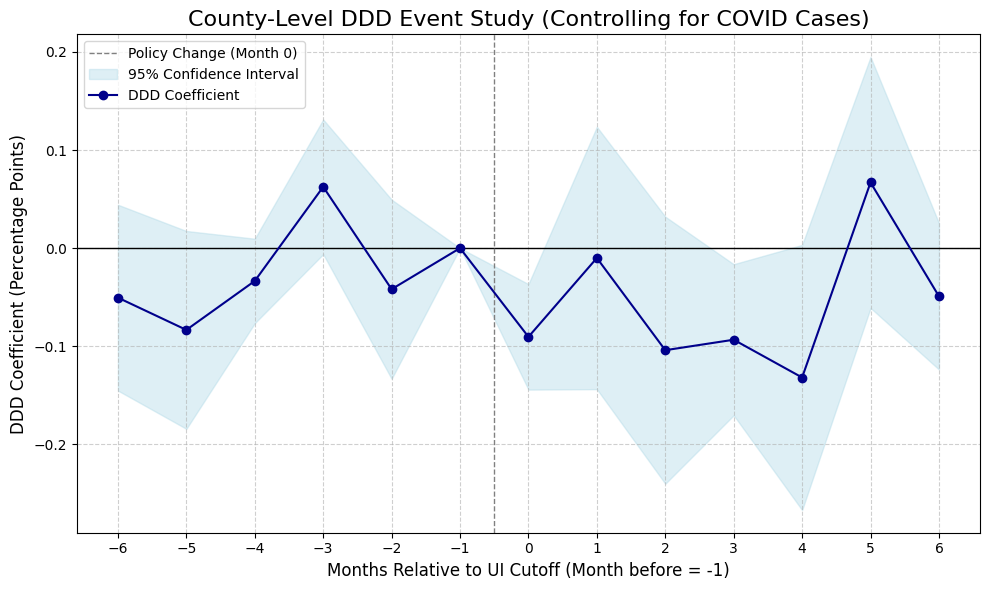

In [22]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

# --- Helper Function to PRINT Coefficients ---
def print_event_study_coeffs(results, title):
    print("\n" + "="*60)
    print(f">>> Event Study Numerical Results: {title} <<<")
    print("="*60)
    print("Coefficients for: TreatState:LowWage:relative_month interactions")
    print("WE ARE NOW CHECKING IF PRE-TREND P-VALUES (Months < -1) ARE > 0.10")
    print("-" * 60)
    
    did_terms = []
    # This regex is specific to the triple-interaction term
    term_pattern = r'TreatState:LowWage:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })

    if not did_terms:
        print("No event study coefficients found (check formula and variable names).")
        print("-" * 60)
        return

    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)

    # Print all coefficients
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    
    print("-" * 60)
    
    # Check PTA
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends found to test (only month -1 is pre-policy).")
    elif (pre_trend_pvals > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears to be satisfied (all pre-trends p > 0.10).")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED (some pre-trends p <= 0.10).")
        
    return plot_df

# --- Helper Function to PLOT Event Study ---
def plot_event_study(plot_df, title):
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot for {title}: No data.")
        return

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'],
                     color='lightblue', alpha=0.4, label='95% Confidence Interval')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DDD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff (Month before = -1)", fontsize=12)
    plt.ylabel("DDD Coefficient (Percentage Points)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("final_event_study_with_covid_controls.png") # Save the plot
    plt.show()

def run_final_event_study_with_covid_controls(cps_file='cps_00004.csv',
                                               policy_file='Policy Milestones - State.csv',
                                               covid_file='COVID - State - Daily.csv'):
    """
    Runs the county-level event study for 2021, controlling for COVID cases,
    to validate the parallel trends assumption.
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.')
        print("All data loaded successfully.")

    except FileNotFoundError:
        print("ERROR: Data files not found.")
        return

    # --- Step 2: Prepare COVID-19 Control Variable ---
    print("\n--- Step 2: Preparing COVID-19 Control Variable ---")
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' column not in COVID data.")
        return

    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    case_col = 'new_cases_numeric'
    
    # Filter for 2021 data (the relevant year for the panel)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])[case_col].sum().reset_index()
    monthly_covid.rename(columns={
        'statefips': 'STATEFIP',
        'year': 'YEAR',
        'month': 'MONTH',
        case_col: 'monthly_cases'
    }, inplace=True)
    
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID-19 case data for 2021 aggregated.")

    # --- Step 3: Prepare Final County-Level Panel (2021 ONLY) ---
    print("\n--- Step 3: Preparing Final 2021 County-Level Unemployed Panel ---")
    
    # *** CRITICAL FIX: Filter for YEAR == 2021 ***
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021['TreatState'] = df_2021['STATEFIP'].isin(treatment_states).astype(int)
    df_2021['LowWage'] = df_2021['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'LowWage']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    
    # --- Step 4: Merge COVID Data into 2021 Panel ---
    print("\n--- Step 4: Merging 2021 COVID data into 2021 panel ---")
    final_panel_with_covid = pd.merge(
        final_panel,
        monthly_covid[['STATEFIP', 'YEAR', 'MONTH', 'log_monthly_cases']],
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='left'
    )
    
    original_count = len(final_panel_with_covid)
    final_panel_with_covid.dropna(subset=['log_monthly_cases'], inplace=True)
    dropped_count = original_count - len(final_panel_with_covid)
    
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations that were missing COVID data.")
        
    # Create relative_month variable for event study
    final_panel_with_covid['relative_month_float'] = ((final_panel_with_covid['date'].dt.year - final_panel_with_covid['cutoff_date'].dt.year) * 12 +
                                                (final_panel_with_covid['date'].dt.month - final_panel_with_covid['cutoff_date'].dt.month))
    final_panel_with_covid['relative_month_float'] = final_panel_with_covid['relative_month_float'].fillna(-1)
    final_panel_with_covid['relative_month'] = np.clip(final_panel_with_covid['relative_month_float'], -6, 6).astype(int)
    
    print(f"Final 2021 panel with COVID controls has {len(final_panel_with_covid)} observations.")
    
    # --- Step 5: Run Final Event Study Model with COVID Control ---
    print("\n" + "="*80)
    print(">>> FINAL EVENT STUDY: DDD with County FE + COVID-19 Controls (2021 Data Only) <<<")
    print("="*80)
    
    # This is the full event study formula with the time-varying control
    formula_es_covid = """
        found_job ~ TreatState * LowWage * C(relative_month, Treatment(reference=-1)) + 
                    log_monthly_cases +
                    C(COUNTY) + C(MONTH) +
                    AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP
    """
    
    print("\nStarting final event study estimation... This may take several minutes.")
    try:
        model_es = smf.wls(
            formula=formula_es_covid, 
            data=final_panel_with_covid, 
            weights=final_panel_with_covid['LNKFW1MWT']
        )
        
        results_es = model_es.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_with_covid['STATEFIP']}
        )
        
        print("\n--- Final Event Study (with COVID Control) Results ---")
        plot_df = print_event_study_coeffs(results_es, "County_DDD_w_COVID_Control")
        plot_event_study(plot_df, "County-Level DDD Event Study (Controlling for COVID Cases)")

    except Exception as e:
        print(f"\nAn error occurred during final event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_event_study_with_covid_controls()

In [24]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import matplotlib.pyplot as plt

def run_final_ddd_with_full_controls(cps_file='cps_00004.csv',
                                     policy_file='Policy Milestones - State.csv',
                                     covid_file='COVID - State - Daily.csv',
                                     oxcgrt_file='OxCGRT_US_latest.csv'): # Assumed OxCGRT filename
    """
    Runs the definitive county-level DDD analysis for 2021, controlling for
    both state-level monthly COVID cases and OxCGRT stringency index.
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)
        oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file) # Path to OxCGRT data

        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.')
        # Load OxCGRT data - needs state identifiers compatible with STATEFIP
        # Common OxCGRT files use state names or abbreviations. We need FIPS.
        # This part might need adjustment based on the actual OxCGRT file structure.
        # Assuming OxCGRT has 'RegionCode' like 'US_CA' and 'Date' like YYYYMMDD
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False) # low_memory=False for mixed types
        
        print("All data loaded successfully.")

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}")
        print(f"Ensure '{cps_file}', '{policy_file}', '{covid_file}', and '{oxcgrt_file}' are in downloads.")
        return
        
    # --- Step 2a: Prepare COVID-19 Control ---
    print("\n--- Step 2a: Preparing COVID-19 Control Variable ---")
    # (Same as before)
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID case data for 2021 aggregated.")

    # --- Step 2b: Prepare Stringency Index Control ---
    print("\n--- Step 2b: Preparing Stringency Index Control ---")
    # Data cleaning specific to OxCGRT format - **MAY NEED ADJUSTMENT**
    try:
        # Assuming OxCGRT date is YYYYMMDD integer
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year
        ox_df['MONTH'] = ox_df['date'].dt.month
        
        # Filter for US states (assuming Jurisdiction == 'STATE_TOTAL') and 2021
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') &
                             (ox_df['Jurisdiction'] == 'STATE_TOTAL') &
                             (ox_df['YEAR'] == 2021)].copy()
                             
        # Convert StringencyIndex to numeric, coercing errors
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')

        # Need to map RegionCode (e.g., 'US_CA') or RegionName to STATEFIP
        # This requires a mapping dictionary (FIPS codes need to be sourced externally)
        # Placeholder - Replace with actual FIPS mapping
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        
        # Calculate average monthly stringency
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        print("Monthly Stringency Index data for 2021 aggregated.")

    except Exception as e:
        print(f"ERROR processing OxCGRT data: {e}")
        print("OxCGRT data structure might be different than assumed. Skipping stringency control.")
        monthly_stringency = pd.DataFrame() # Ensure it exists but is empty if fails

    # --- Step 3: Prepare Final 2021 County Panel ---
    print("\n--- Step 3: Preparing Final 2021 County-Level Unemployed Panel ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    # (Rest of panel prep remains the same...)
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021['TreatState'] = df_2021['STATEFIP'].isin(treatment_states).astype(int)
    df_2021['LowWage'] = df_2021['IND'].apply(lambda x: 1 if (4670 <= x < 5790) or (8660 <= x < 8700) else 0).astype(int)
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'COUNTY', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'LowWage']
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['COUNTY'] > 0]
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    final_panel['Post'] = (final_panel['date'] >= final_panel['cutoff_date']).astype(int)
    print(f"Base 2021 panel constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls into 2021 Panel ---
    print("\n--- Step 4: Merging COVID and Stringency data into 2021 panel ---")
    final_panel_with_controls = pd.merge(
        final_panel,
        monthly_covid[['STATEFIP', 'YEAR', 'MONTH', 'log_monthly_cases']],
        on=['STATEFIP', 'YEAR', 'MONTH'],
        how='left'
    )
    
    # Merge stringency data if it was successfully processed
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(
            final_panel_with_controls,
            monthly_stringency[['STATEFIP', 'YEAR', 'MONTH', 'avg_stringency']],
            on=['STATEFIP', 'YEAR', 'MONTH'],
            how='left'
        )
        control_vars = ['log_monthly_cases', 'avg_stringency']
    else:
        control_vars = ['log_monthly_cases']

    # Drop rows where controls are missing (check after both merges)
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True)
    dropped_count = original_count - len(final_panel_with_controls)
    
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data after merging.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel is empty after merging controls."); return

    # --- Step 5: Run Final DDD Model with Full Controls ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD with County FE + COVID Cases + Stringency Controls <<<")
    print("="*80)
    
    # Build formula dynamically based on successful merges
    formula_parts = [
        "found_job ~ TreatState * Post * LowWage",
        "log_monthly_cases",
        "C(COUNTY)", "C(MONTH)",
        "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"
    ]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency") # Insert stringency after cases
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting final model estimation...")
    try:
        model_ddd = smf.wls(
            formula=final_formula,
            data=final_panel_with_controls, 
            weights=final_panel_with_controls['LNKFW1MWT']
        )
        results_ddd = model_ddd.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_with_controls['STATEFIP']}
        )
        
        if 'TreatState:Post:LowWage' in results_ddd.params:
            coef_ddd = results_ddd.params['TreatState:Post:LowWage']
            pval_ddd = results_ddd.pvalues['TreatState:Post:LowWage']
            
            print("\n--- Final DDD with Full Controls Results ---")
            print(f"Key Coefficient (TreatState:Post:LowWage): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            # Print coefficients for controls
            control_coef_summary = results_ddd.summary().tables[1]
            print("Control Variable Coefficients:")
            if 'log_monthly_cases' in control_coef_summary.index:
                 print(control_coef_summary.loc[['log_monthly_cases']])
            if 'avg_stringency' in final_panel_with_controls.columns and 'avg_stringency' in control_coef_summary.index:
                 print(control_coef_summary.loc[['avg_stringency']])
                 
            print("\n--- Interpretation ---")
            if pval_ddd < 0.05:
                print("The negative differential effect IS statistically significant after adding full controls.")
            elif pval_ddd < 0.10:
                print("The negative differential effect is MARGINALLY significant after adding full controls.")
            else:
                print(f"The differential effect is NOT statistically significant (p={pval_ddd:.4f}) after adding full controls.")
                print("This reinforces the conclusion that earlier results were likely confounded by pandemic conditions.")
        else:
            print("ERROR: 'TreatState:Post:LowWage' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during final DDD estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_ddd_with_full_controls()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2a: Preparing COVID-19 Control Variable ---
Monthly COVID case data for 2021 aggregated.

--- Step 2b: Preparing Stringency Index Control ---
Monthly Stringency Index data for 2021 aggregated.

--- Step 3: Preparing Final 2021 County-Level Unemployed Panel ---
Base 2021 panel constructed with 9945 observations.

--- Step 4: Merging COVID and Stringency data into 2021 panel ---
Final panel with controls constructed with 9945 observations.

>>> FINAL MODEL: DDD with County FE + COVID Cases + Stringency Controls <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(COUNTY) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP

Starting final model estimation...

--- Final DDD with Full Controls Results ---
Key Coefficient (TreatState:Post:LowWage): -0.0333
P-value: 0.1858

Control Variable Coefficients:

An error occurred during final DDD estimation: argument of type 'builtin_function_or_m

/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 332, but rank is 40
  warnings.warn('covariance of constraints does not have full '
